In [1]:

# # Cairo Places - Exploratory Data Analysis (EDA) - Per Category
# ## TourMate AI - Data Intelligence Report
#
# **Date:** June 2026
# **Analyst:** TourMate AI Data Science Team
# **Dataset:** `data/cairo_places_filled (9).json` - 6,600+ places across Cairo, Egypt
#
# This notebook performs **category-separated** EDA for **Hotels**, **Restaurants**, and **Attractions**.
#
# ---

# ## 0. Environment Setup & Imports

In [2]:
import warnings
warnings.filterwarnings('ignore')

import os, json, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import zscore
from collections import Counter

# Plotly
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Folium
import folium
from folium.plugins import HeatMap, MarkerCluster

# Sklearn
from sklearn.preprocessing import MinMaxScaler

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', lambda x: f'{x:.3f}')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['figure.figsize'] = (14, 7)

os.makedirs('../outputs/figures', exist_ok=True)
os.makedirs('../outputs/reports', exist_ok=True)

print('[OK] All libraries loaded successfully.')

# ---
# ## 1. Data Loading & Initial Inspection

[OK] All libraries loaded successfully.


In [3]:
DATA_PATH = '../data/cairo_places_filled (9).json'

with open(DATA_PATH, 'r', encoding='utf-8') as f:
    raw_data = json.load(f)

df = pd.DataFrame(raw_data)

print(f'Dataset Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Columns: {list(df.columns)}')
print(f'Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB')
print(f'City: {df["city"].unique()}')
print(f'Country: {df["country"].unique()}')

# Identify hashable (non-nested) columns for pandas operations
nested_fields = {'photos', 'reviews', 'hours'}
hashable_cols = [c for c in df.columns if c not in nested_fields]
for c in list(hashable_cols):
    if df[c].dtype == 'object' and df[c].apply(lambda x: isinstance(x, (list, dict))).any():
        hashable_cols.remove(c)

print(f'Hashable columns: {len(hashable_cols)} of {len(df.columns)}')

Dataset Shape: 6,556 rows x 29 columns
Columns: ['id', 'name', 'category', 'category_label', 'description', 'rating', 'review_count', 'city', 'country', 'lat', 'lon', 'address', 'phone', 'website', 'maps_link', 'photos', 'reviews', 'hours', 'subtype', 'cuisine_type', 'price_level', 'avg_cost_per_person', 'reservation_link', 'star_class', 'price_per_night', 'nightly_rate', 'booking_platforms', 'amenities', 'neighborhood']
Memory Usage: 15.8 MB
City: <StringArray>
['Cairo']
Length: 1, dtype: str
Country: <StringArray>
['Egypt']
Length: 1, dtype: str
Hashable columns: 23 of 29


In [4]:
df.head()

,id,name,category,category_label,description,rating,review_count,city,country,lat,lon,address,phone,website,maps_link,photos,reviews,hours,subtype,cuisine_type,price_level,avg_cost_per_person,reservation_link,star_class,price_per_night,nightly_rate,booking_platforms,amenities,neighborhood
0,lo-47C56EF2,Citystars Mall,attractions,Shopping mall,"Citystars Mall, located in the Nasr City distr...",4.500,142032,Cairo,Egypt,30.073,31.347,"2 Omar Ibn El-Khattab, Masaken Al Mohandesin, ...",02 24800800,http://www.citystars-heliopolis.com.eg/,https://www.google.com/maps/place/Citystars+Ma...,[https://lh3.googleusercontent.com/gps-cs-s/AP...,[⭐⭐⭐⭐⭐ You didn't come to Cairo to get lost — ...,"{'monday': '10:00 – 22:00', 'tuesday': '10:00 ...",Shopping mall,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,lo-37DC2AB8,Cairo Festival City Mall,attractions,Shopping mall,Cairo Festival City Mall is a large-scale shop...,4.600,112140,Cairo,Egypt,30.029,31.408,"Ring Rd, New Cairo 3, Cairo Governorate 4730020",02 26186069,https://www.festivalcitymallcairo.com/home/?ut...,https://www.google.com/maps/place/Cairo+Festiv...,[https://lh3.googleusercontent.com/gps-cs-s/AP...,[Cairo Festival City is a premier destination ...,"{'monday': '10:00 – 02:00', 'tuesday': '10:00 ...",Shopping mall,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,lo-747C0ECE,Giza Necropolis,attractions,Landmark / Historic site,Famed archaeological site featuring the Great ...,4.600,112057,Cairo,Egypt,29.977,31.132,"Al Haram, Giza Governorate 3512201",NaN,https://egymonuments.gov.eg/ar/archaeological-...,https://www.google.com/maps/place/Giza+Necropo...,[https://lh3.googleusercontent.com/gps-cs-s/AP...,[The Experience of a Lifetime (February 2026)\...,"{'monday': '07:00 – 17:00', 'tuesday': '07:00 ...",Archaeological site,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,lo-2B59141A,Sobhy Kaber,restaurant,Restaurant,Traditional Mediterranean meat feasts & sides ...,4.300,79781,Cairo,Egypt,30.084,31.234,"151 Ebeid, As Sahel, Rod El Farag, Cairo Gover...",02 21288990,https://www.facebook.com/profile.php?id=615684...,https://www.google.com/maps/place/Sobhy+Kaber/...,[https://lh3.googleusercontent.com/gps-cs-s/AP...,"[The lamb was good, chicken is overcooked, keb...","{'monday': '12:00 – 05:00', 'tuesday': '12:00 ...",Egyptian restaurant,Egyptian restaurant,NaN,$3.86,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,lo-6BBAF808,Mall of Arabia,attractions,Shopping mall,"Huge shopping complex with brand-name stores, ...",4.600,77011,Cairo,Egypt,30.007,30.975,"First 6th of October, Giza Governorate 3236220",02 35353121,https://www.mallofarabia.net/,https://www.google.com/maps/place/Mall+of+Arab...,[https://lh3.googleusercontent.com/gps-cs-s/AP...,[⭐⭐⭐⭐⭐ One of Cairo's Original Mega-Malls — An...,"{'monday': '10:00 – 23:00', 'tuesday': '10:00 ...",Shopping mall,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df['category'].value_counts()

category
restaurant     4276
attractions    1509
hotel           771
Name: count, dtype: int64

In [6]:
df['city'].value_counts()

city
Cairo    6556
Name: count, dtype: int64

In [7]:
df['country'].value_counts()

country
Egypt    6556
Name: count, dtype: int64

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6556 entries, 0 to 6555
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   6556 non-null   str    
 1   name                 6556 non-null   str    
 2   category             6556 non-null   str    
 3   category_label       6556 non-null   str    
 4   description          6556 non-null   str    
 5   rating               6556 non-null   float64
 6   review_count         6556 non-null   int64  
 7   city                 6556 non-null   str    
 8   country              6556 non-null   str    
 9   lat                  6556 non-null   float64
 10  lon                  6556 non-null   float64
 11  address              6556 non-null   str    
 12  phone                4970 non-null   str    
 13  website              2966 non-null   str    
 14  maps_link            6556 non-null   str    
 15  photos               6556 non-null   object 
 16 

In [9]:
df[hashable_cols].describe(include='all')

# ---
# ## 2. Split Data by Category

,id,name,category,category_label,description,rating,review_count,city,country,lat,lon,address,phone,website,maps_link,subtype,cuisine_type,price_level,avg_cost_per_person,reservation_link,star_class,nightly_rate,neighborhood
count,6556,6556,6556,6556,6556,6556.000,6556.000,6556,6556,6556.000,6556.000,6556,4970,2966,6556,6556,3012,176,1596,0.000,298.000,728,728
unique,6556,6267,3,21,6454,NaN,NaN,1,1,NaN,NaN,6239,4580,2604,6556,317,152,3,17,NaN,NaN,637,55
top,lo-47C56EF2,Starbucks,restaurant,Restaurant,"Classic, long-running fast-food chain known fo...",NaN,NaN,Cairo,Egypt,NaN,NaN,"Masaken Al Mohandesin, Nasr City, Cairo Govern...",02 21600377,https://www.americanarestaurants.com/,https://www.google.com/maps/place/Citystars+Ma...,Restaurant,Coffee Shop,$$,$3.86,NaN,NaN,$67.32,Al Omraneya
freq,1,26,4276,2125,28,NaN,NaN,6556,6556,NaN,NaN,9,24,36,1,1076,1353,109,900,NaN,NaN,6,217
mean,NaN,NaN,NaN,NaN,NaN,4.251,1203.687,NaN,NaN,30.036,31.276,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.433,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,0.434,4629.054,NaN,NaN,0.054,0.169,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.124,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,1.300,5.000,NaN,NaN,29.809,27.206,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,4.000,44.000,NaN,NaN,30.008,31.210,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,4.300,178.000,NaN,NaN,30.044,31.244,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,4.600,743.000,NaN,NaN,30.064,31.347,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.000,NaN,NaN


In [10]:
df_hotel = df[df['category'] == 'hotel'].copy().reset_index(drop=True)
df_restaurant = df[df['category'] == 'restaurant'].copy().reset_index(drop=True)
df_attractions = df[df['category'] == 'attractions'].copy().reset_index(drop=True)

categories = {
    'hotel': df_hotel,
    'restaurant': df_restaurant,
    'attractions': df_attractions,
}

print('Dataset split by category:')
for cat_name, cat_df in categories.items():
    print(f'  {cat_name:15s}: {len(cat_df):>5,} places')

# ---
# ## 3. Derive Features (on full dataset, then used per-category)

Dataset split by category:
  hotel          :   771 places
  restaurant     : 4,276 places
  attractions    : 1,509 places


In [11]:
if 'photos' in df.columns:
    df['photo_count'] = df['photos'].apply(lambda x: len(x) if isinstance(x, list) else 0)

if 'reviews' in df.columns:
    df['review_text_count'] = df['reviews'].apply(lambda x: len(x) if isinstance(x, list) else 0)
    df['avg_review_length'] = df['reviews'].apply(
        lambda x: np.mean([len(r) for r in x]) if isinstance(x, list) and len(x) > 0 else 0
    )

if 'hours' in df.columns:
    df['has_hours'] = df['hours'].apply(lambda x: 1 if isinstance(x, dict) and len(x) > 0 else 0)

# District / area extraction
def extract_location(address, depth=2):
    """Extract a meaningful location part from an address string."""
    if not isinstance(address, str):
        return 'Unknown'
    parts = [p.strip() for p in address.split(',')]
    skip = {'cairo', 'giza', 'egypt', 'governorate', 'cairo governorate', 'giza governorate'}
    for p in reversed(parts[1:depth+2]):
        if p.lower() in skip or any(kw in p.lower() for kw in skip):
            continue
        if len(p) > 3:
            return p
    return parts[1] if len(parts) > 1 else 'Unknown'

df['district'] = df['address'].apply(extract_location)
df['area'] = df['address'].apply(lambda x: extract_location(x, depth=3))

# Re-split after deriving features
df_hotel = df[df['category'] == 'hotel'].copy().reset_index(drop=True)
df_restaurant = df[df['category'] == 'restaurant'].copy().reset_index(drop=True)
df_attractions = df[df['category'] == 'attractions'].copy().reset_index(drop=True)

categories = {
    'hotel': df_hotel,
    'restaurant': df_restaurant,
    'attractions': df_attractions,
}

print('Derived features created: photo_count, review_text_count, avg_review_length, has_hours, district, area')

# ---
# ## 4. Data Quality Assessment (Per Category)

Derived features created: photo_count, review_text_count, avg_review_length, has_hours, district, area



  DATA QUALITY: HOTEL (771 places)

Columns with Missing Values (hotel):
             column  missing_count  missing_pct
        price_level            771      100.000
avg_cost_per_person            771      100.000
   reservation_link            771      100.000
       cuisine_type            771      100.000
         star_class            473       61.350
            website            353       45.780
              phone             83       10.770
       neighborhood             43        5.580
       nightly_rate             43        5.580


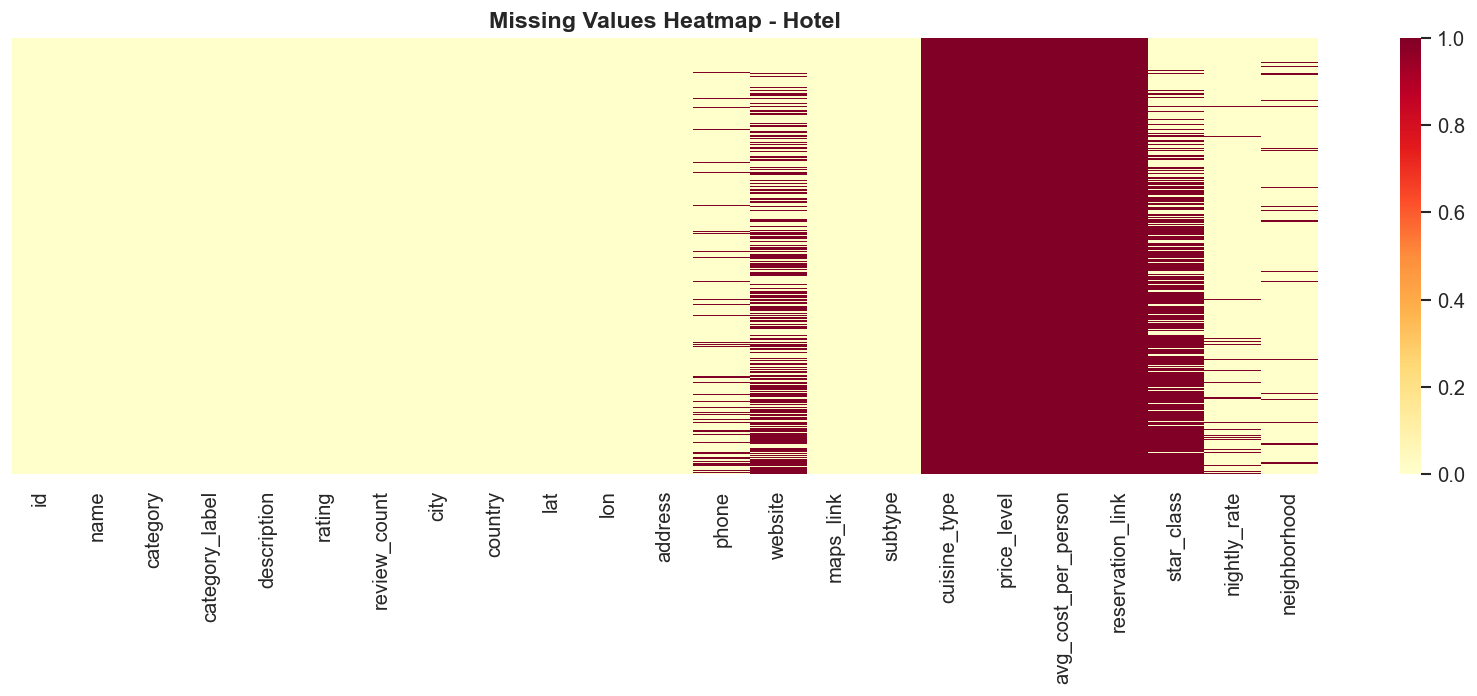


Exact duplicate rows: 0
Duplicate id values: 0
[WARN] 1 rows with coordinates outside Cairo area

DATA QUALITY REPORT - HOTEL
                             Value
Total Records              771.000
Total Columns               35.000
Exact Duplicates             0.000
Columns with Missing Data    9.000
Total Missing Cells       4079.000
Memory Usage (MB)            2.000

  DATA QUALITY: RESTAURANT (4,276 places)

Columns with Missing Values (restaurant):
             column  missing_count  missing_pct
       nightly_rate           4276      100.000
         star_class           4276      100.000
   reservation_link           4276      100.000
       neighborhood           4276      100.000
        price_level           4100       95.880
avg_cost_per_person           2680       62.680
            website           2357       55.120
       cuisine_type           1265       29.580
              phone            864       20.210


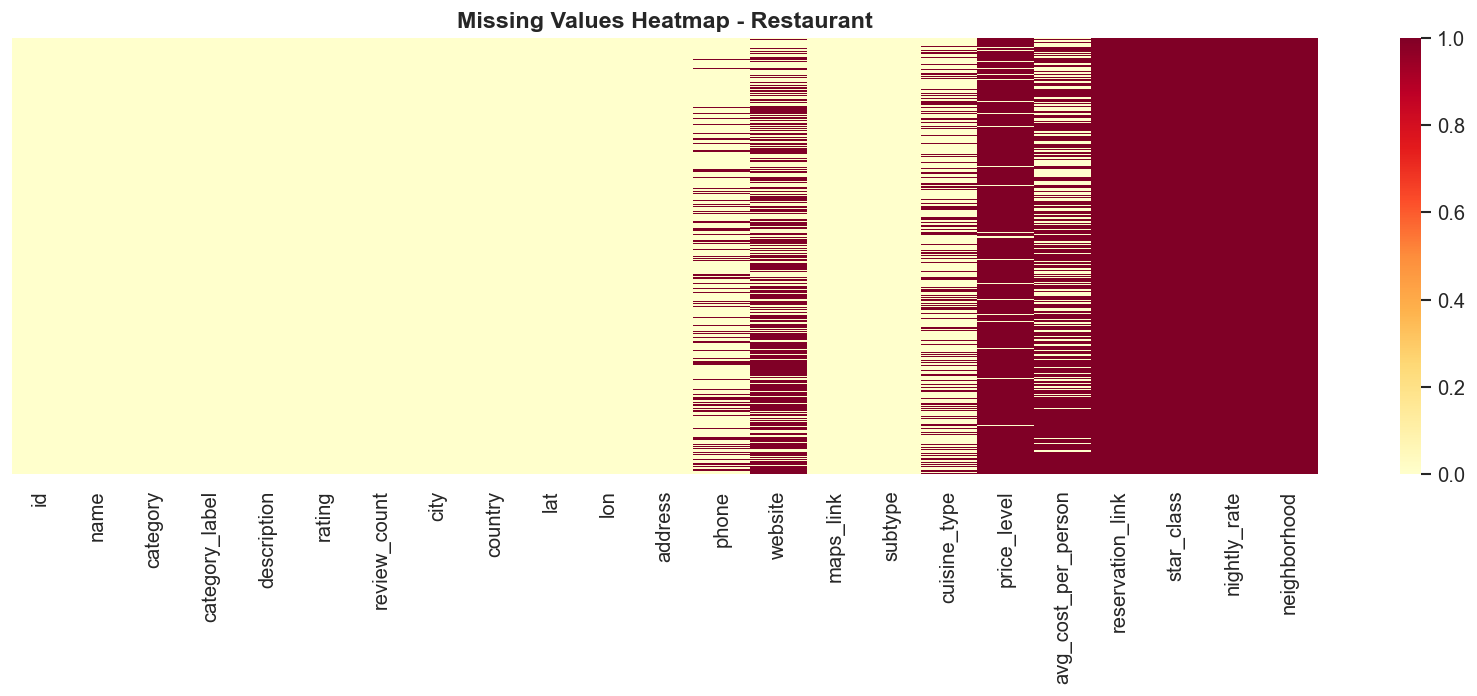


Exact duplicate rows: 0
Duplicate id values: 0
No data consistency issues found!

DATA QUALITY REPORT - RESTAURANT
                              Value
Total Records              4276.000
Total Columns                35.000
Exact Duplicates              0.000
Columns with Missing Data     9.000
Total Missing Cells       28370.000
Memory Usage (MB)            12.900

  DATA QUALITY: ATTRACTIONS (1,509 places)

Columns with Missing Values (attractions):
             column  missing_count  missing_pct
       neighborhood           1509      100.000
avg_cost_per_person           1509      100.000
        price_level           1509      100.000
       nightly_rate           1509      100.000
   reservation_link           1509      100.000
         star_class           1509      100.000
       cuisine_type           1508       99.930
            website            880       58.320
              phone            639       42.350


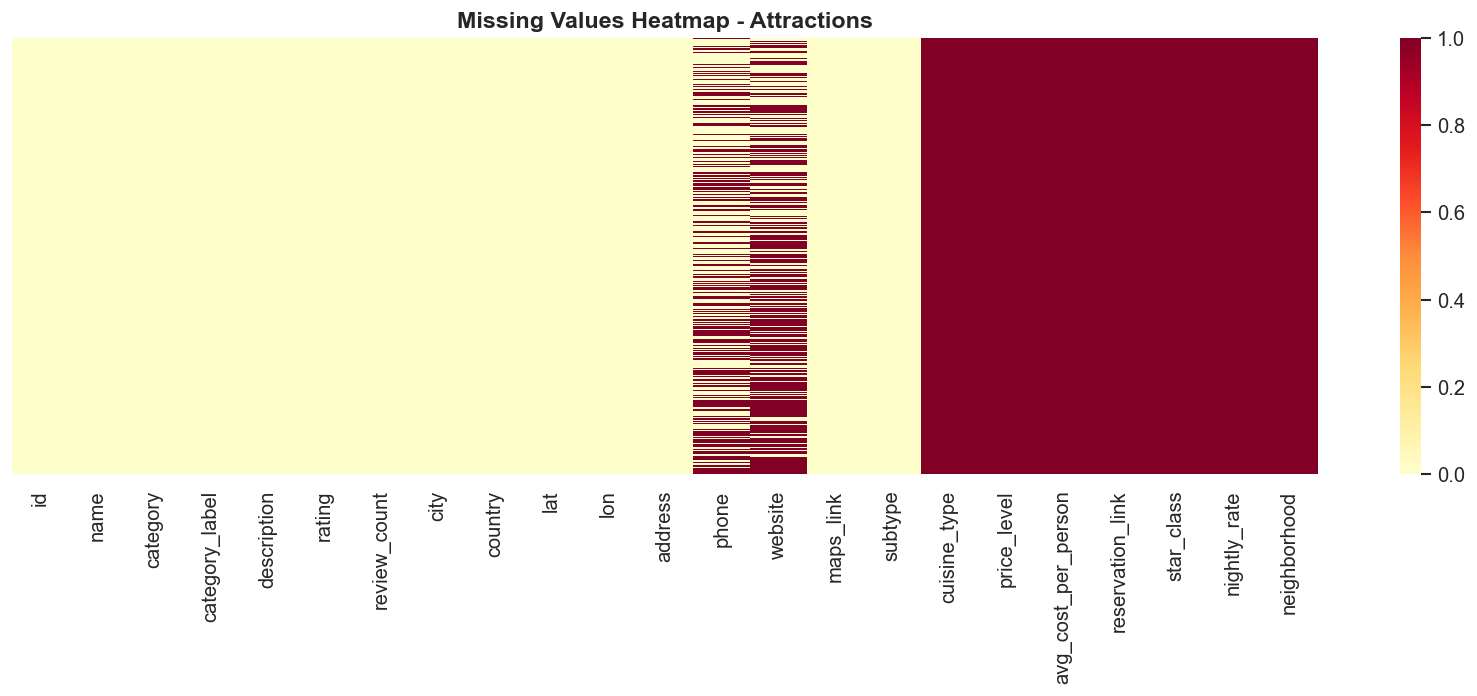


Exact duplicate rows: 0
Duplicate id values: 0
No data consistency issues found!

DATA QUALITY REPORT - ATTRACTIONS
                              Value
Total Records              1509.000
Total Columns                35.000
Exact Duplicates              0.000
Columns with Missing Data     9.000
Total Missing Cells       12081.000
Memory Usage (MB)             4.000


In [12]:
for cat_name, cat_df in categories.items():
    print(f'\n{"="*70}')
    print(f'  DATA QUALITY: {cat_name.upper()} ({len(cat_df):,} places)')
    print(f'{"="*70}')

    cat_hashable = [c for c in hashable_cols if c in cat_df.columns]

    # Missing values
    missing = pd.DataFrame({
        'column': cat_df[cat_hashable].columns,
        'missing_count': cat_df[cat_hashable].isnull().sum().values,
        'missing_pct': (cat_df[cat_hashable].isnull().sum().values / len(cat_df) * 100).round(2)
    }).sort_values('missing_pct', ascending=False).reset_index(drop=True)

    missing = missing[missing['missing_count'] > 0]

    if len(missing) > 0:
        print(f'\nColumns with Missing Values ({cat_name}):')
        print(missing.to_string(index=False))
        fig, ax = plt.subplots(figsize=(14, 6))
        sns.heatmap(cat_df[cat_hashable].isnull(), cbar=True, yticklabels=False, cmap='YlOrRd', ax=ax)
        ax.set_title(f'Missing Values Heatmap - {cat_name.title()}', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig(f'../outputs/figures/{cat_name}_missing_values_heatmap.png', bbox_inches='tight')
        plt.show()
    else:
        print(f'No missing values found for {cat_name}!')

    # Duplicates
    exact_dups = cat_df[cat_hashable].duplicated().sum()
    print(f'\nExact duplicate rows: {exact_dups}')
    if 'id' in cat_df.columns:
        id_dups = cat_df['id'].duplicated().sum()
        print(f'Duplicate id values: {id_dups}')

    # Consistency checks
    issues = []
    if 'lat' in cat_df.columns and 'lon' in cat_df.columns:
        bad_coords = cat_df[(cat_df['lat'] < 28) | (cat_df['lat'] > 32) | (cat_df['lon'] < 29) | (cat_df['lon'] > 33)]
        if len(bad_coords) > 0:
            issues.append(f'[WARN] {len(bad_coords)} rows with coordinates outside Cairo area')
    if 'rating' in cat_df.columns:
        bad_ratings = cat_df[(cat_df['rating'] < 0) | (cat_df['rating'] > 5)]
        if len(bad_ratings) > 0:
            issues.append(f'[WARN] {len(bad_ratings)} rows with rating outside [0, 5]')
    if 'review_count' in cat_df.columns:
        neg_reviews = cat_df[cat_df['review_count'] < 0]
        if len(neg_reviews) > 0:
            issues.append(f'[WARN] {len(neg_reviews)} rows with negative review_count')

    if issues:
        print('\n'.join(issues))
    else:
        print('No data consistency issues found!')

    # Quality report
    quality_report = {
        'Total Records': len(cat_df),
        'Total Columns': len(cat_df.columns),
        'Exact Duplicates': int(exact_dups),
        'Columns with Missing Data': int((cat_df[cat_hashable].isnull().sum() > 0).sum()),
        'Total Missing Cells': int(cat_df[cat_hashable].isnull().sum().sum()),
        'Memory Usage (MB)': round(cat_df.memory_usage(deep=True).sum() / 1024**2, 1),
    }
    report_df = pd.DataFrame.from_dict(quality_report, orient='index', columns=['Value'])
    print(f'\nDATA QUALITY REPORT - {cat_name.upper()}')
    print('=' * 45)
    print(report_df.to_string())

# ---
# ## 5. Univariate Analysis - Numerical Variables (Per Category)


  UNIVARIATE NUMERICAL: HOTEL (771 places)


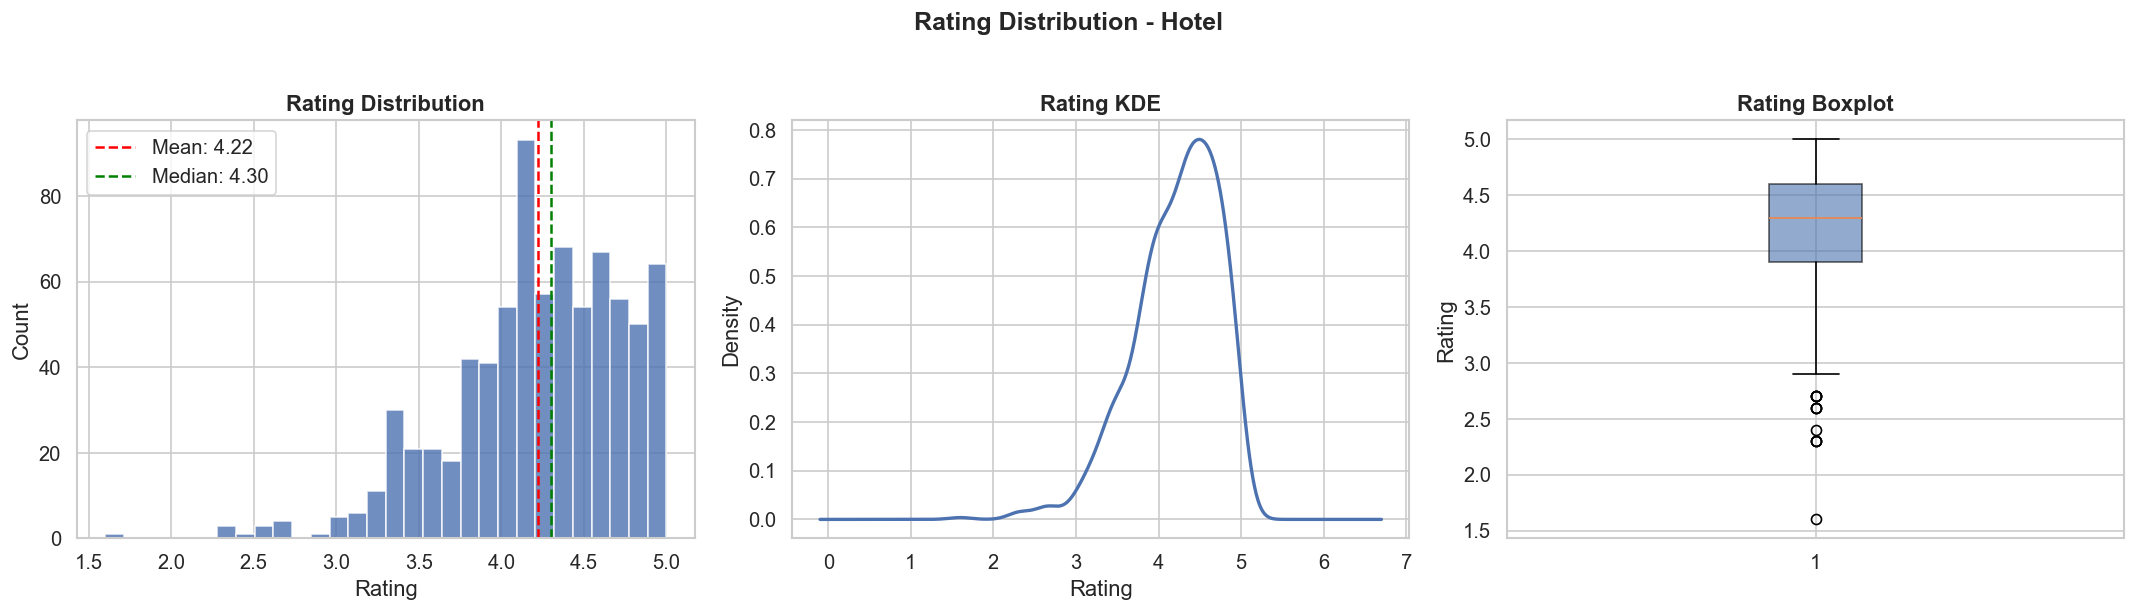

Rating Stats: mean=4.22, median=4.30, std=0.52, skew=-0.93

  UNIVARIATE NUMERICAL: RESTAURANT (4,276 places)


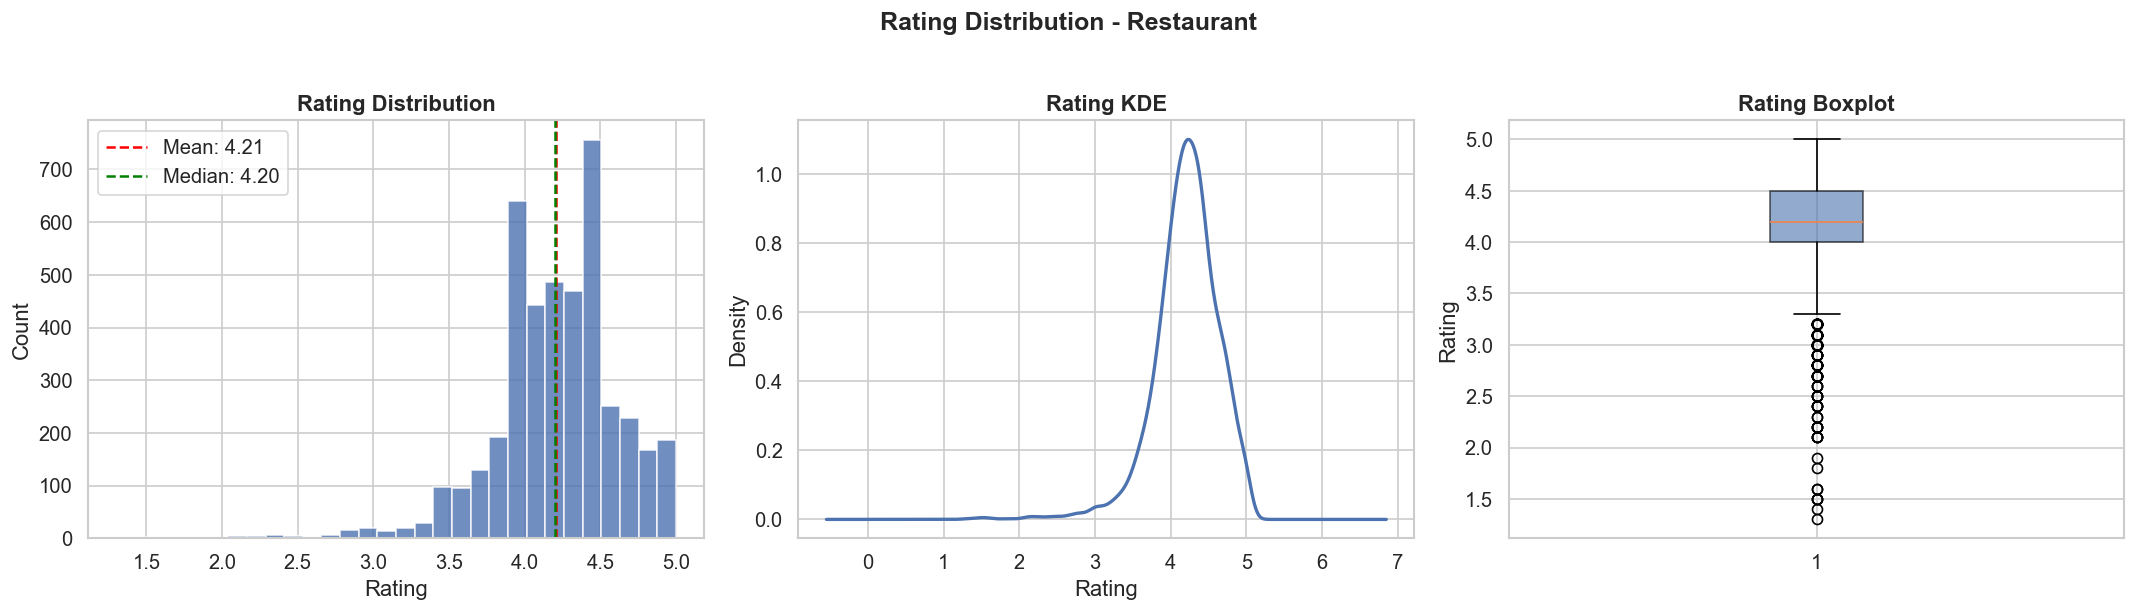

Rating Stats: mean=4.21, median=4.20, std=0.43, skew=-1.23

  UNIVARIATE NUMERICAL: ATTRACTIONS (1,509 places)


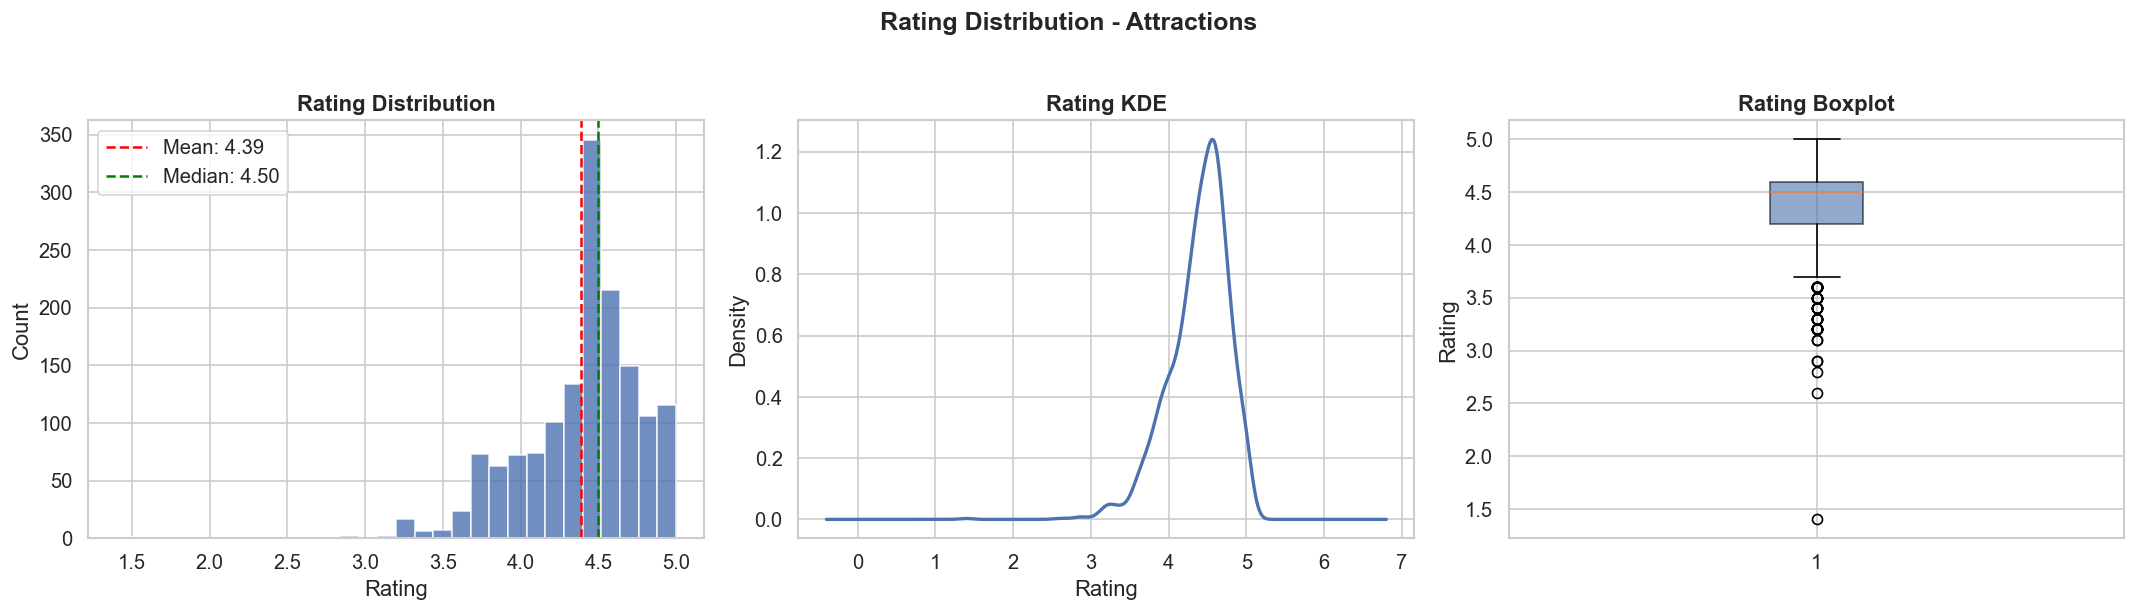

Rating Stats: mean=4.39, median=4.50, std=0.38, skew=-1.14


In [13]:
for cat_name, cat_df in categories.items():
    print(f'\n{"="*70}')
    print(f'  UNIVARIATE NUMERICAL: {cat_name.upper()} ({len(cat_df):,} places)')
    print(f'{"="*70}')

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Histogram
    axes[0].hist(cat_df['rating'].dropna(), bins=30, color='#4C72B0', edgecolor='white', alpha=0.8)
    axes[0].axvline(cat_df['rating'].mean(), color='red', linestyle='--', label=f"Mean: {cat_df['rating'].mean():.2f}")
    axes[0].axvline(cat_df['rating'].median(), color='green', linestyle='--', label=f"Median: {cat_df['rating'].median():.2f}")
    axes[0].set_title('Rating Distribution', fontweight='bold')
    axes[0].set_xlabel('Rating')
    axes[0].set_ylabel('Count')
    axes[0].legend()

    # KDE
    cat_df['rating'].dropna().plot(kind='kde', ax=axes[1], color='#4C72B0', linewidth=2)
    axes[1].set_title('Rating KDE', fontweight='bold')
    axes[1].set_xlabel('Rating')

    # Boxplot
    axes[2].boxplot(cat_df['rating'].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='#4C72B0', alpha=0.6))
    axes[2].set_title('Rating Boxplot', fontweight='bold')
    axes[2].set_ylabel('Rating')

    plt.suptitle(f'Rating Distribution - {cat_name.title()}', fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f'../outputs/figures/{cat_name}_rating_distribution.png', bbox_inches='tight')
    plt.show()

    print(f"Rating Stats: mean={cat_df['rating'].mean():.2f}, median={cat_df['rating'].median():.2f}, "
          f"std={cat_df['rating'].std():.2f}, skew={cat_df['rating'].skew():.2f}")


  REVIEW COUNT ANALYSIS: HOTEL (771 places)


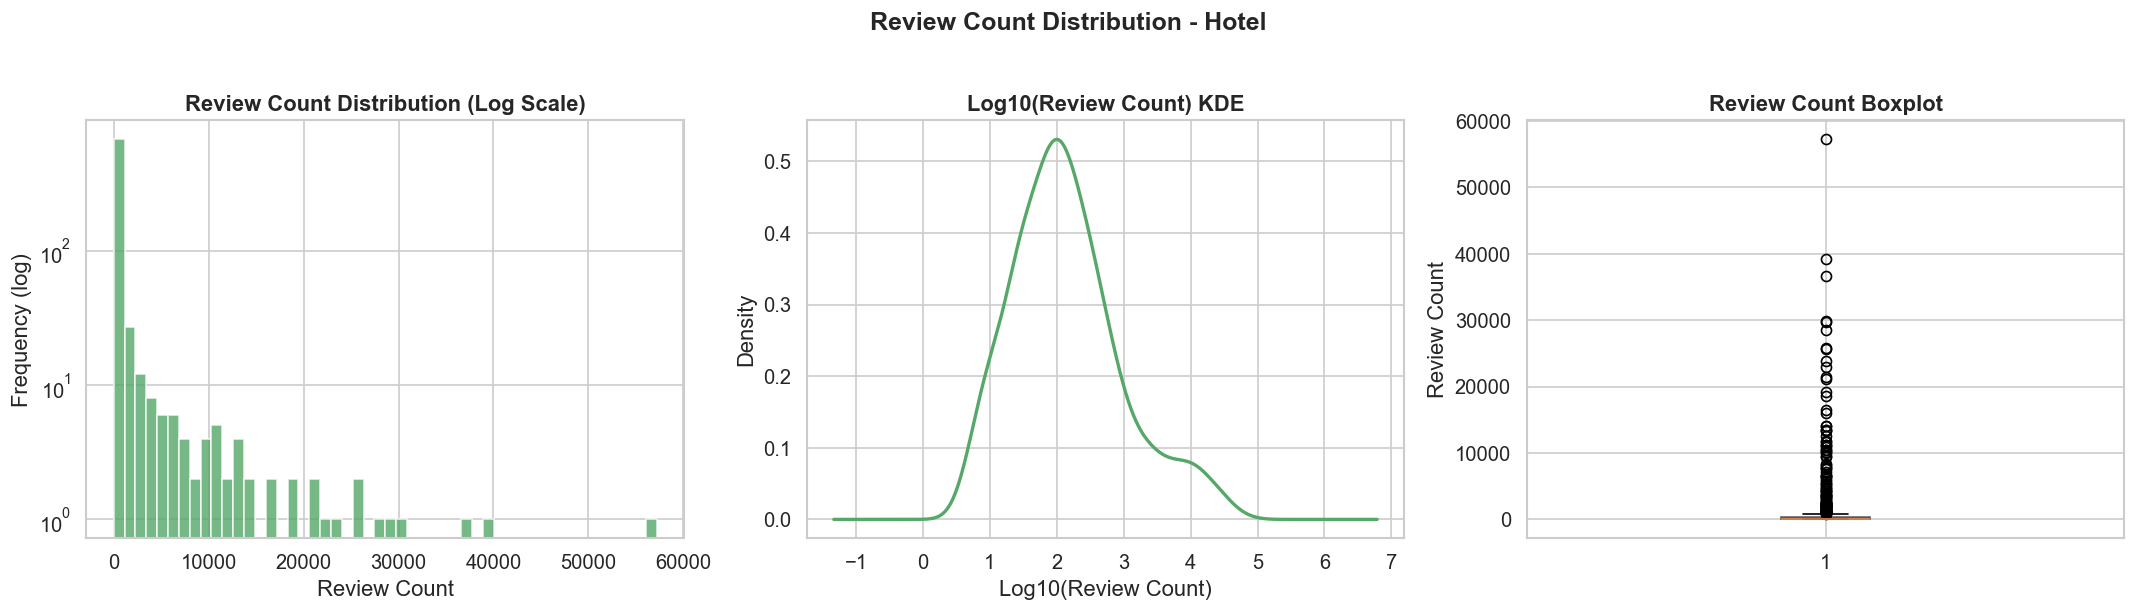

Review Stats: mean=1263, median=112, max=57,217, places with 0 reviews: 0

  REVIEW COUNT ANALYSIS: RESTAURANT (4,276 places)


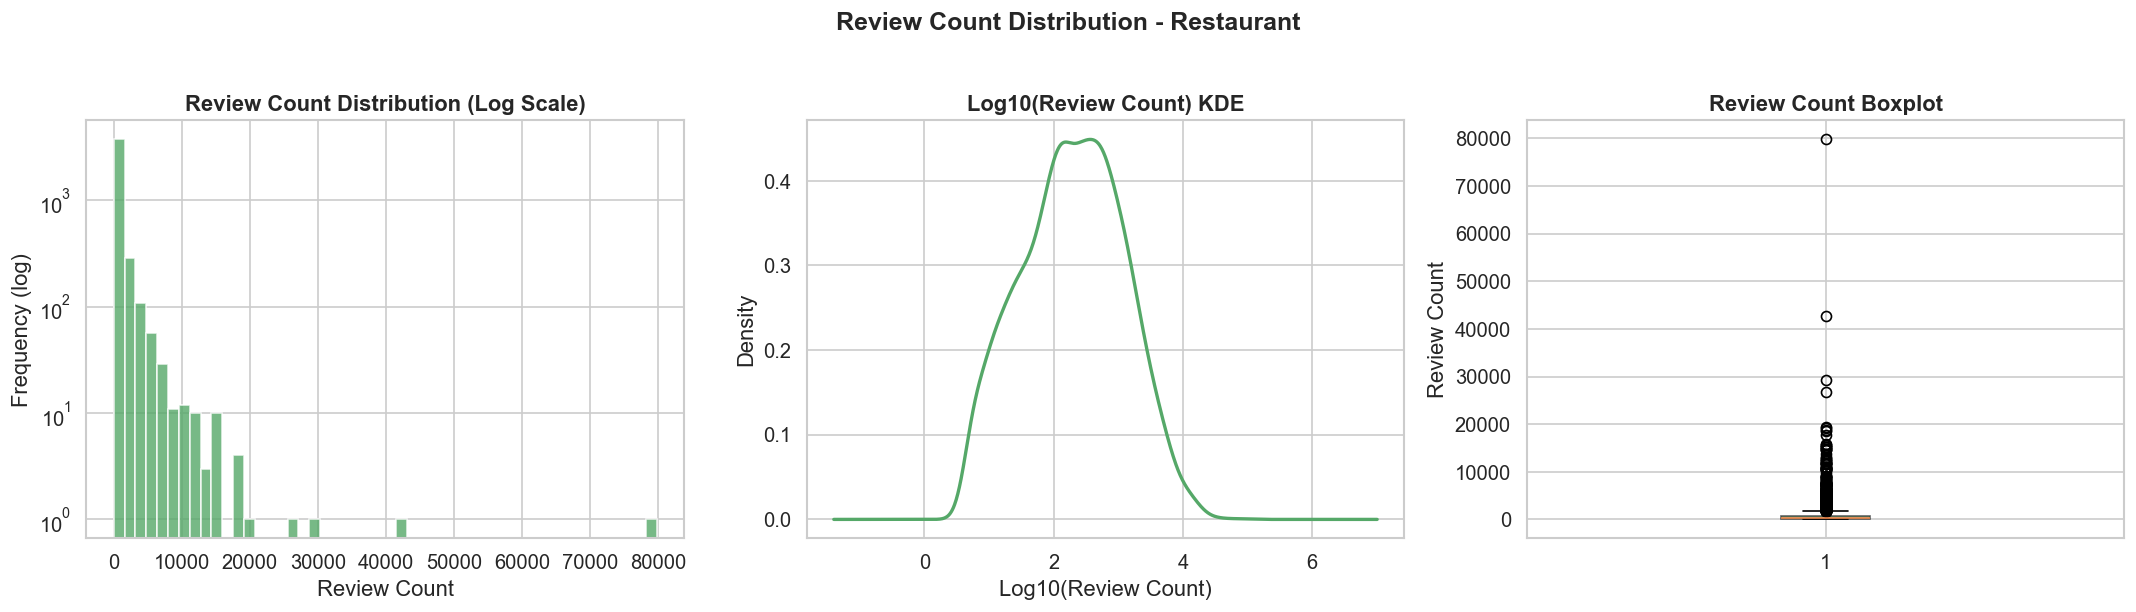

Review Stats: mean=834, median=206, max=79,781, places with 0 reviews: 0

  REVIEW COUNT ANALYSIS: ATTRACTIONS (1,509 places)


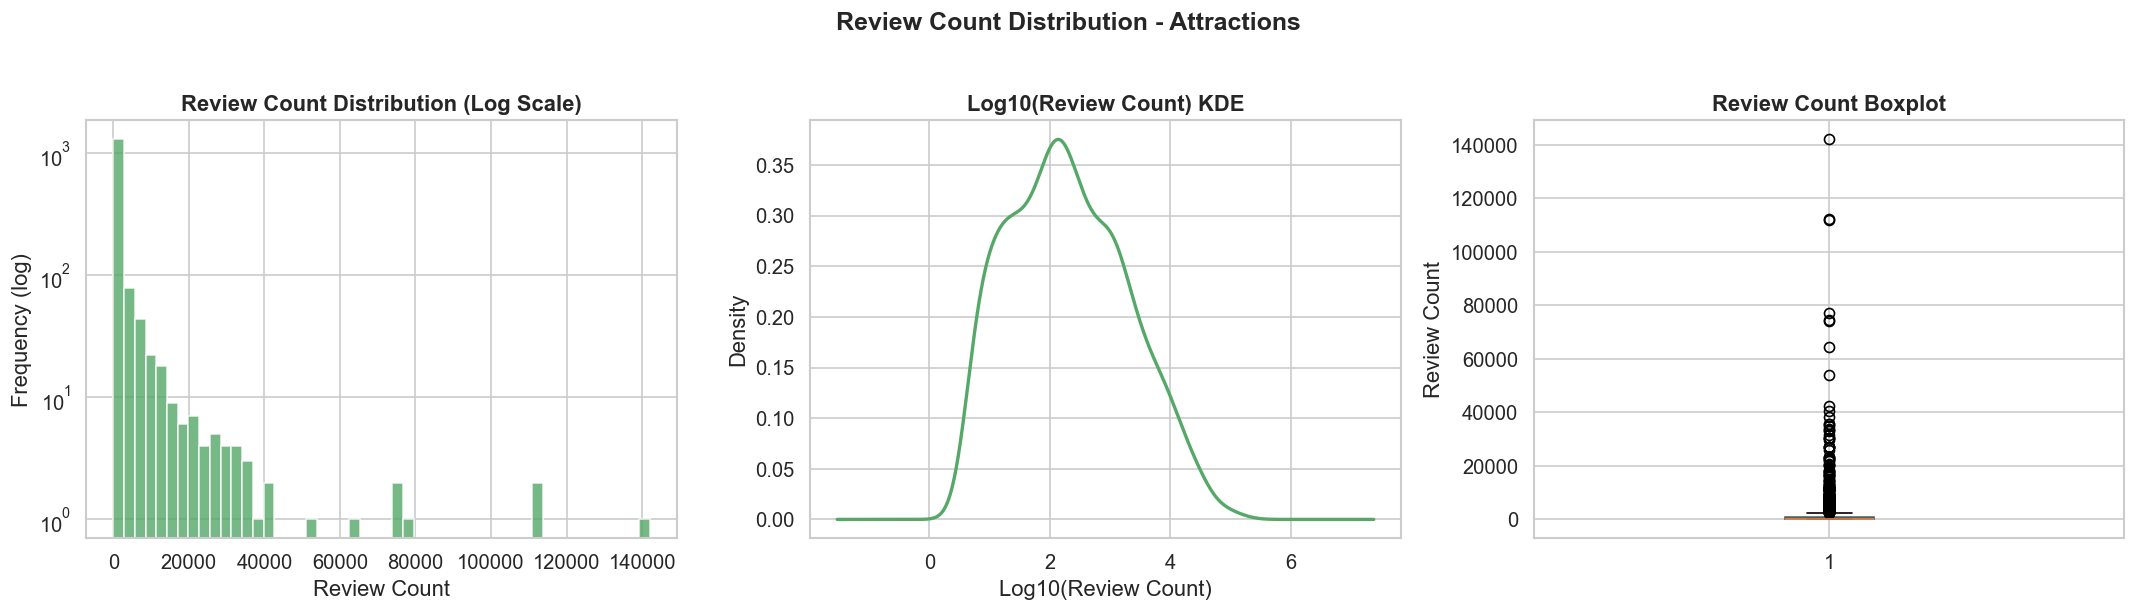

Review Stats: mean=2221, median=171, max=142,032, places with 0 reviews: 0


In [14]:
for cat_name, cat_df in categories.items():
    print(f'\n{"="*70}')
    print(f'  REVIEW COUNT ANALYSIS: {cat_name.upper()} ({len(cat_df):,} places)')
    print(f'{"="*70}')

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    reviews = cat_df['review_count'].dropna()
    reviews_positive = reviews[reviews > 0]

    axes[0].hist(reviews_positive, bins=50, color='#55A868', edgecolor='white', alpha=0.8, log=True)
    axes[0].set_title('Review Count Distribution (Log Scale)', fontweight='bold')
    axes[0].set_xlabel('Review Count')
    axes[0].set_ylabel('Frequency (log)')

    log_reviews = np.log10(reviews_positive)
    log_reviews.plot(kind='kde', ax=axes[1], color='#55A868', linewidth=2)
    axes[1].set_title('Log10(Review Count) KDE', fontweight='bold')
    axes[1].set_xlabel('Log10(Review Count)')

    axes[2].boxplot(reviews_positive, vert=True, patch_artist=True,
                    boxprops=dict(facecolor='#55A868', alpha=0.6))
    axes[2].set_title('Review Count Boxplot', fontweight='bold')
    axes[2].set_ylabel('Review Count')

    plt.suptitle(f'Review Count Distribution - {cat_name.title()}', fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f'../outputs/figures/{cat_name}_review_count_distribution.png', bbox_inches='tight')
    plt.show()

    print(f"Review Stats: mean={reviews.mean():.0f}, median={reviews.median():.0f}, "
          f"max={reviews.max():,}, places with 0 reviews: {(reviews == 0).sum()}")

# ---
# ## 6. Univariate Analysis - Categorical / Subcategory Variables (Per Category)


  SUBCATEGORY DISTRIBUTION: HOTEL (771 places)


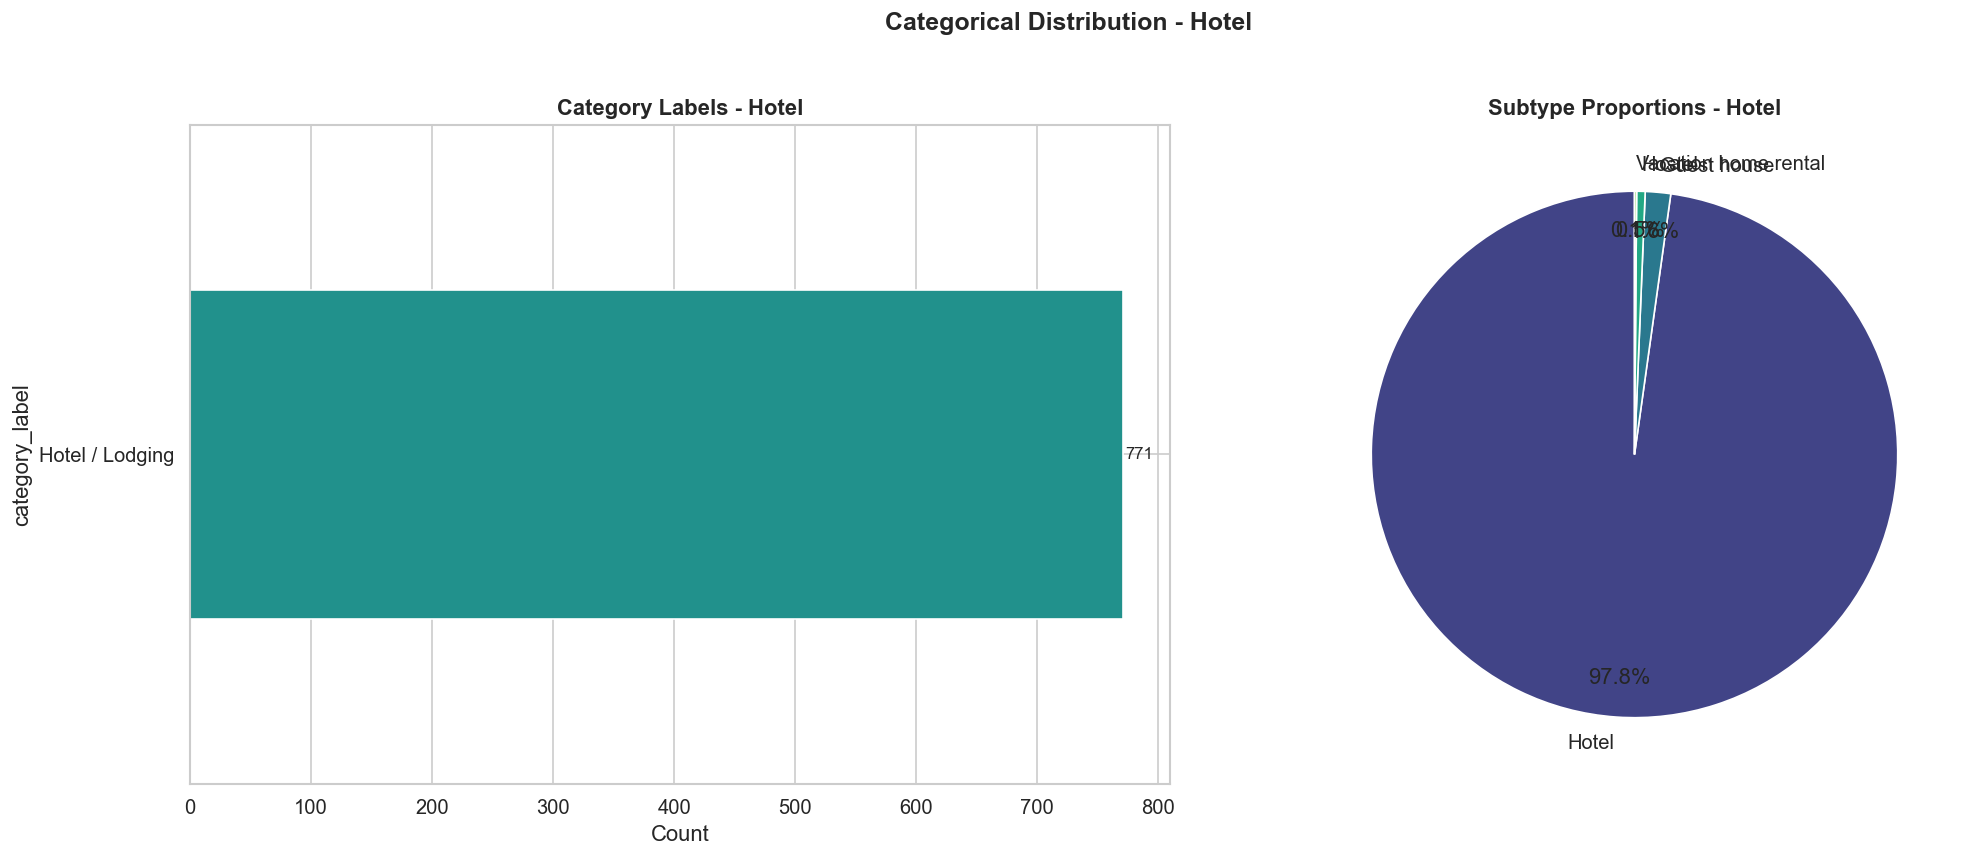


Category Label Counts (hotel):
  Hotel / Lodging                            771 (100.0%)

Subtype Counts (hotel):
  Hotel                                      754 (97.8%)
  Guest house                                 12 (1.6%)
  Hostel                                       4 (0.5%)
  Vacation home rental                         1 (0.1%)

  SUBCATEGORY DISTRIBUTION: RESTAURANT (4,276 places)


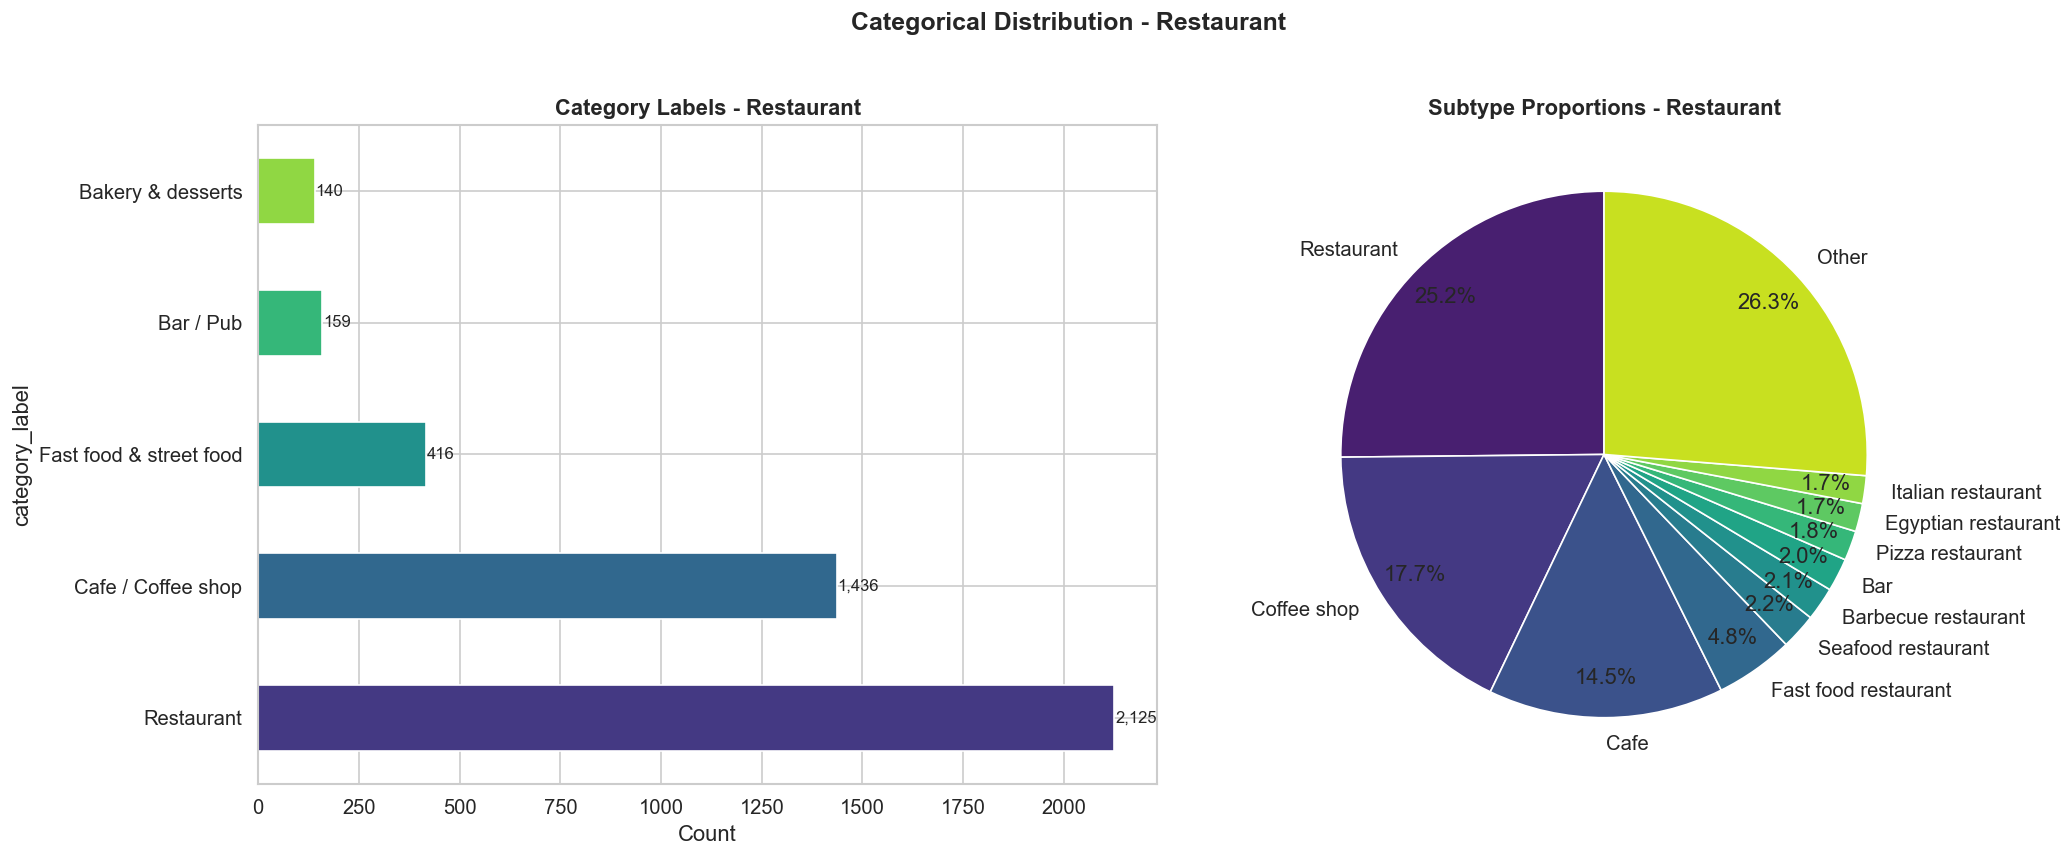


Category Label Counts (restaurant):
  Restaurant                               2,125 (49.7%)
  Cafe / Coffee shop                       1,436 (33.6%)
  Fast food & street food                    416 (9.7%)
  Bar / Pub                                  159 (3.7%)
  Bakery & desserts                          140 (3.3%)

Subtype Counts (restaurant):
  Restaurant                               1,076 (25.2%)
  Coffee shop                                758 (17.7%)
  Cafe                                       618 (14.5%)
  Fast food restaurant                       206 (4.8%)
  Seafood restaurant                          94 (2.2%)
  Barbecue restaurant                         88 (2.1%)
  Bar                                         87 (2.0%)
  Pizza restaurant                            78 (1.8%)
  Egyptian restaurant                         74 (1.7%)
  Italian restaurant                          73 (1.7%)
  Syrian restaurant                           53 (1.2%)
  Lebanese restaurant           

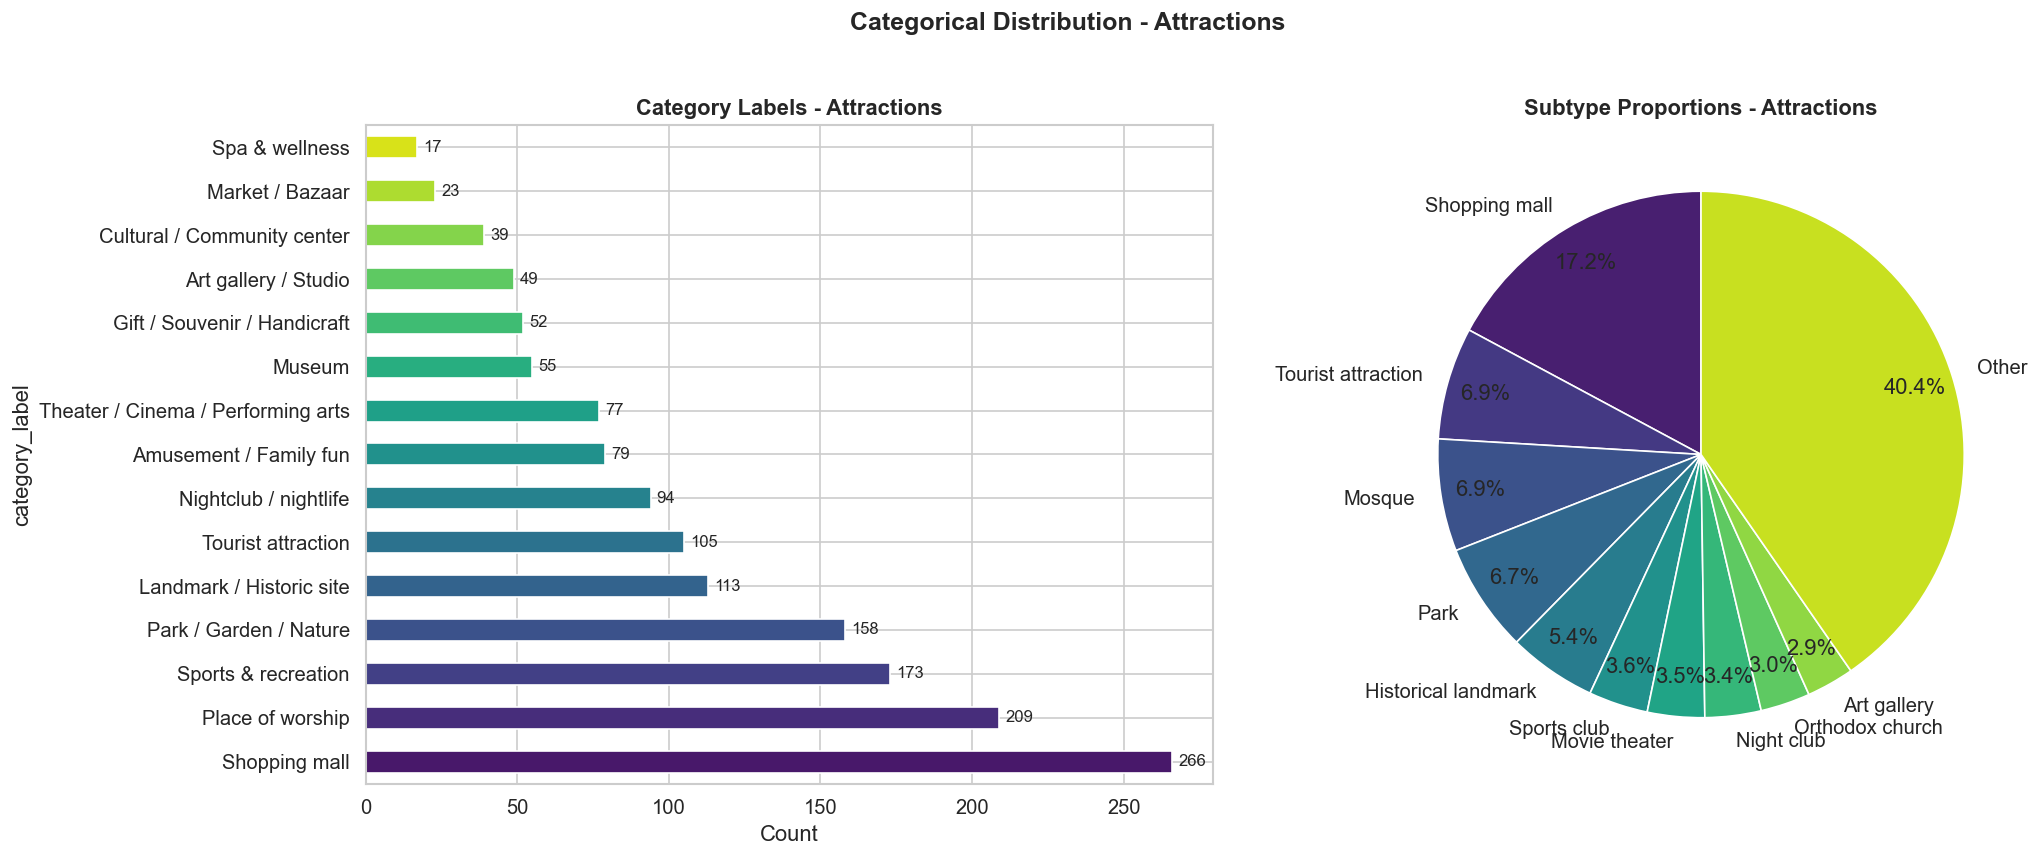


Category Label Counts (attractions):
  Shopping mall                              266 (17.6%)
  Place of worship                           209 (13.9%)
  Sports & recreation                        173 (11.5%)
  Park / Garden / Nature                     158 (10.5%)
  Landmark / Historic site                   113 (7.5%)
  Tourist attraction                         105 (7.0%)
  Nightclub / nightlife                       94 (6.2%)
  Amusement / Family fun                      79 (5.2%)
  Theater / Cinema / Performing arts          77 (5.1%)
  Museum                                      55 (3.6%)
  Gift / Souvenir / Handicraft                52 (3.4%)
  Art gallery / Studio                        49 (3.2%)
  Cultural / Community center                 39 (2.6%)
  Market / Bazaar                             23 (1.5%)
  Spa & wellness                              17 (1.1%)

Subtype Counts (attractions):
  Shopping mall                              259 (17.2%)
  Tourist attraction          

In [15]:
for cat_name, cat_df in categories.items():
    print(f'\n{"="*70}')
    print(f'  SUBCATEGORY DISTRIBUTION: {cat_name.upper()} ({len(cat_df):,} places)')
    print(f'{"="*70}')

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # Category label distribution
    if 'category_label' in cat_df.columns:
        label_counts = cat_df['category_label'].value_counts()
        label_counts.plot(kind='barh', ax=axes[0], color=sns.color_palette('viridis', len(label_counts)))
        axes[0].set_title(f'Category Labels - {cat_name.title()}', fontweight='bold')
        axes[0].set_xlabel('Count')
        for i, v in enumerate(label_counts.values):
            axes[0].text(v + 2, i, f'{v:,}', va='center', fontsize=10)

    # Subtype distribution
    if 'subtype' in cat_df.columns:
        subtype_counts = cat_df['subtype'].dropna().value_counts()
        if len(subtype_counts) > 0:
            top_n = 10
            top_subtypes = subtype_counts.head(top_n)
            other = subtype_counts[top_n:].sum() if len(subtype_counts) > top_n else 0
            pie_data = pd.concat([top_subtypes, pd.Series({'Other': other})]) if other > 0 else top_subtypes
            colors = sns.color_palette('viridis', len(pie_data))
            axes[1].pie(pie_data, labels=pie_data.index, autopct='%1.1f%%',
                        colors=colors, startangle=90, pctdistance=0.85)
            axes[1].set_title(f'Subtype Proportions - {cat_name.title()}', fontweight='bold')
        else:
            axes[1].text(0.5, 0.5, 'No subtype data', ha='center', va='center', fontsize=14)
            axes[1].set_title(f'Subtype Proportions - {cat_name.title()}', fontweight='bold')
    else:
        axes[1].text(0.5, 0.5, 'No subtype column', ha='center', va='center', fontsize=14)
        axes[1].set_title(f'Subtype Proportions - {cat_name.title()}', fontweight='bold')

    plt.suptitle(f'Categorical Distribution - {cat_name.title()}', fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f'../outputs/figures/{cat_name}_category_distribution.png', bbox_inches='tight')
    plt.show()

    print(f'\nCategory Label Counts ({cat_name}):')
    if 'category_label' in cat_df.columns:
        for label, count in cat_df['category_label'].value_counts().items():
            print(f'  {label:40s} {count:>5,} ({count/len(cat_df)*100:.1f}%)')

    if 'subtype' in cat_df.columns:
        print(f'\nSubtype Counts ({cat_name}):')
        for st, count in cat_df['subtype'].value_counts().head(15).items():
            print(f'  {str(st):40s} {count:>5,} ({count/len(cat_df)*100:.1f}%)')


  DISTRICT DISTRIBUTION: HOTEL (771 places)


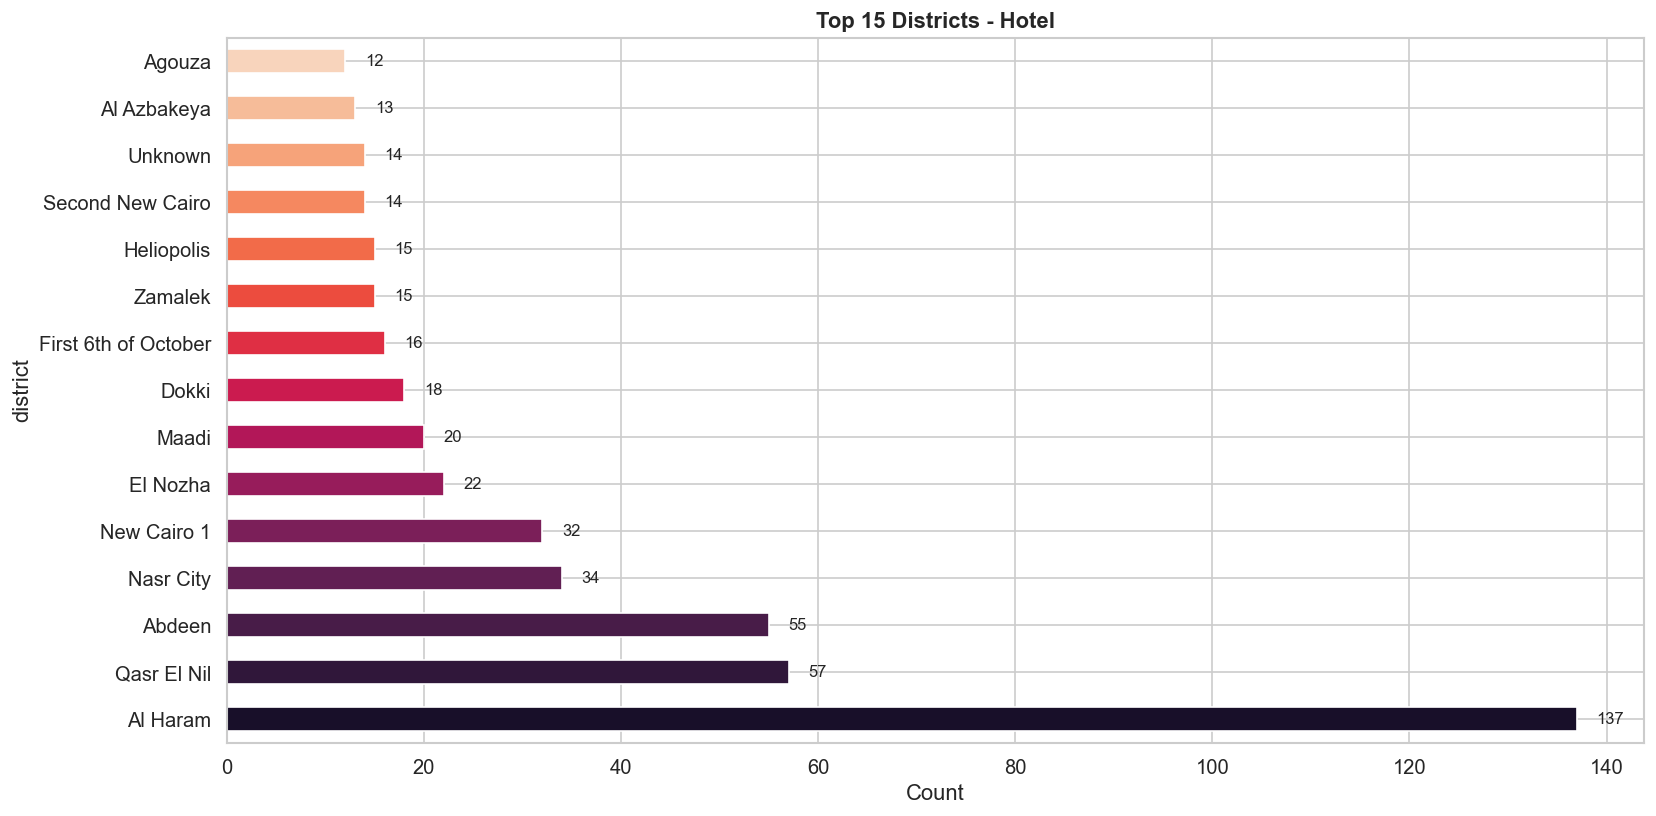


  DISTRICT DISTRIBUTION: RESTAURANT (4,276 places)


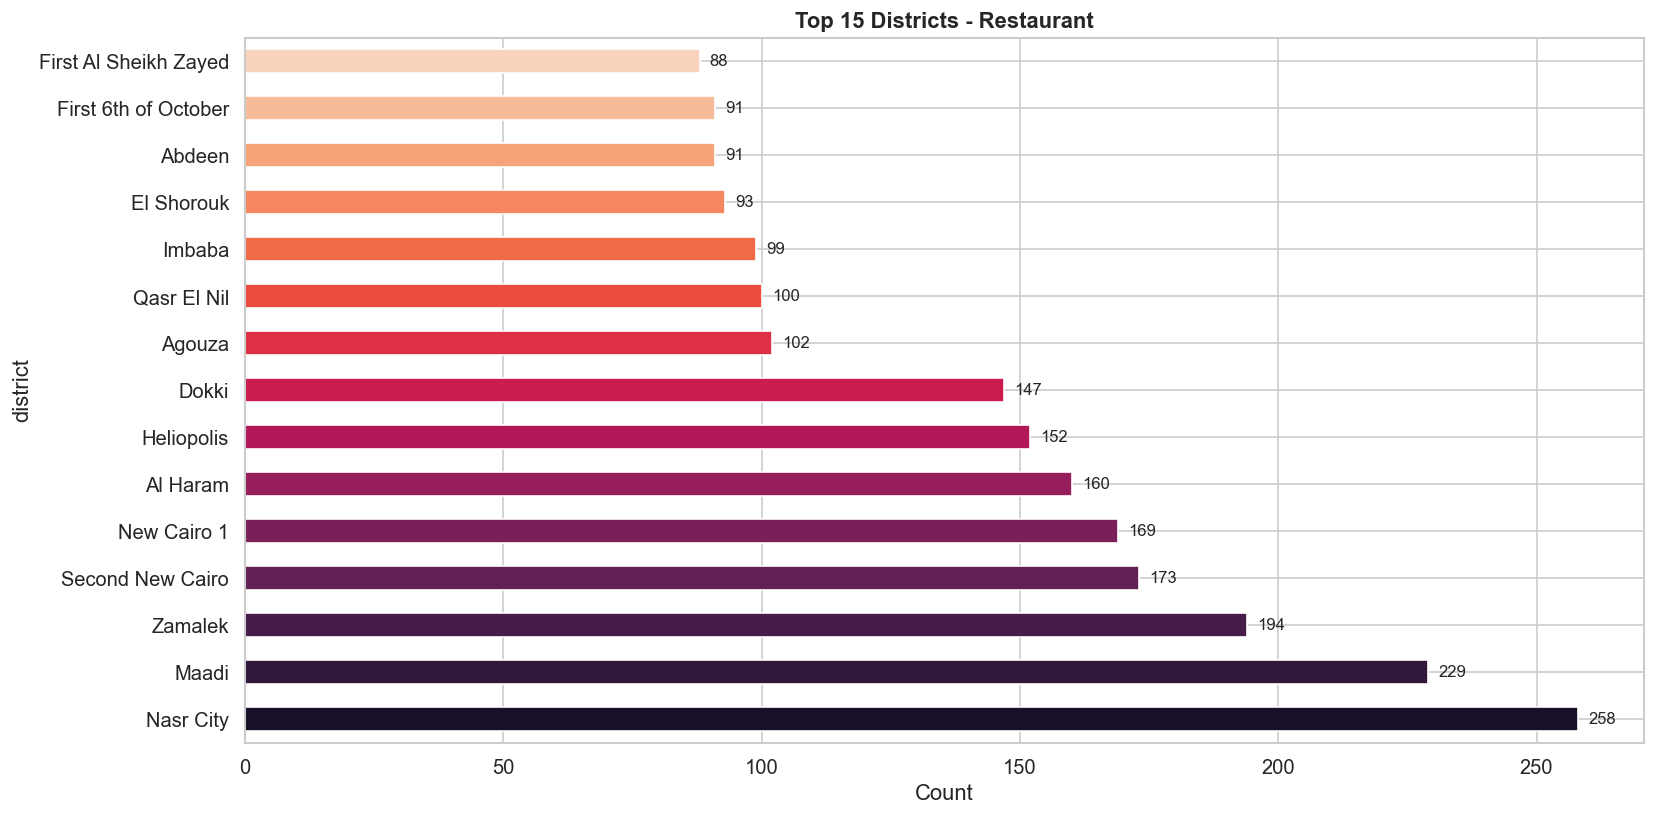


  DISTRICT DISTRIBUTION: ATTRACTIONS (1,509 places)


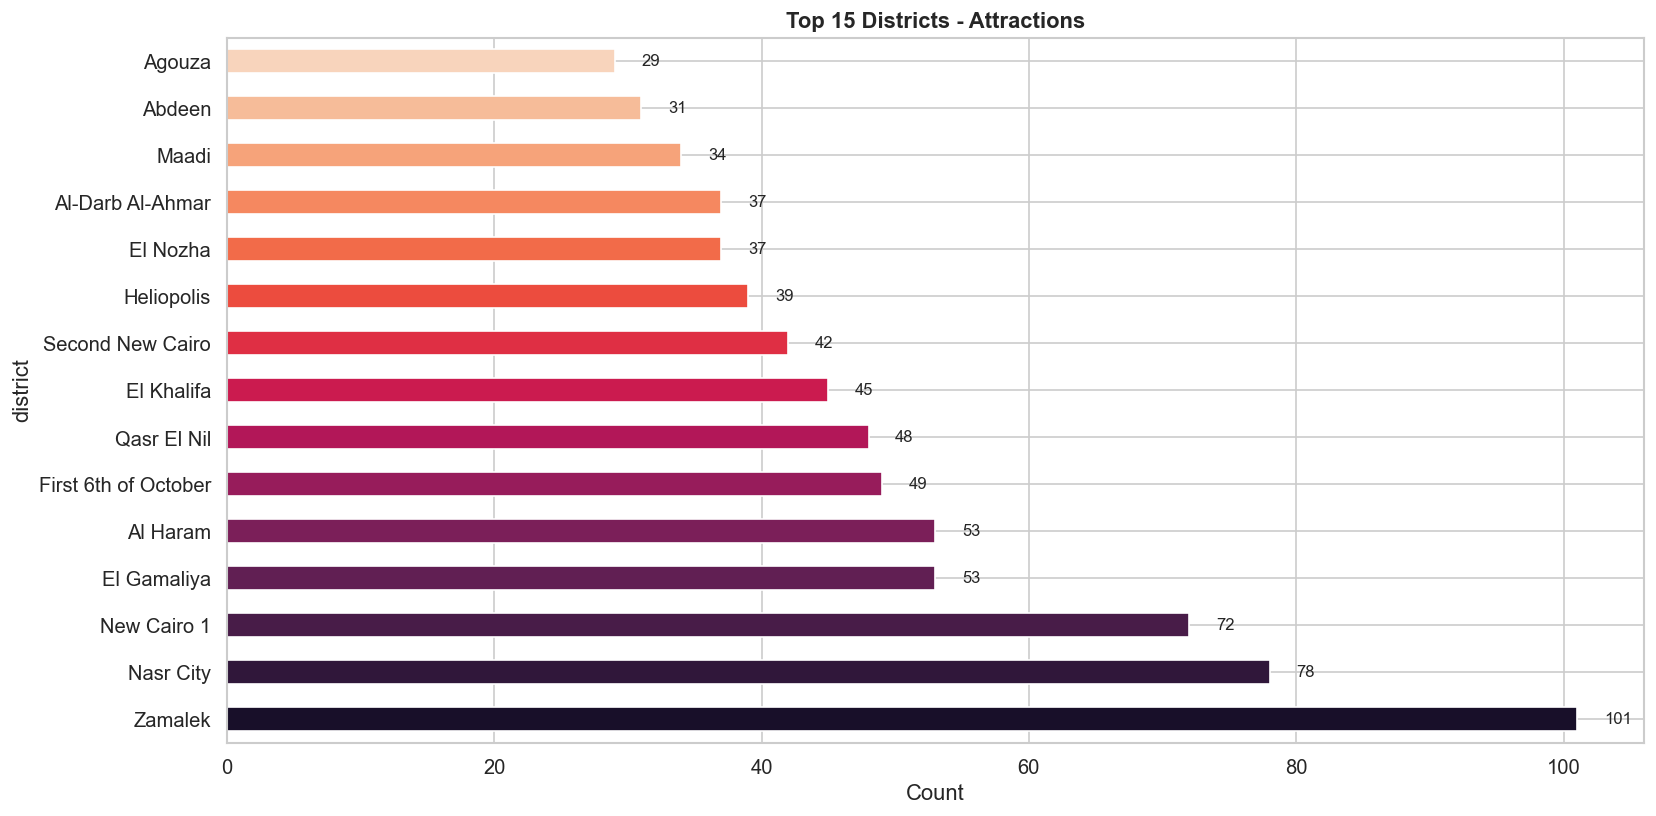

In [16]:
# District distribution per category
for cat_name, cat_df in categories.items():
    print(f'\n{"="*70}')
    print(f'  DISTRICT DISTRIBUTION: {cat_name.upper()} ({len(cat_df):,} places)')
    print(f'{"="*70}')

    dist_counts = cat_df['district'].value_counts().head(15)

    fig, ax = plt.subplots(figsize=(14, 7))
    dist_counts.plot(kind='barh', ax=ax, color=sns.color_palette('rocket', len(dist_counts)))
    ax.set_title(f'Top 15 Districts - {cat_name.title()}', fontweight='bold')
    ax.set_xlabel('Count')
    for i, v in enumerate(dist_counts.values):
        ax.text(v + 2, i, f'{v:,}', va='center', fontsize=10)
    plt.tight_layout()
    plt.savefig(f'../outputs/figures/{cat_name}_district_distribution.png', bbox_inches='tight')
    plt.show()

# ---
# ## 7. Geographical Analysis (Per Category)

In [17]:
cairo_center = [df['lat'].median(), df['lon'].median()]

for cat_name, cat_df in categories.items():
    print(f'\n{"="*70}')
    print(f'  GEOGRAPHICAL ANALYSIS: {cat_name.upper()} ({len(cat_df):,} places)')
    print(f'{"="*70}')

    # Interactive Folium map
    sample_size = min(2000, len(cat_df))
    df_sample = cat_df.sample(n=sample_size, random_state=42)

    m = folium.Map(location=cairo_center, zoom_start=12, tiles='CartoDB positron')
    marker_cluster = MarkerCluster().add_to(m)

    for _, row in df_sample.iterrows():
        folium.CircleMarker(
            location=[row['lat'], row['lon']],
            radius=4, color='#4C72B0', fill=True, fill_opacity=0.7,
            popup=folium.Popup(
                f"<b>{row['name']}</b><br>"
                f"Category: {row['category']}<br>"
                f"Rating: {row.get('rating', 'N/A')}<br>"
                f"Reviews: {row.get('review_count', 0):,}",
                max_width=250
            ),
        ).add_to(marker_cluster)

    m.save(f'../outputs/figures/{cat_name}_places_map.html')
    print(f'Interactive map saved: outputs/figures/{cat_name}_places_map.html ({sample_size:,} places)')

    # Heatmap
    m_heat = folium.Map(location=cairo_center, zoom_start=12, tiles='CartoDB positron')
    heat_data = cat_df[['lat', 'lon']].dropna().values.tolist()
    HeatMap(heat_data, radius=15, blur=20, max_zoom=13).add_to(m_heat)
    m_heat.save(f'../outputs/figures/{cat_name}_density_heatmap.html')
    print(f'Density heatmap saved: outputs/figures/{cat_name}_density_heatmap.html')

    # High-rated places map
    high_rated = cat_df[cat_df['rating'] >= 4.5]
    if len(high_rated) > 0:
        high_rated_sample = high_rated.sample(min(1000, len(high_rated)), random_state=42)
        m_hr = folium.Map(location=cairo_center, zoom_start=12, tiles='CartoDB positron')
        for _, row in high_rated_sample.iterrows():
            folium.CircleMarker(
                location=[row['lat'], row['lon']],
                radius=5, color='gold', fill=True, fill_opacity=0.8,
                popup=f"<b>{row['name']}</b><br>Rating: {row['rating']}<br>Reviews: {row.get('review_count', 0):,}",
            ).add_to(m_hr)
        m_hr.save(f'../outputs/figures/{cat_name}_high_rated_map.html')
        print(f'High-rated places map saved ({len(high_rated_sample):,} places)')

    # Static scatter map with Plotly
    fig = px.scatter_mapbox(
        cat_df.sample(min(2000, len(cat_df)), random_state=42),
        lat='lat', lon='lon',
        size='review_count', size_max=15,
        hover_name='name',
        hover_data={'rating': True, 'review_count': True},
        mapbox_style='carto-positron',
        center={'lat': cairo_center[0], 'lon': cairo_center[1]},
        zoom=11, title=f'{cat_name.title()} - Geographic Distribution', height=600,
    )
    fig.update_layout(margin=dict(l=0, r=0, t=40, b=0))
    fig.write_html(f'../outputs/figures/{cat_name}_plotly_map.html')
    print(f'Plotly map saved: outputs/figures/{cat_name}_plotly_map.html')

# ---
# ## 8. Rating & Review Analysis (Per Category)


  GEOGRAPHICAL ANALYSIS: HOTEL (771 places)
Interactive map saved: outputs/figures/hotel_places_map.html (771 places)
Density heatmap saved: outputs/figures/hotel_density_heatmap.html
High-rated places map saved (291 places)
Plotly map saved: outputs/figures/hotel_plotly_map.html

  GEOGRAPHICAL ANALYSIS: RESTAURANT (4,276 places)
Interactive map saved: outputs/figures/restaurant_places_map.html (2,000 places)
Density heatmap saved: outputs/figures/restaurant_density_heatmap.html
High-rated places map saved (1,000 places)
Plotly map saved: outputs/figures/restaurant_plotly_map.html

  GEOGRAPHICAL ANALYSIS: ATTRACTIONS (1,509 places)
Interactive map saved: outputs/figures/attractions_places_map.html (1,509 places)
Density heatmap saved: outputs/figures/attractions_density_heatmap.html
High-rated places map saved (763 places)
Plotly map saved: outputs/figures/attractions_plotly_map.html



  RATING & REVIEW ANALYSIS: HOTEL (771 places)

Top 10 Most Reviewed Hotels:
                                   name  rating  review_count                                                                              address
InterContinental Cairo Semiramis by IHG   4.800         57217                 Nile Corniche, Qasr Ad Dobarah, Qasr El Nil, Cairo Governorate 11511
          Sofitel Cairo Nile El Gezirah   4.800         39192                    3 El Thawra Council St Zamalek, El Orman, Cairo Governorate 11518
InterContinental Citystars Cairo by IHG   4.700         36682                      Omar Ibn El-Khattab, Street, Nasr City, Cairo Governorate 11737
                  Novotel Cairo Airport   4.600         29887                  Cairo Airport, Sheraton Al Matar, El Nozha, Cairo Governorate 11776
                          Ramses Hilton   4.200         29736                          1115 Nile Corniche, Sharkas, Bulaq, Cairo Governorate 12344
   Holiday Inn Cairo - Citystars by IHG 

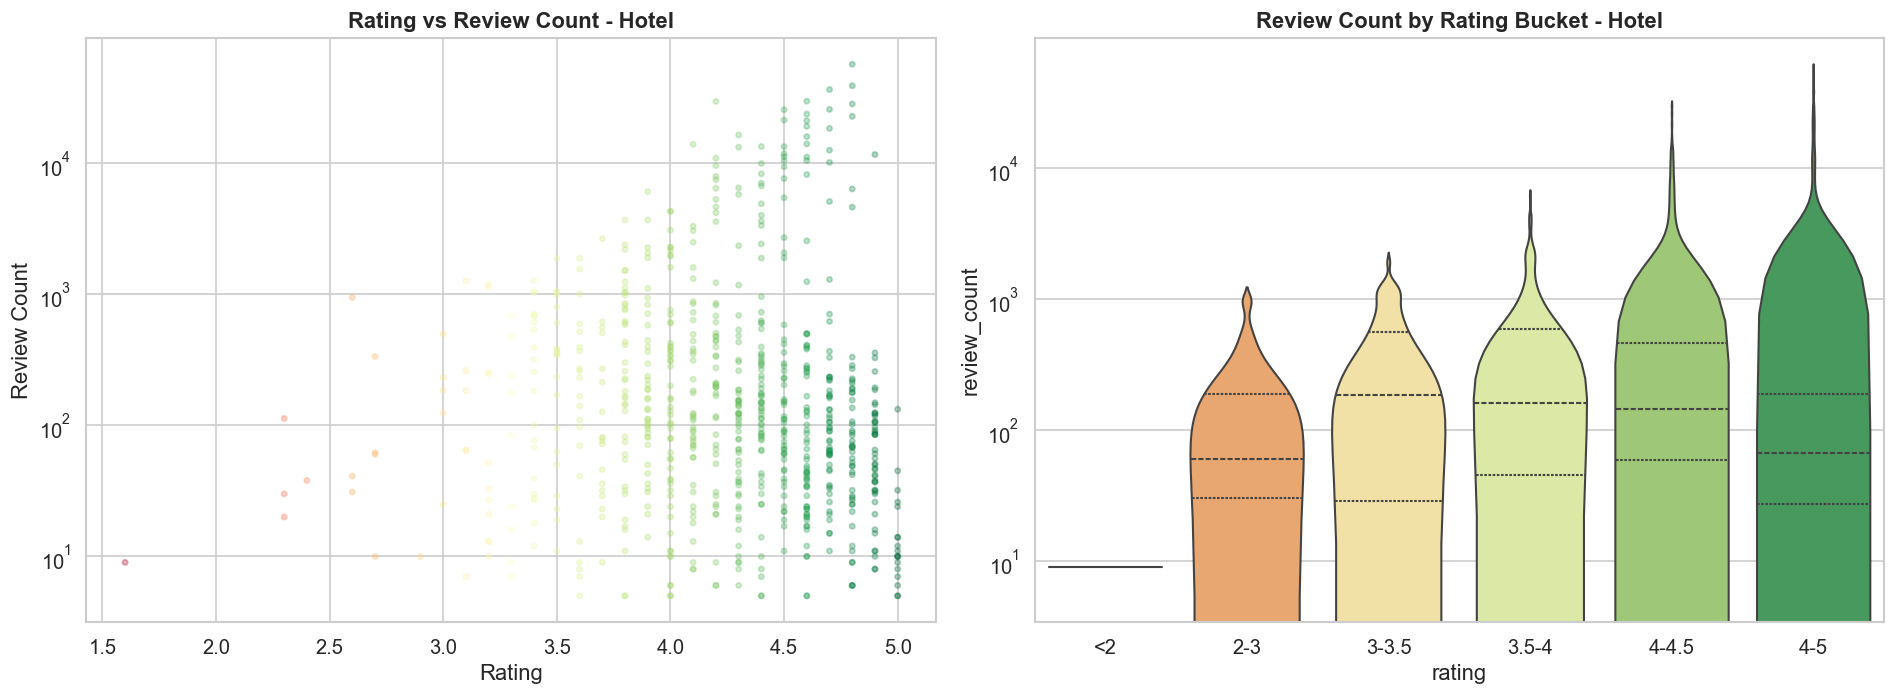


Rating Stats: mean=4.22, median=4.30, std=0.52
Review Stats: mean=1263, median=112, max=57,217

  RATING & REVIEW ANALYSIS: RESTAURANT (4,276 places)

Top 10 Most Reviewed Restaurants:
                                name  rating  review_count                                                                                 address
                         Sobhy Kaber   4.300         79781                            151 Ebeid, As Sahel, Rod El Farag, Cairo Governorate 4350021
                  Koshary Abou Tarek   4.300         42747                                       ١٦ Marouf, Qasr El Nil, Cairo Governorate 4272135
                       Hagouga حجوجة   4.300         29238                       Rocket garden، شارع الصاعقة، طريق السويس, Cairo Governorate 11111
                Abou Haidar Shawerma   4.200         26789 38R9+MF9 el korba, Ibrahim Al Lakani, El-Montaza, Heliopolis, Cairo Governorate 4460204
                              Beggah   4.100         19498             40 Moham

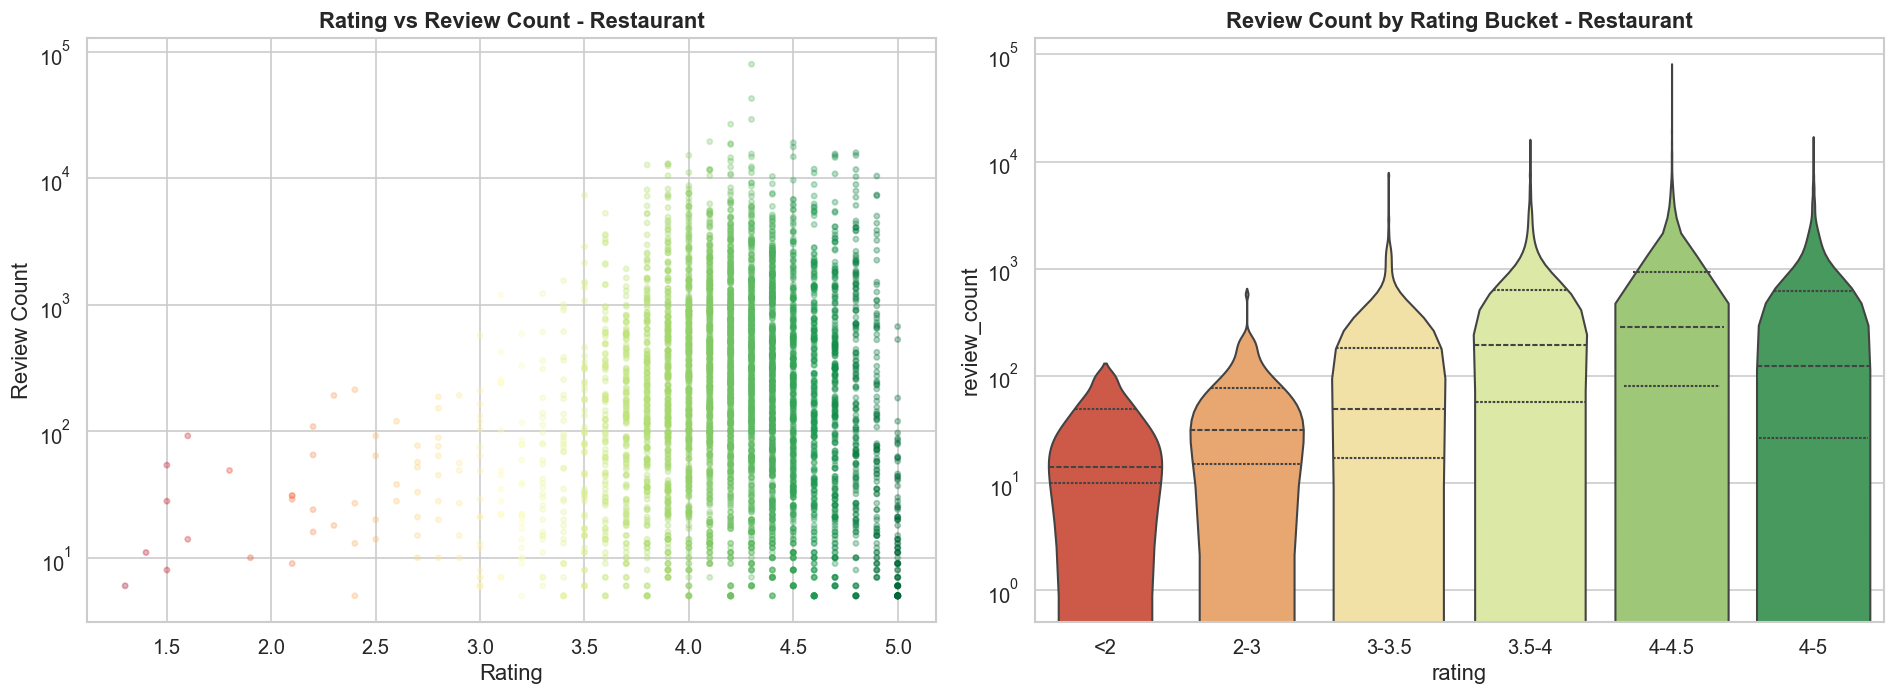


Rating Stats: mean=4.21, median=4.20, std=0.43
Review Stats: mean=834, median=206, max=79,781

  RATING & REVIEW ANALYSIS: ATTRACTIONS (1,509 places)

Top 10 Most Reviewed Attractionss:
                        name  rating  review_count                                                                            address
              Citystars Mall   4.500        142032 2 Omar Ibn El-Khattab, Masaken Al Mohandesin, Nasr City, Cairo Governorate 4451620
    Cairo Festival City Mall   4.600        112140                                    Ring Rd, New Cairo 3, Cairo Governorate 4730020
             Giza Necropolis   4.600        112057                                                 Al Haram, Giza Governorate 3512201
              Mall of Arabia   4.600         77011                                     First 6th of October, Giza Governorate 3236220
             Khan el-Khalili   4.400         74486                                El-Gamaleya, El Gamaliya, Cairo Governorate 4331302
         

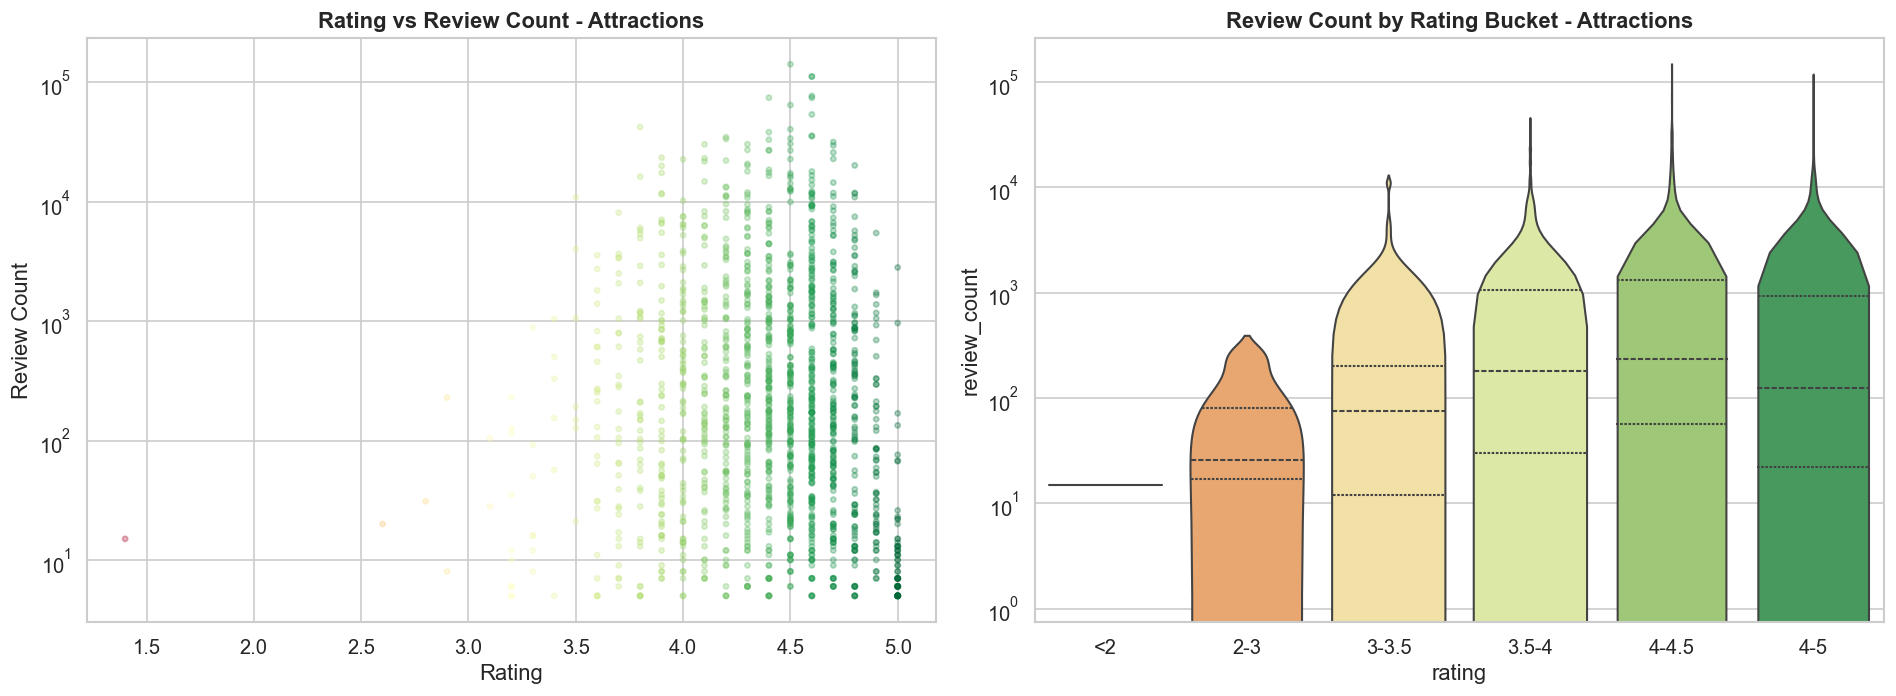


Rating Stats: mean=4.39, median=4.50, std=0.38
Review Stats: mean=2221, median=171, max=142,032


In [18]:
for cat_name, cat_df in categories.items():
    print(f'\n{"="*70}')
    print(f'  RATING & REVIEW ANALYSIS: {cat_name.upper()} ({len(cat_df):,} places)')
    print(f'{"="*70}')

    # Top reviewed
    top_reviewed = cat_df.nlargest(10, 'review_count')[['name', 'rating', 'review_count', 'address']]
    print(f'\nTop 10 Most Reviewed {cat_name.title()}s:')
    print(top_reviewed.to_string(index=False))

    # Rating vs Review Count scatter
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    axes[0].scatter(cat_df['rating'], cat_df['review_count'], alpha=0.3, s=10, c=cat_df['rating'], cmap='RdYlGn')
    axes[0].set_xlabel('Rating')
    axes[0].set_ylabel('Review Count')
    axes[0].set_title(f'Rating vs Review Count - {cat_name.title()}', fontweight='bold')
    axes[0].set_yscale('log')

    rating_bucket = pd.cut(cat_df['rating'], bins=[0, 2, 3, 3.5, 4, 4.5, 5],
                           labels=['<2', '2-3', '3-3.5', '3.5-4', '4-4.5', '4-5'])
    valid_mask = rating_bucket.notna()
    if valid_mask.sum() > 0:
        sns.violinplot(x=rating_bucket[valid_mask], y=cat_df.loc[valid_mask, 'review_count'], ax=axes[1],
                       palette='RdYlGn', inner='quartile')
    axes[1].set_title(f'Review Count by Rating Bucket - {cat_name.title()}', fontweight='bold')
    axes[1].set_yscale('log')

    plt.tight_layout()
    plt.savefig(f'../outputs/figures/{cat_name}_rating_vs_reviews.png', bbox_inches='tight')
    plt.show()

    print(f"\nRating Stats: mean={cat_df['rating'].mean():.2f}, median={cat_df['rating'].median():.2f}, "
          f"std={cat_df['rating'].std():.2f}")
    print(f"Review Stats: mean={cat_df['review_count'].mean():.0f}, median={cat_df['review_count'].median():.0f}, "
          f"max={cat_df['review_count'].max():,}")

# ---
# ## 9. Popularity Analysis (Per Category)


  POPULARITY ANALYSIS: HOTEL (771 places)
Popularity score computed (0-1 scale)
   Mean: 0.601
   Std:  0.120

Top 10 Most Popular Hotels:
                                   name  rating  review_count  popularity_score
InterContinental Cairo Semiramis by IHG   4.800         57217             0.965
          Sofitel Cairo Nile El Gezirah   4.800         39192             0.948
   Holiday Inn Cairo - Citystars by IHG   4.800         28454             0.934
InterContinental Citystars Cairo by IHG   4.700         36682             0.928
    Steigenberger Hotel El Tahrir Cairo   4.800         22889             0.925
        Crowne Plaza West Cairo - Arkan   4.900         11712             0.913
               Fairmont Nile City Hotel   4.700         25857             0.912
                  Novotel Cairo Airport   4.600         29887             0.901
 Four Seasons Hotel Cairo at Nile Plaza   4.700         18516             0.898
                 Kempinski Palace Cairo   4.600         2383

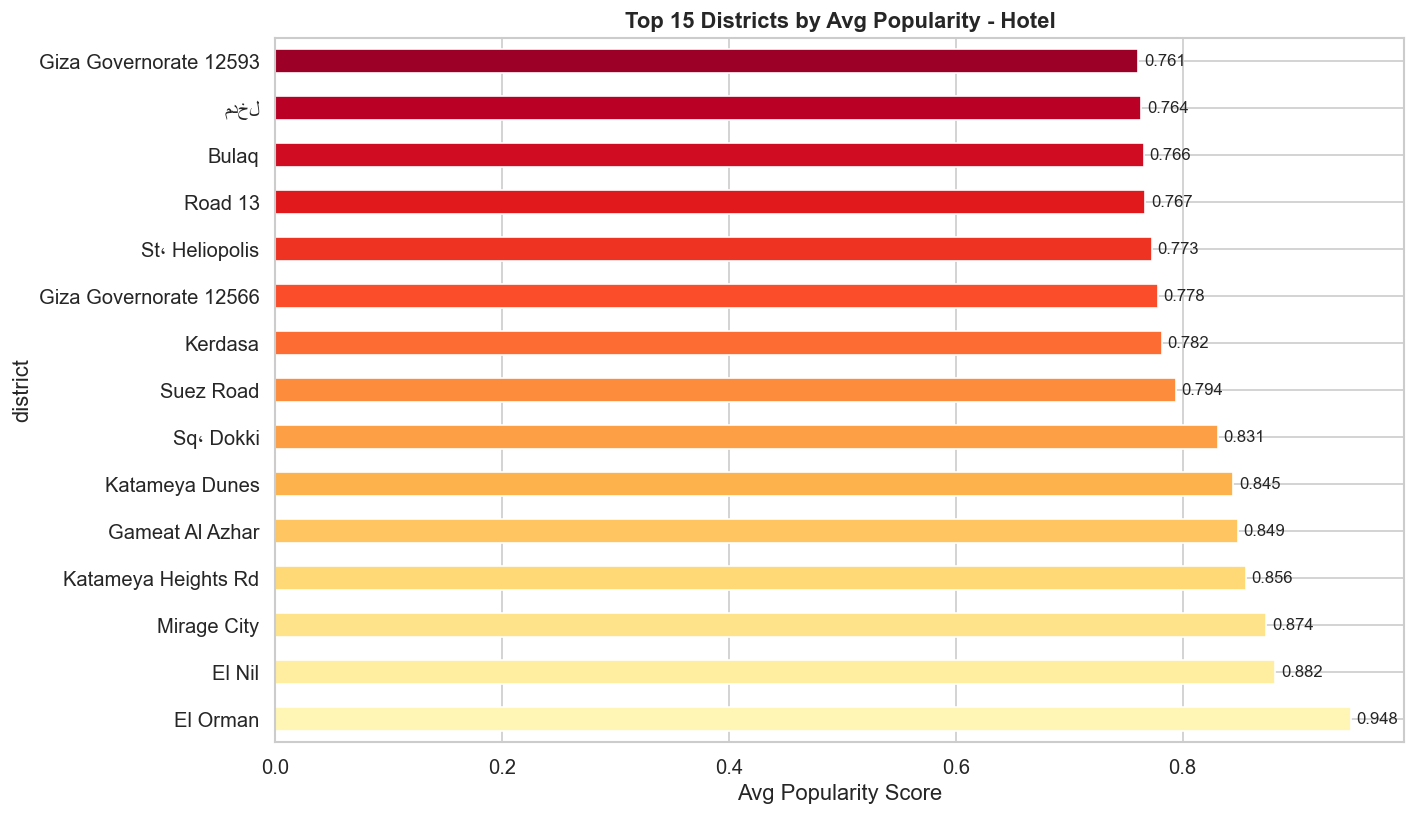


  POPULARITY ANALYSIS: RESTAURANT (4,276 places)
Popularity score computed (0-1 scale)
   Mean: 0.619
   Std:  0.105

Top 10 Most Popular Restaurants:
                                                                    name  rating  review_count  popularity_score
                                                                 il Nilo   4.800         15923             0.900
                                                               Nisantasi   4.900         10421             0.898
                                       Bosporus Open Air Mall (Madinaty)   4.800         15180             0.898
                                            Bosporus Cairo Festival City   4.800         11732             0.887
                                                             Sobhy Kaber   4.300         79781             0.886
                                             Bosporus City Centre Almaza   4.900          7391             0.884
                                                     Nişa

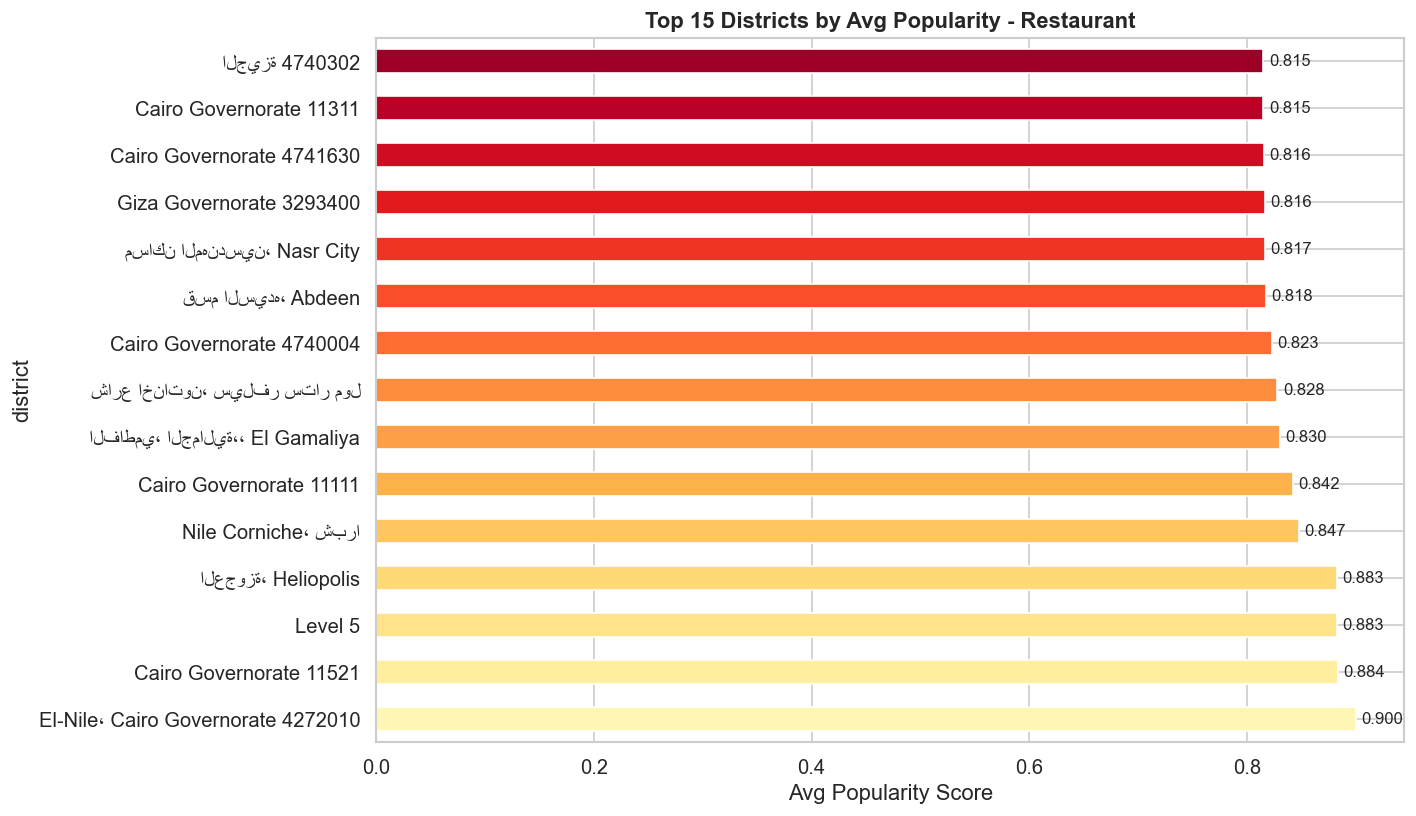


  POPULARITY ANALYSIS: ATTRACTIONS (1,509 places)
Popularity score computed (0-1 scale)
   Mean: 0.639
   Std:  0.106

Top 10 Most Popular Attractionss:
                                        name  rating  review_count  popularity_score
                    Cairo Festival City Mall   4.600        112140             0.924
                             Giza Necropolis   4.600        112057             0.924
                              Citystars Mall   4.500        142032             0.917
                              Mall of Arabia   4.600         77011             0.909
                               Mall of Egypt   4.600         74323             0.908
                          City Centre Almaza   4.600         53922             0.895
                   The Great Pyramid of Giza   4.700         31653             0.890
                             Al-Azhar Mosque   4.800         20177             0.889
The National Museum of Egyptian Civilization   4.700         29657             0.

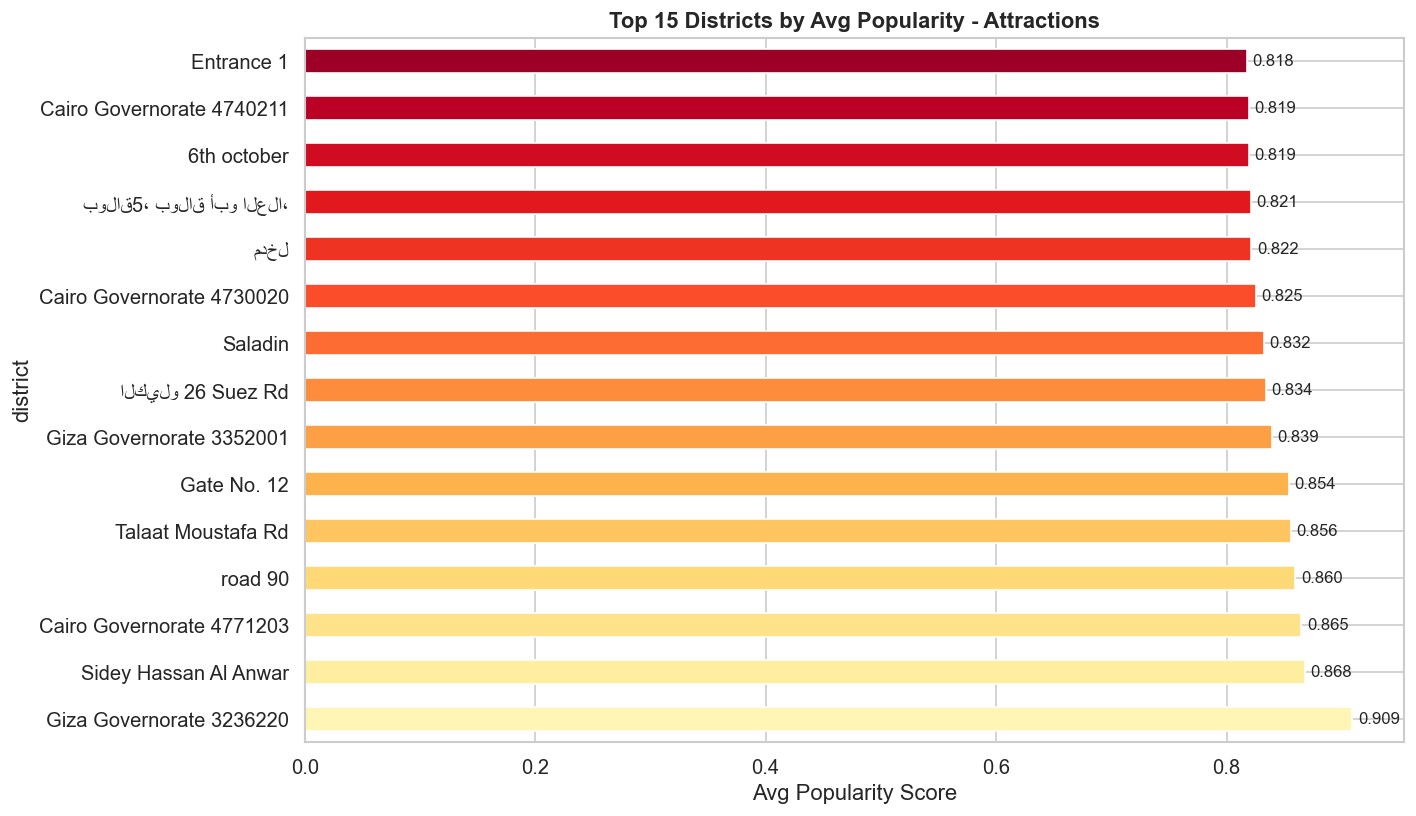

In [19]:
for cat_name, cat_df in categories.items():
    print(f'\n{"="*70}')
    print(f'  POPULARITY ANALYSIS: {cat_name.upper()} ({len(cat_df):,} places)')
    print(f'{"="*70}')

    scaler = MinMaxScaler()

    cat_df['rating_norm'] = scaler.fit_transform(cat_df[['rating']].fillna(cat_df['rating'].median()))
    cat_df['review_norm'] = scaler.fit_transform(
        cat_df[['review_count']].fillna(cat_df['review_count'].median()).apply(np.log1p)
    )
    cat_df['popularity_score'] = (0.6 * cat_df['rating_norm'] + 0.4 * cat_df['review_norm']).round(4)

    print(f"Popularity score computed (0-1 scale)")
    print(f"   Mean: {cat_df['popularity_score'].mean():.3f}")
    print(f"   Std:  {cat_df['popularity_score'].std():.3f}")

    # Top popular
    top_popular = cat_df.nlargest(10, 'popularity_score')[['name', 'rating', 'review_count', 'popularity_score']]
    print(f'\nTop 10 Most Popular {cat_name.title()}s:')
    print(top_popular.to_string(index=False))

    # District popularity
    dist_pop = cat_df.groupby('district').agg(
        avg_popularity=('popularity_score', 'mean'),
        count=('name', 'count'),
        avg_rating=('rating', 'mean')
    ).sort_values('avg_popularity', ascending=False).head(15)

    fig, ax = plt.subplots(figsize=(12, 7))
    dist_pop['avg_popularity'].plot(kind='barh', ax=ax, color=sns.color_palette('YlOrRd', len(dist_pop)))
    ax.set_title(f'Top 15 Districts by Avg Popularity - {cat_name.title()}', fontweight='bold')
    ax.set_xlabel('Avg Popularity Score')
    for i, v in enumerate(dist_pop['avg_popularity'].values):
        ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=10)
    plt.tight_layout()
    plt.savefig(f'../outputs/figures/{cat_name}_district_popularity.png', bbox_inches='tight')
    plt.show()

# ---
# ## 10. Location Intelligence (Per Category)


  LOCATION INTELLIGENCE: HOTEL (771 places)

Significant Areas for Hotels (>=5 places):
                      num_places  avg_rating  total_reviews  avg_popularity
area                                                                       
Al Haram                     140       4.360          57506           0.610
Qasr El Nil                   58       4.130         121593           0.580
Abdeen                        55       4.010           8523           0.550
Nasr City                     34       4.260         123719           0.640
New Cairo 1                   32       4.510          16477           0.620
El Nozha                      22       4.190         110558           0.670
Maadi                         21       4.070          14792           0.580
Dokki                         18       3.960          31983           0.600
First 6th of October          16       4.340          21721           0.640
Heliopolis                    15       3.820          11373           0.520

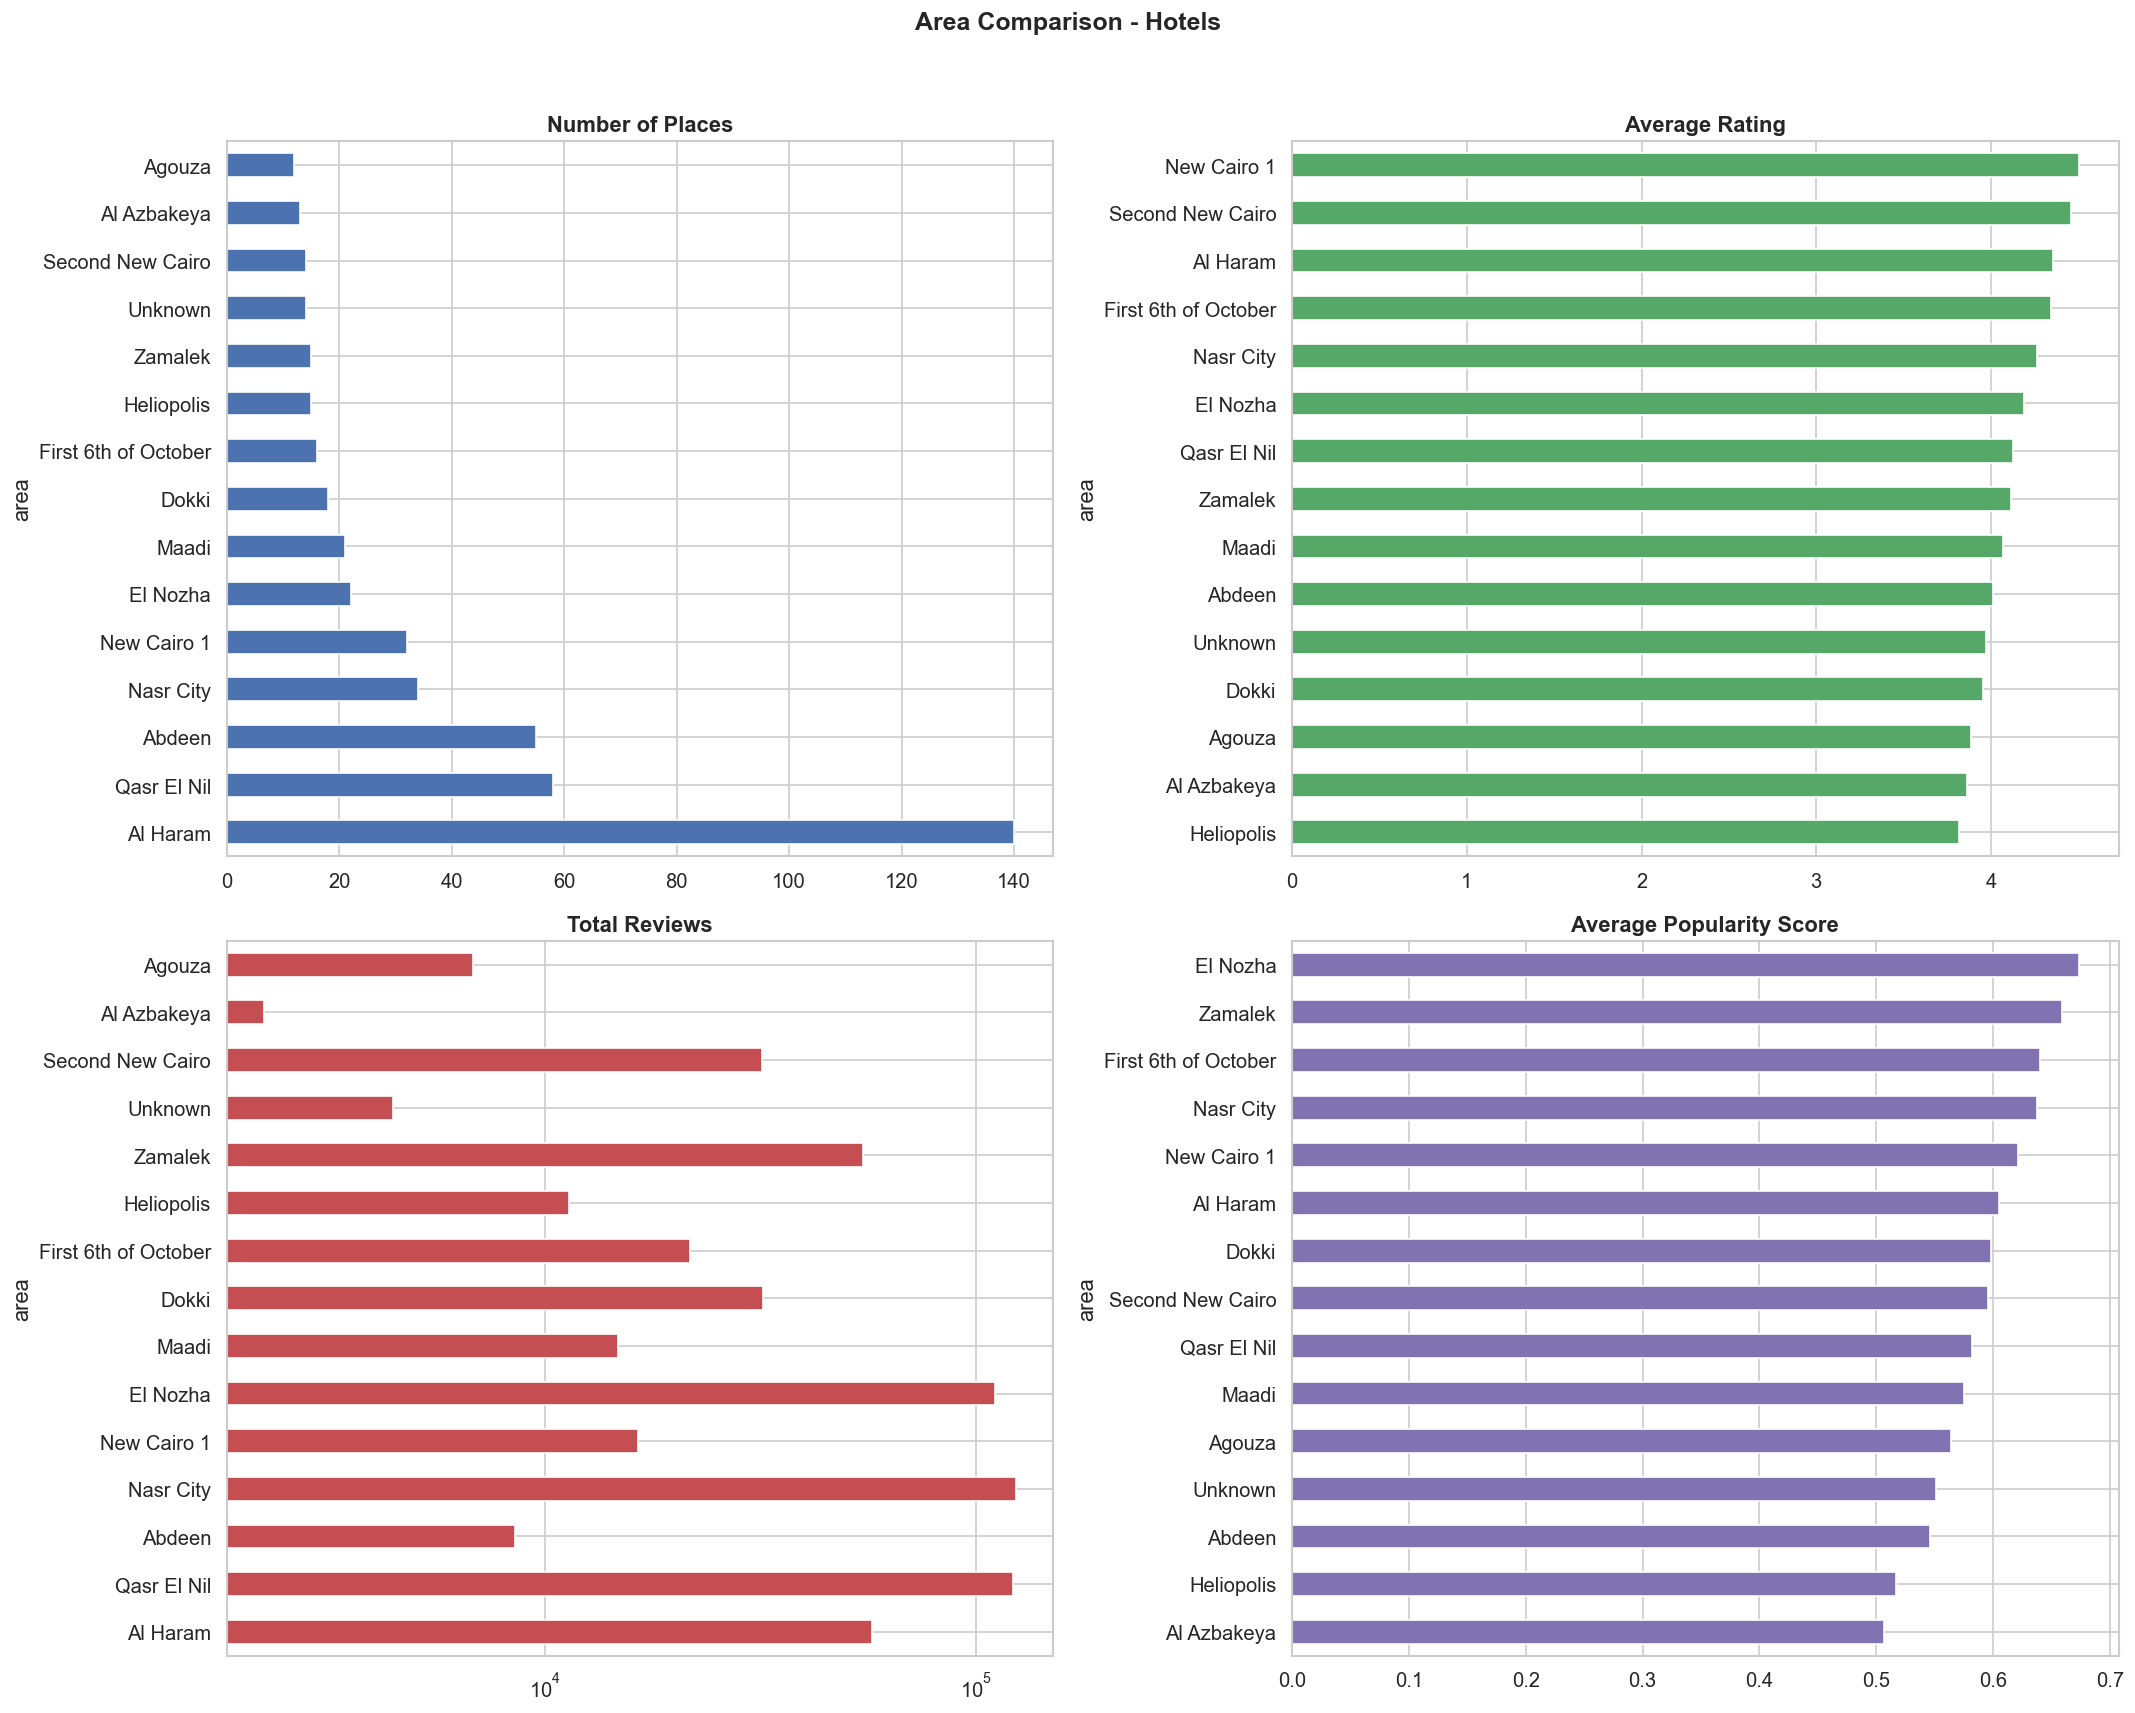


  LOCATION INTELLIGENCE: RESTAURANT (4,276 places)

Significant Areas for Restaurants (>=5 places):
                       num_places  avg_rating  total_reviews  avg_popularity
area                                                                        
Nasr City                     263       4.170         226898           0.620
Maadi                         230       4.180         144724           0.620
Zamalek                       195       4.290         195525           0.660
Second New Cairo              173       4.340         116576           0.640
New Cairo 1                   169       4.210         140638           0.630
Al Haram                      162       4.230          91575           0.630
Heliopolis                    151       4.290         197917           0.670
Dokki                         150       4.250         191113           0.640
Agouza                        104       4.170         136642           0.620
Qasr El Nil                   100       4.210       

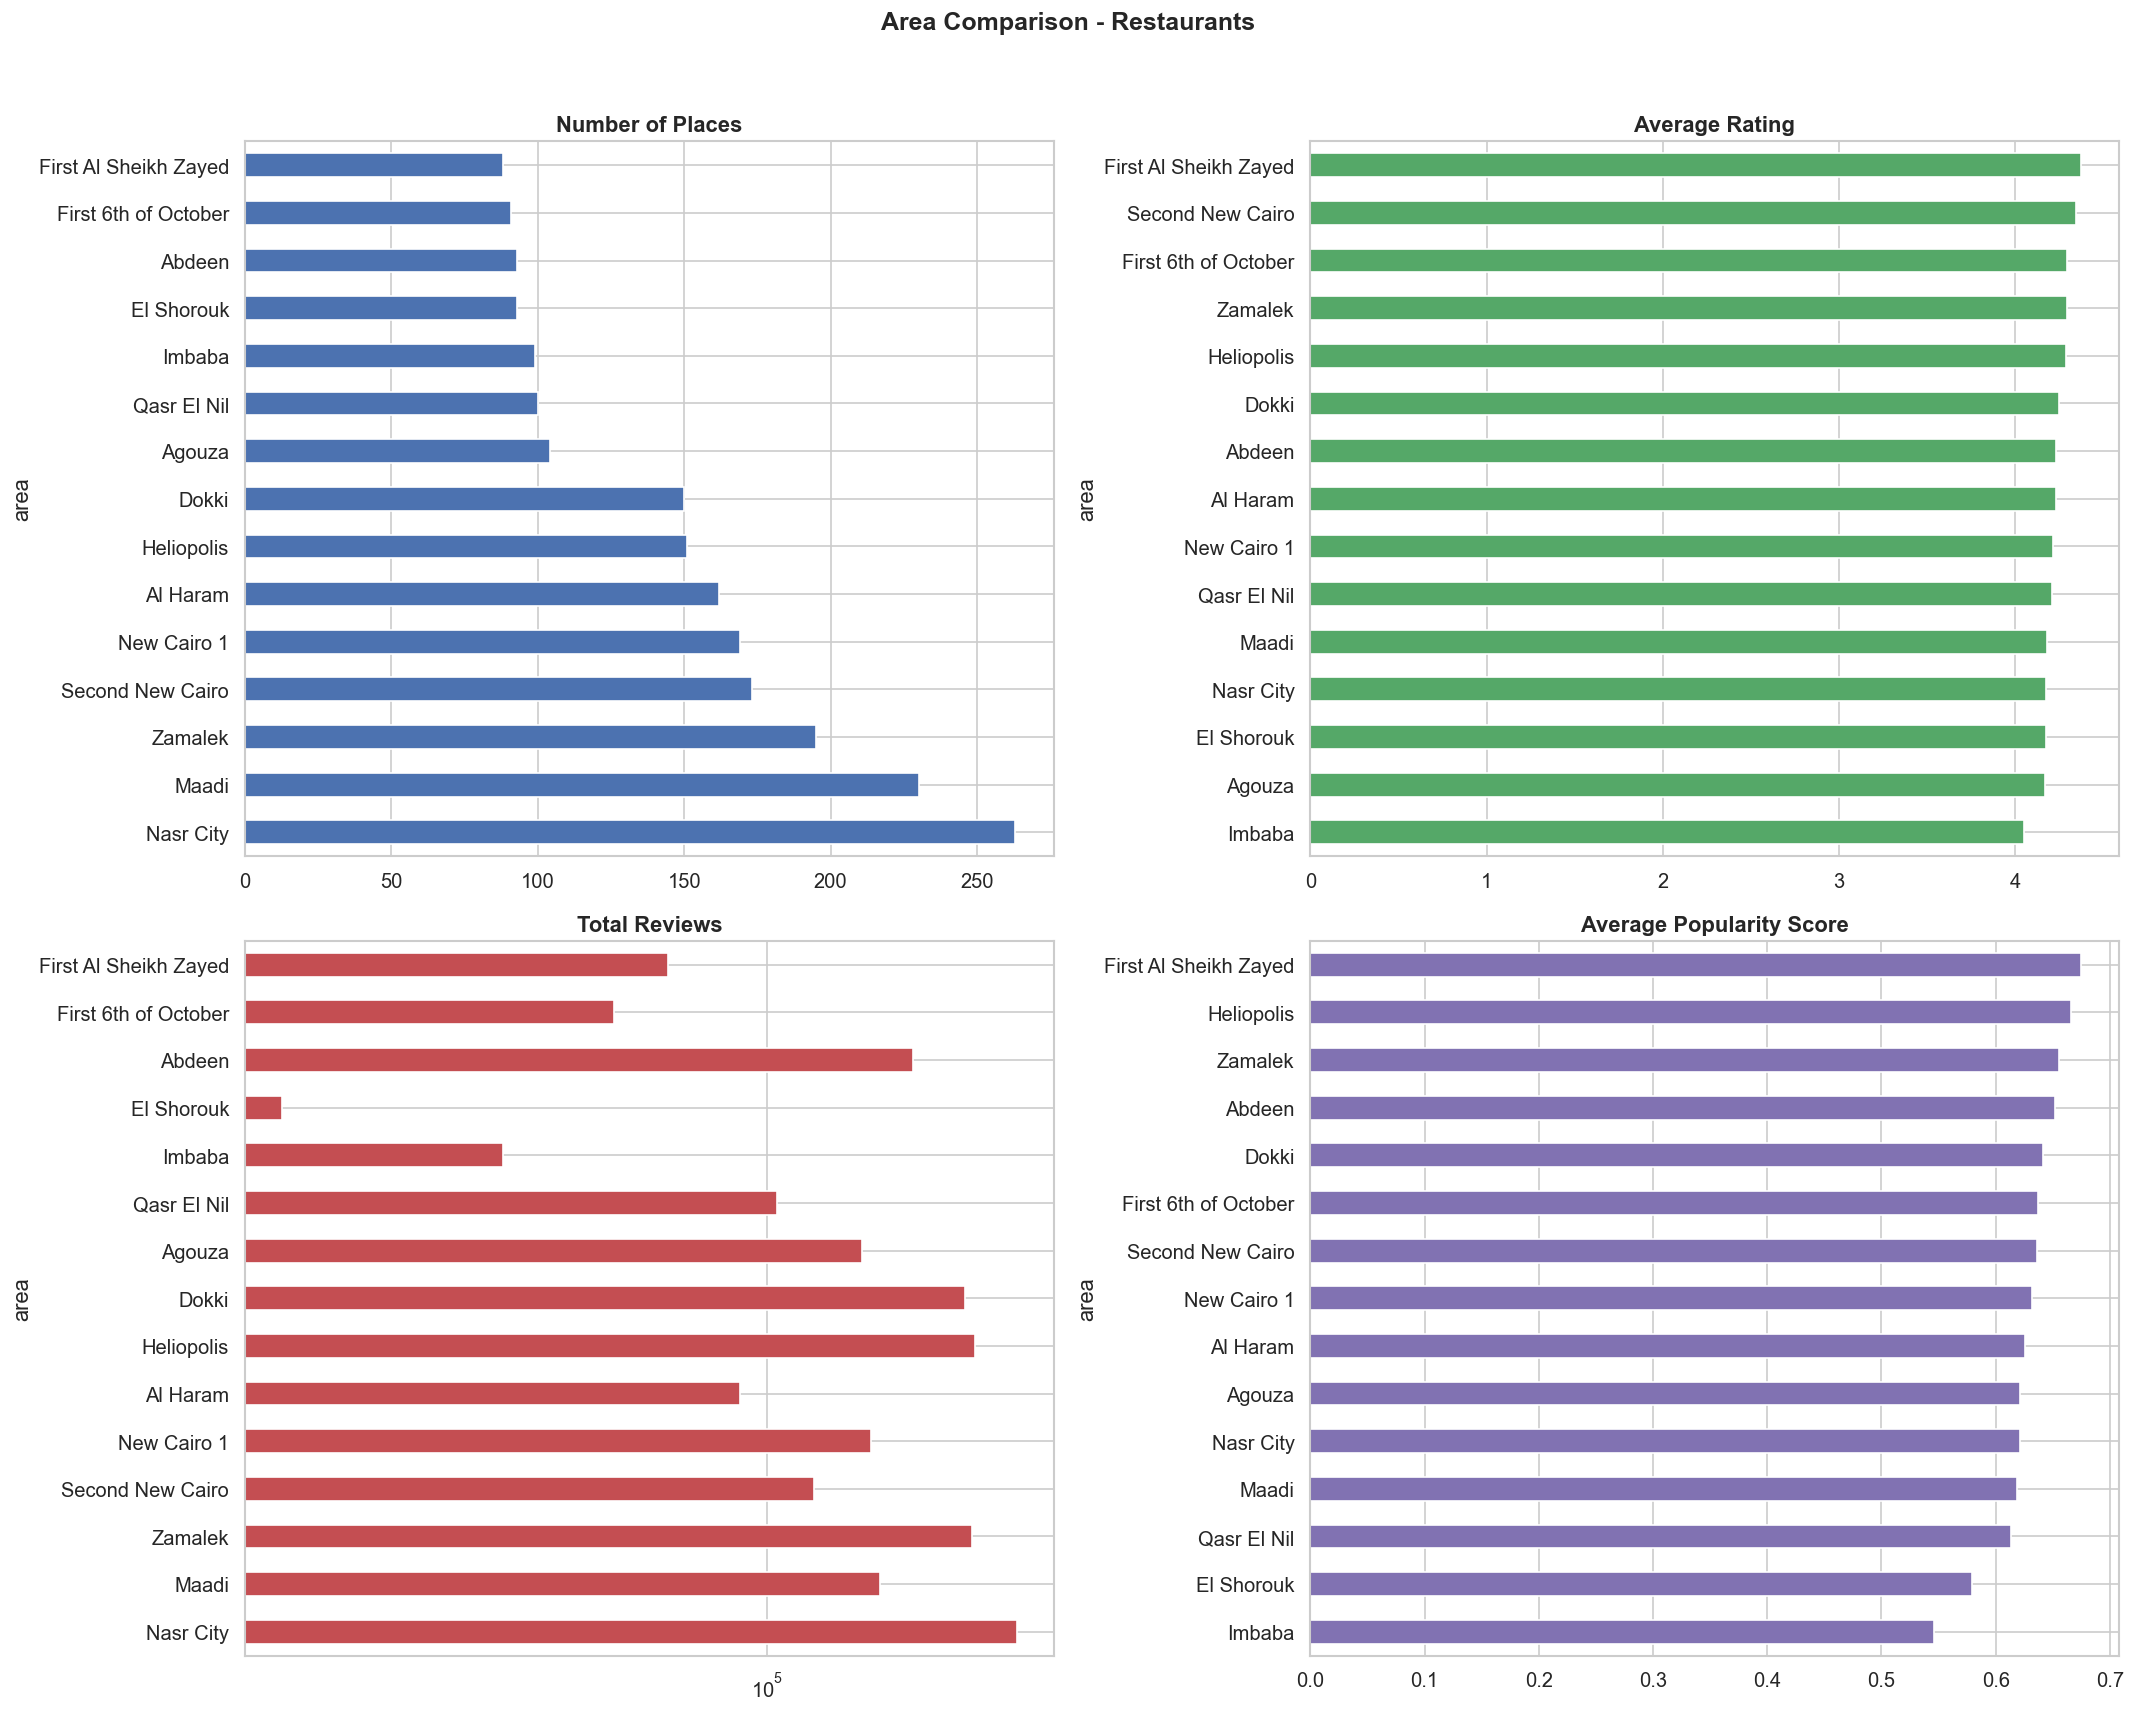


  LOCATION INTELLIGENCE: ATTRACTIONS (1,509 places)

Significant Areas for Attractionss (>=5 places):
                      num_places  avg_rating  total_reviews  avg_popularity
area                                                                       
Zamalek                      103       4.430         137574           0.630
Nasr City                     78       4.370         303415           0.650
New Cairo 1                   72       4.280          83586           0.620
El Gamaliya                   53       4.560         143631           0.650
Al Haram                      53       4.550          71527           0.630
Qasr El Nil                   50       4.390         128366           0.620
First 6th of October          49       4.370         129554           0.640
El Khalifa                    45       4.540         141874           0.680
Second New Cairo              42       4.400          34852           0.620
Heliopolis                    39       4.330          98323  

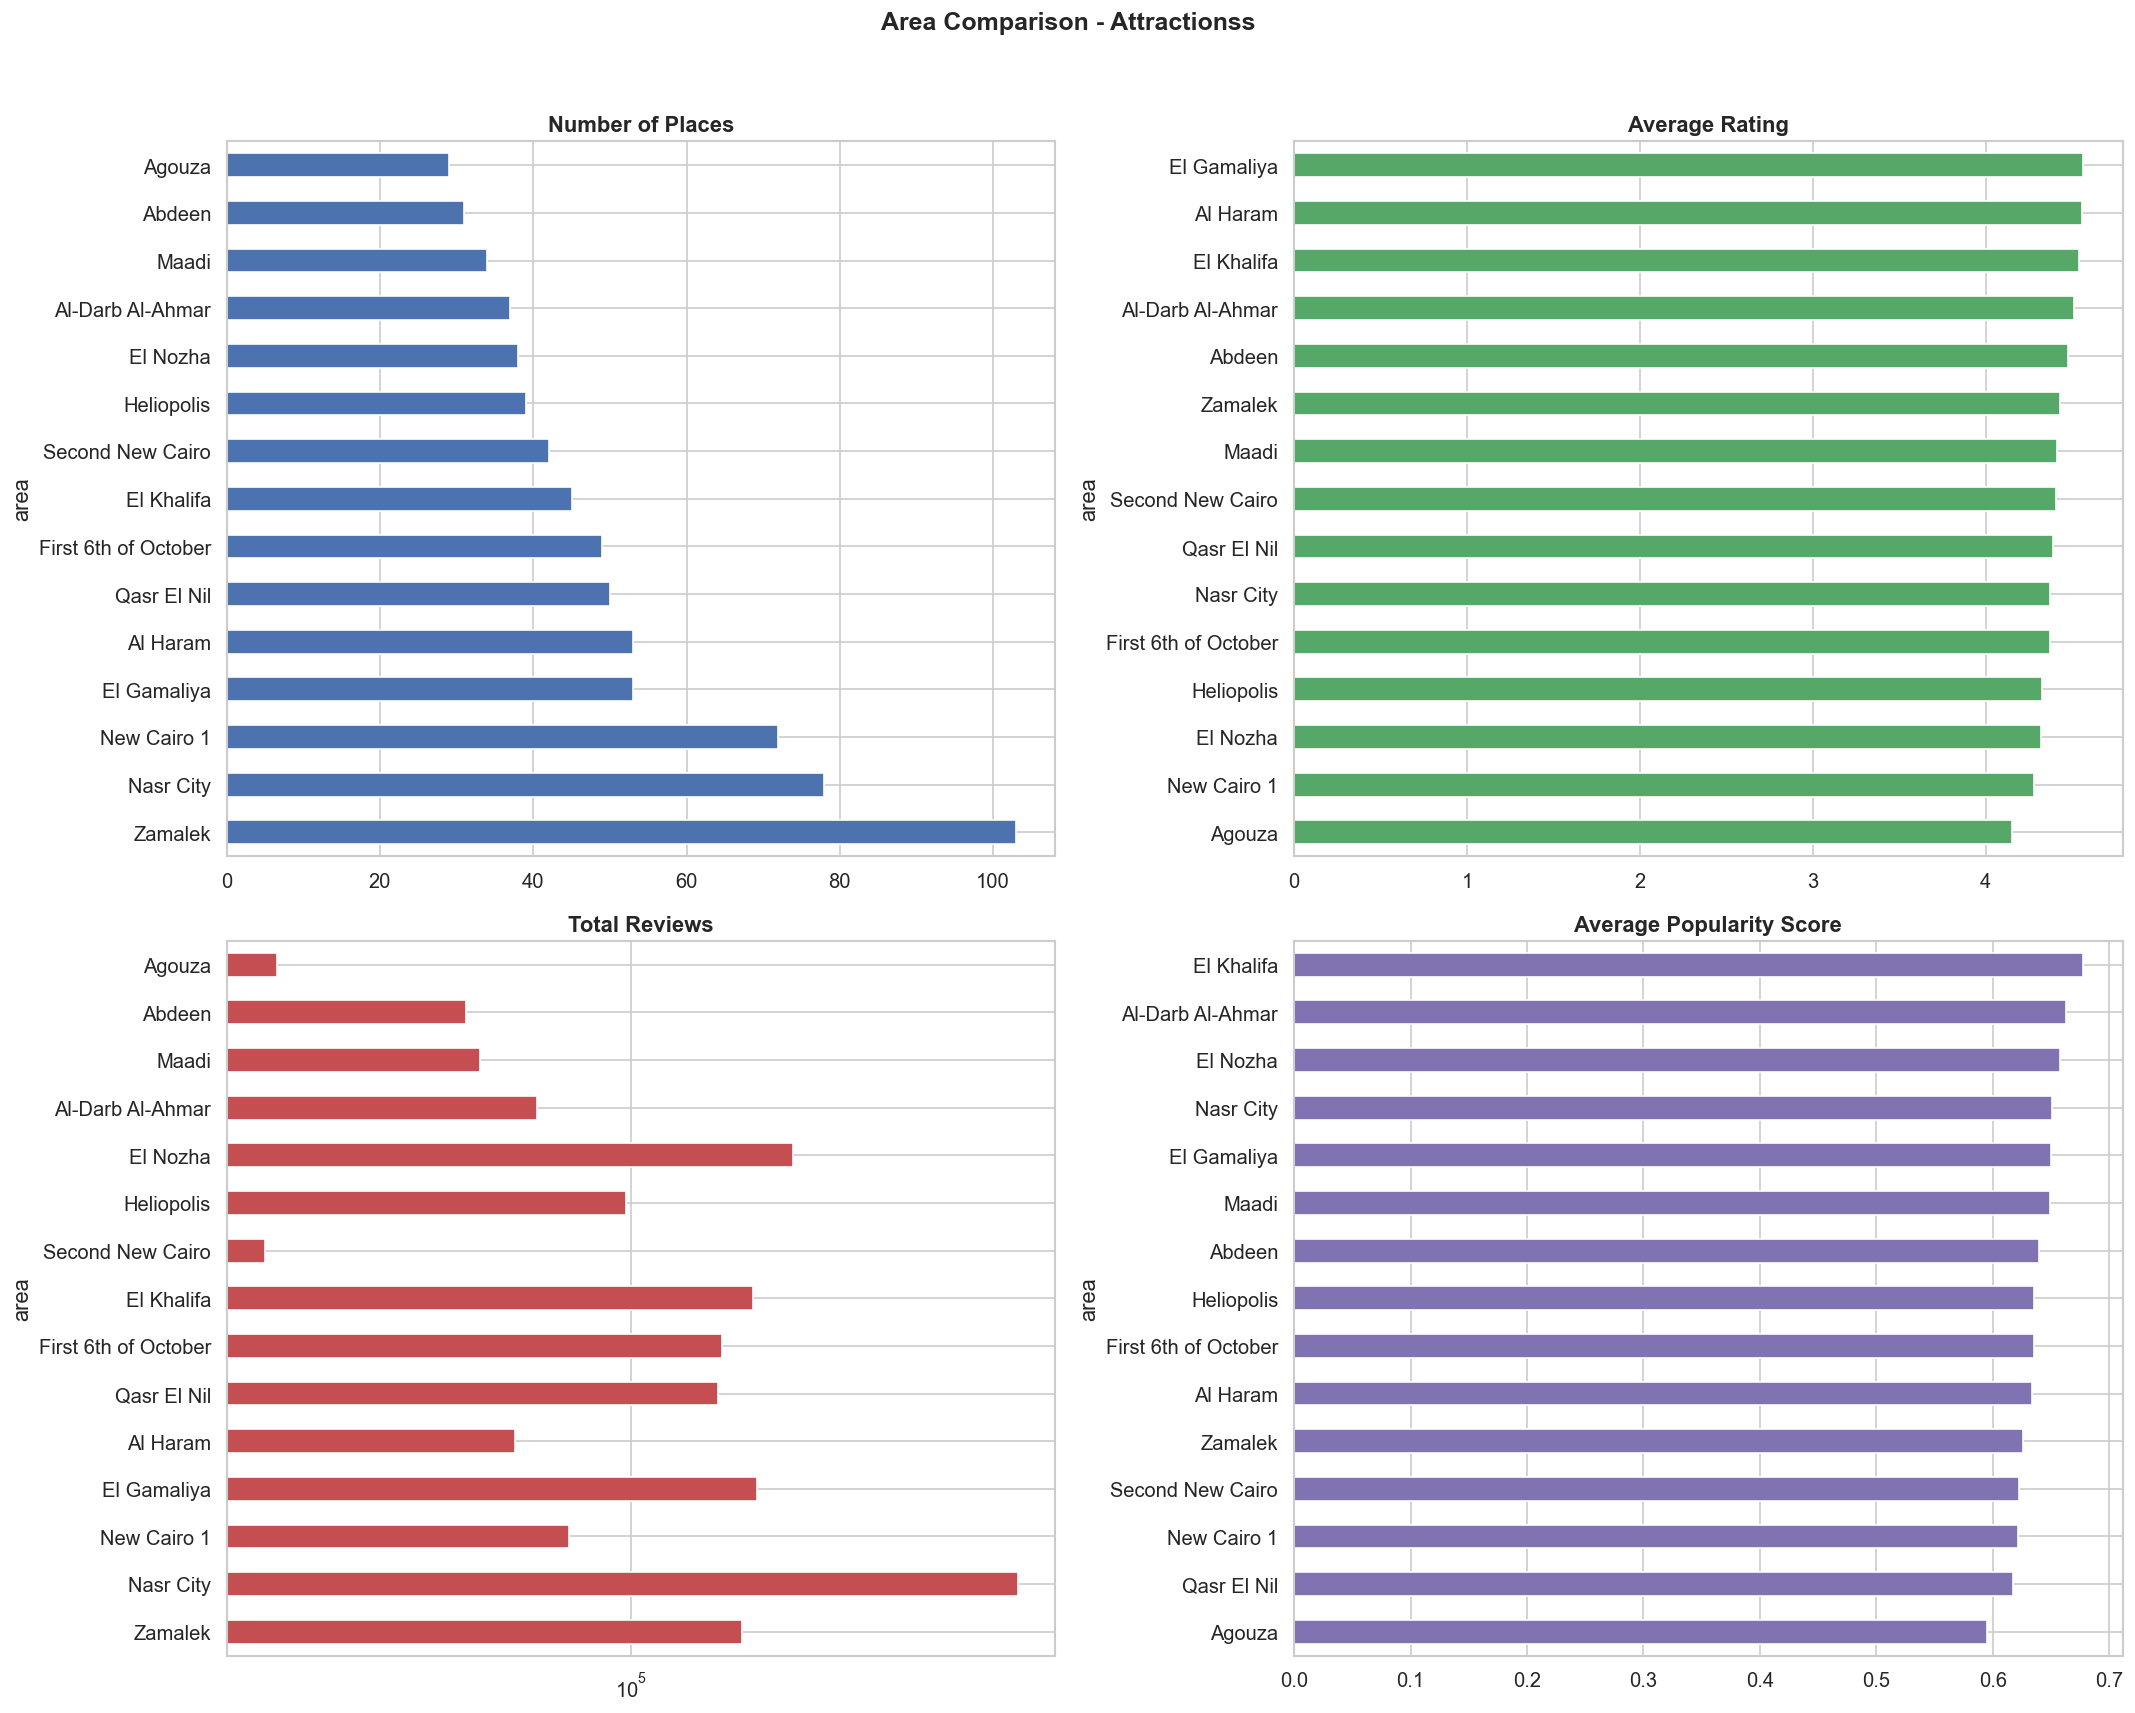

In [20]:
for cat_name, cat_df in categories.items():
    print(f'\n{"="*70}')
    print(f'  LOCATION INTELLIGENCE: {cat_name.upper()} ({len(cat_df):,} places)')
    print(f'{"="*70}')

    scaler = MinMaxScaler()

    area_stats = cat_df.groupby('area').agg(
        num_places=('name', 'count'),
        avg_rating=('rating', 'mean'),
        total_reviews=('review_count', 'sum'),
        avg_popularity=('popularity_score', 'mean')
    ).sort_values('num_places', ascending=False)

    significant_areas = area_stats[area_stats['num_places'] >= 5].head(15)
    print(f'\nSignificant Areas for {cat_name.title()}s (>=5 places):')
    print(significant_areas.round(2).to_string())

    if len(significant_areas) >= 2:
        fig, axes = plt.subplots(2, 2, figsize=(18, 14))

        significant_areas['num_places'].plot(kind='barh', ax=axes[0, 0], color='#4C72B0')
        axes[0, 0].set_title('Number of Places', fontweight='bold')

        significant_areas.sort_values('avg_rating').plot(kind='barh', y='avg_rating', ax=axes[0, 1],
                                                          color='#55A868', legend=False)
        axes[0, 1].set_title('Average Rating', fontweight='bold')

        significant_areas['total_reviews'].plot(kind='barh', ax=axes[1, 0], color='#C44E52')
        axes[1, 0].set_title('Total Reviews', fontweight='bold')
        axes[1, 0].set_xscale('log')

        significant_areas.sort_values('avg_popularity').plot(kind='barh', y='avg_popularity', ax=axes[1, 1],
                                                              color='#8172B2', legend=False)
        axes[1, 1].set_title('Average Popularity Score', fontweight='bold')

        plt.suptitle(f'Area Comparison - {cat_name.title()}s', fontsize=15, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.savefig(f'../outputs/figures/{cat_name}_area_comparison.png', bbox_inches='tight')
        plt.show()

# ---
# ## 11. Correlation Analysis (Per Category)


  CORRELATION ANALYSIS: HOTEL (771 places)


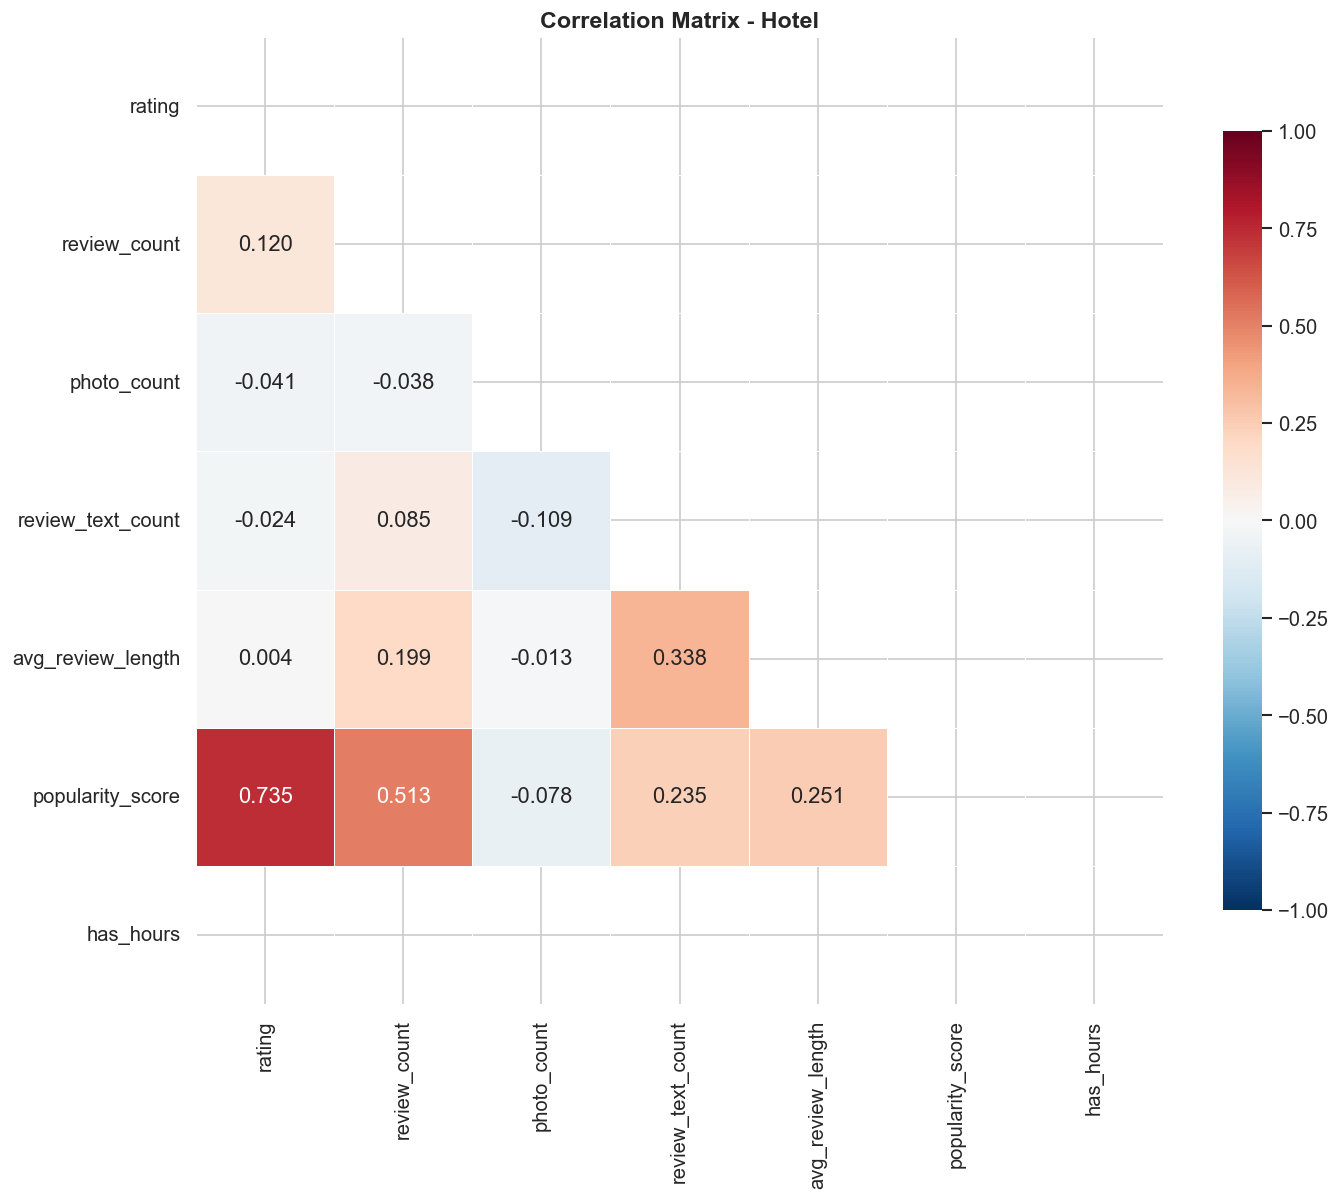

Key Correlations (hotel):
  rating               x review_count        : r = +0.120
  rating               x photo_count         : r = -0.041
  review_count         x photo_count         : r = -0.038

  CORRELATION ANALYSIS: RESTAURANT (4,276 places)


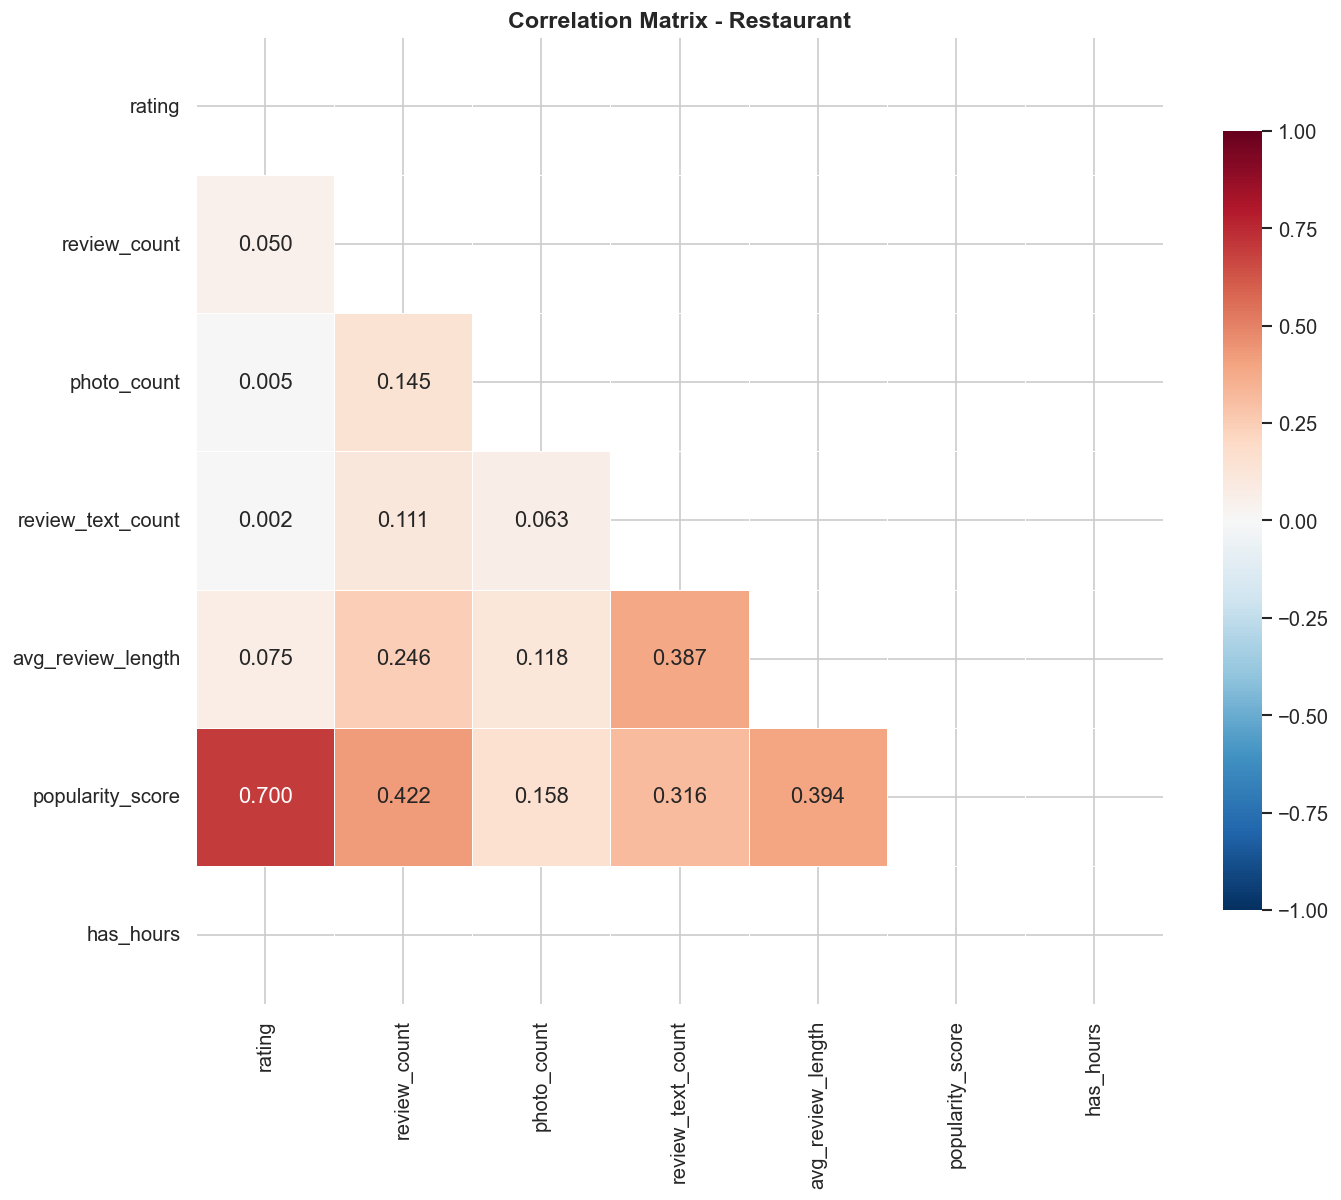

Key Correlations (restaurant):
  rating               x review_count        : r = +0.050
  rating               x photo_count         : r = +0.005
  review_count         x photo_count         : r = +0.145

  CORRELATION ANALYSIS: ATTRACTIONS (1,509 places)


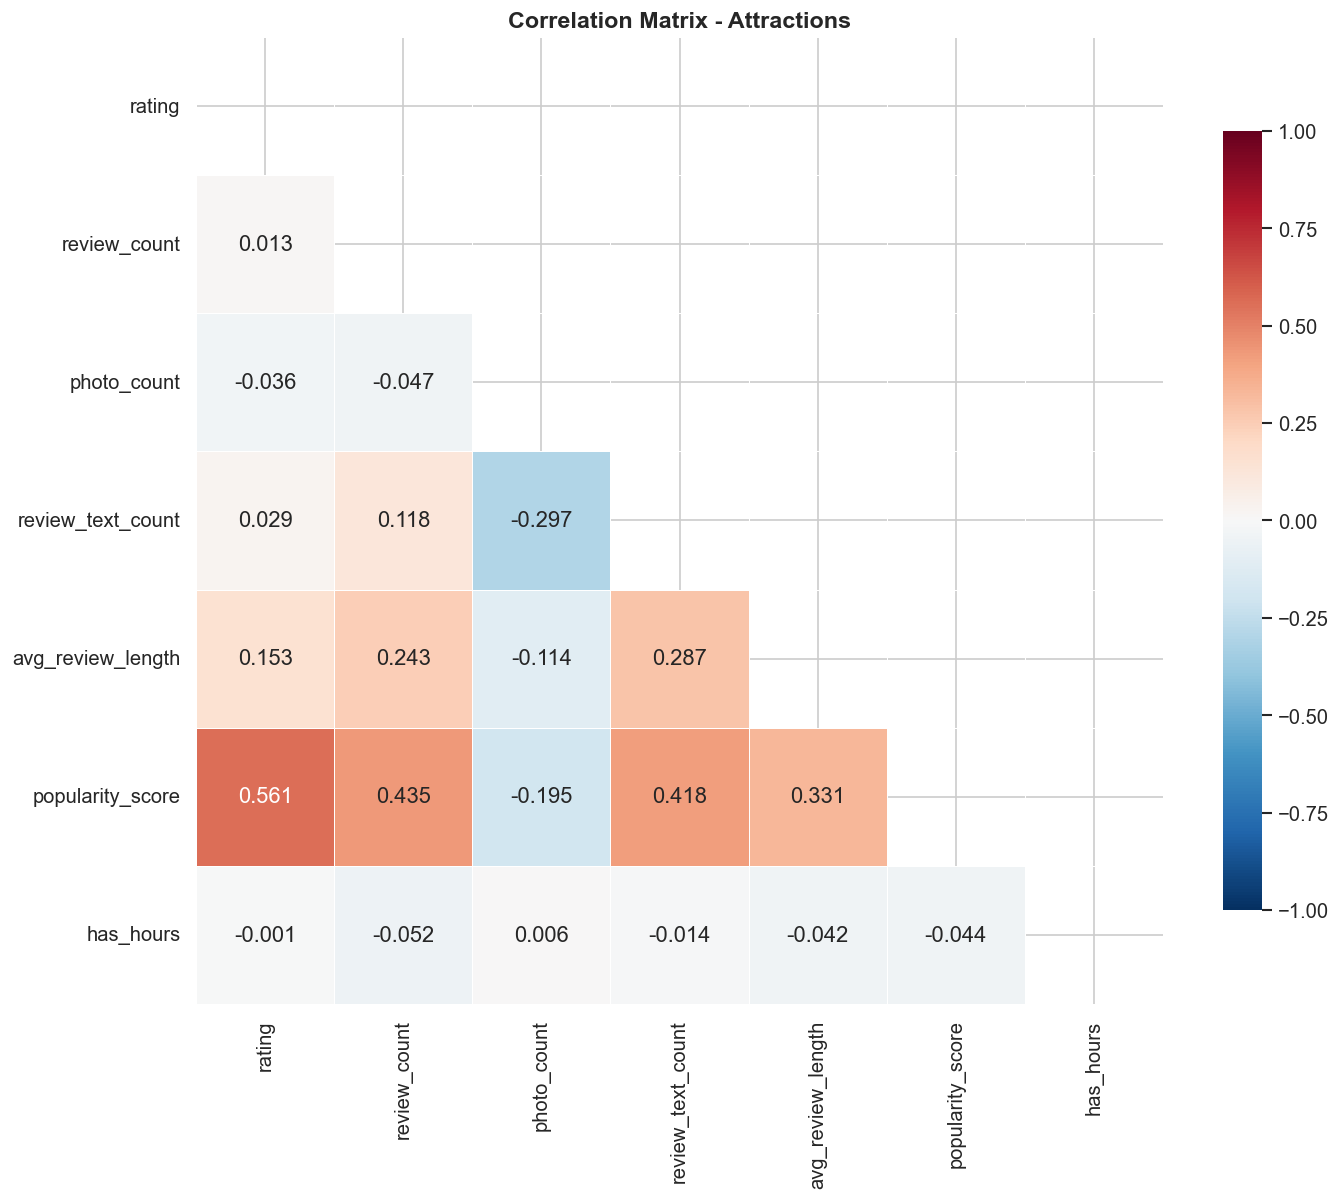

Key Correlations (attractions):
  rating               x review_count        : r = +0.013
  rating               x photo_count         : r = -0.036
  review_count         x photo_count         : r = -0.047


In [21]:
for cat_name, cat_df in categories.items():
    print(f'\n{"="*70}')
    print(f'  CORRELATION ANALYSIS: {cat_name.upper()} ({len(cat_df):,} places)')
    print(f'{"="*70}')

    corr_cols = ['rating', 'review_count', 'photo_count', 'review_text_count',
                 'avg_review_length', 'popularity_score', 'has_hours']
    corr_cols = [c for c in corr_cols if c in cat_df.columns]

    corr_matrix = cat_df[corr_cols].corr()

    fig, ax = plt.subplots(figsize=(12, 10))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r',
                center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5,
                square=True, cbar_kws={'shrink': 0.8})
    ax.set_title(f'Correlation Matrix - {cat_name.title()}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'../outputs/figures/{cat_name}_correlation_heatmap.png', bbox_inches='tight')
    plt.show()

    print(f'Key Correlations ({cat_name}):')
    for pair in [('rating', 'review_count'), ('rating', 'photo_count'), ('review_count', 'photo_count')]:
        if pair[0] in cat_df.columns and pair[1] in cat_df.columns:
            corr = cat_df[pair[0]].corr(cat_df[pair[1]])
            print(f"  {pair[0]:20s} x {pair[1]:20s}: r = {corr:+.3f}")

# ---
# ## 12. Outlier Detection (Per Category)


  OUTLIER DETECTION: HOTEL (771 places)
IQR Outlier Detection (hotel):
  review_count: Q1=36.0, Q3=372.5, IQR=336.5, bounds=[-468.8, 877.2], outliers=114
  rating: Q1=3.9, Q3=4.6, IQR=0.7, bounds=[2.9, 5.6], outliers=12
Z-Score outliers (|z| > 3) in review_count: 16
   Max z-score: 12.46
   Min z-score: -0.28


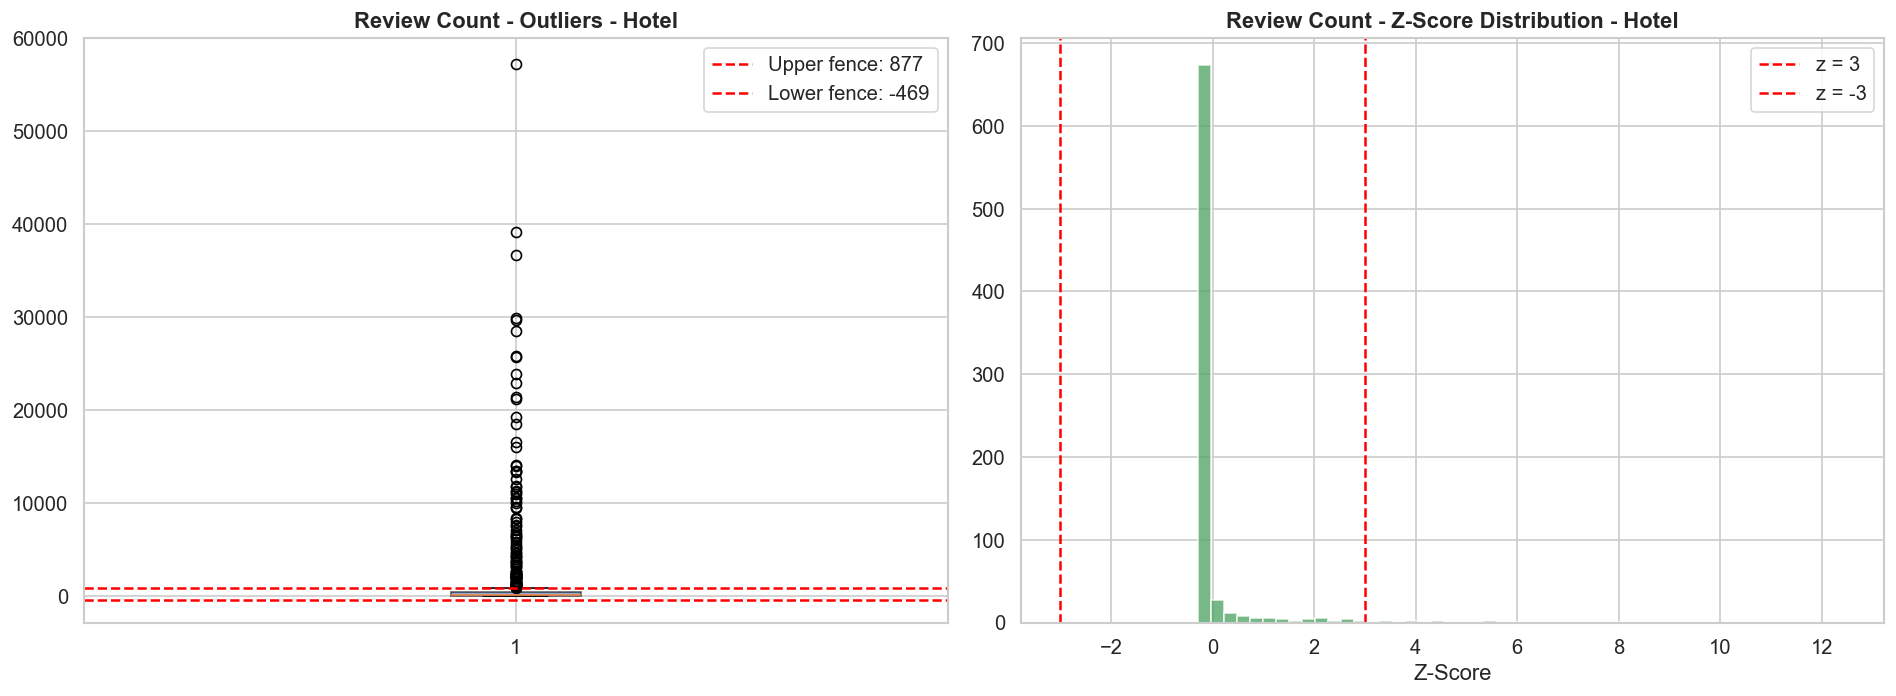


  OUTLIER DETECTION: RESTAURANT (4,276 places)
IQR Outlier Detection (restaurant):
  review_count: Q1=51.0, Q3=737.2, IQR=686.2, bounds=[-978.4, 1766.6], outliers=495
  rating: Q1=4.0, Q3=4.5, IQR=0.5, bounds=[3.2, 5.2], outliers=106
Z-Score outliers (|z| > 3) in review_count: 57
   Max z-score: 34.59
   Min z-score: -0.36


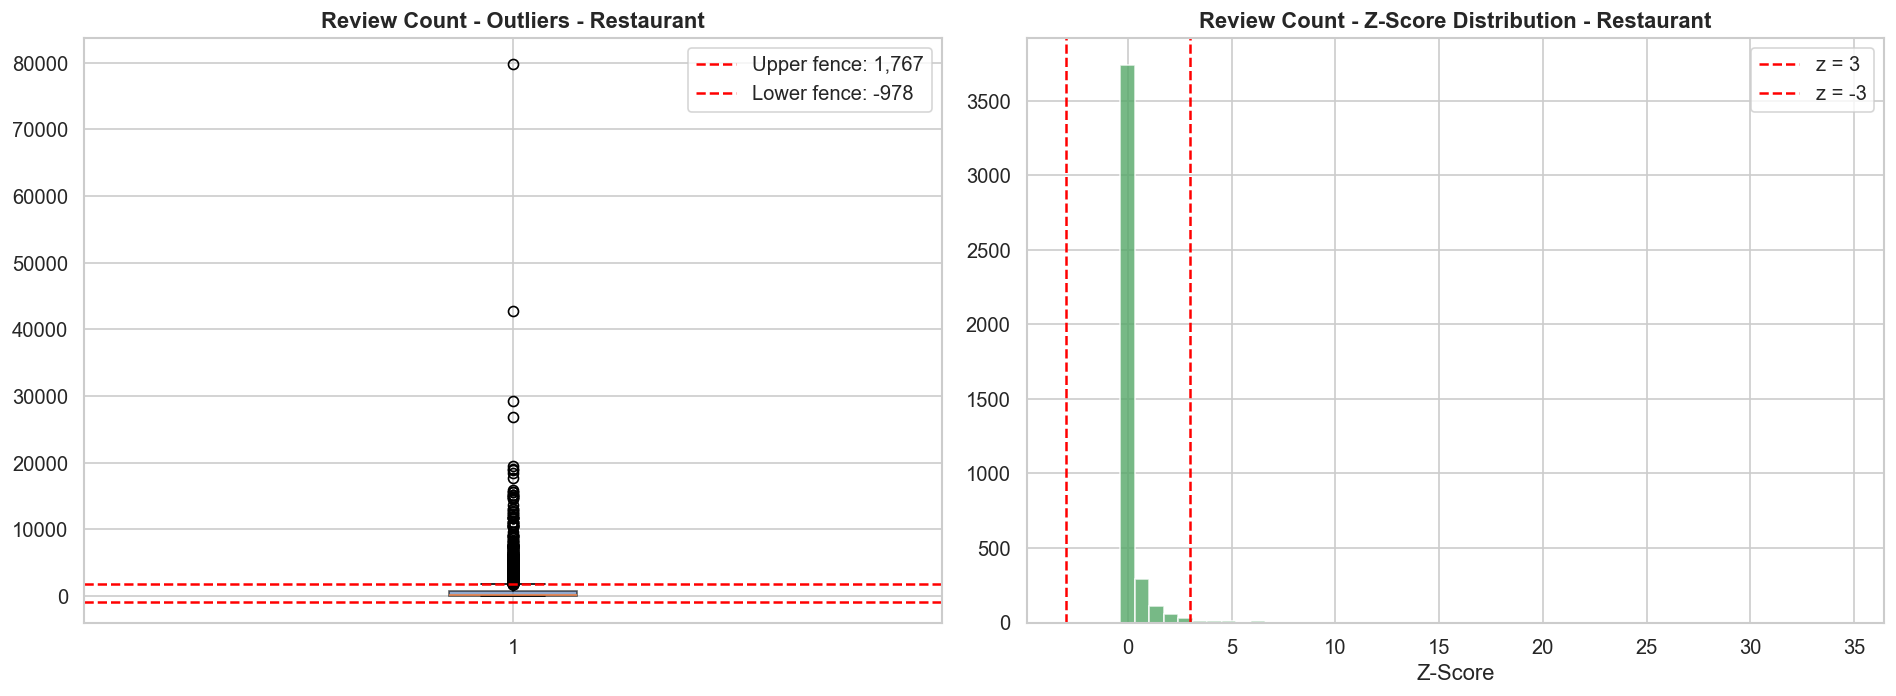


  OUTLIER DETECTION: ATTRACTIONS (1,509 places)
IQR Outlier Detection (attractions):
  review_count: Q1=33.0, Q3=1045.0, IQR=1012.0, bounds=[-1485.0, 2563.0], outliers=232
  rating: Q1=4.2, Q3=4.6, IQR=0.4, bounds=[3.6, 5.2], outliers=61
Z-Score outliers (|z| > 3) in review_count: 26
   Max z-score: 17.13
   Min z-score: -0.27


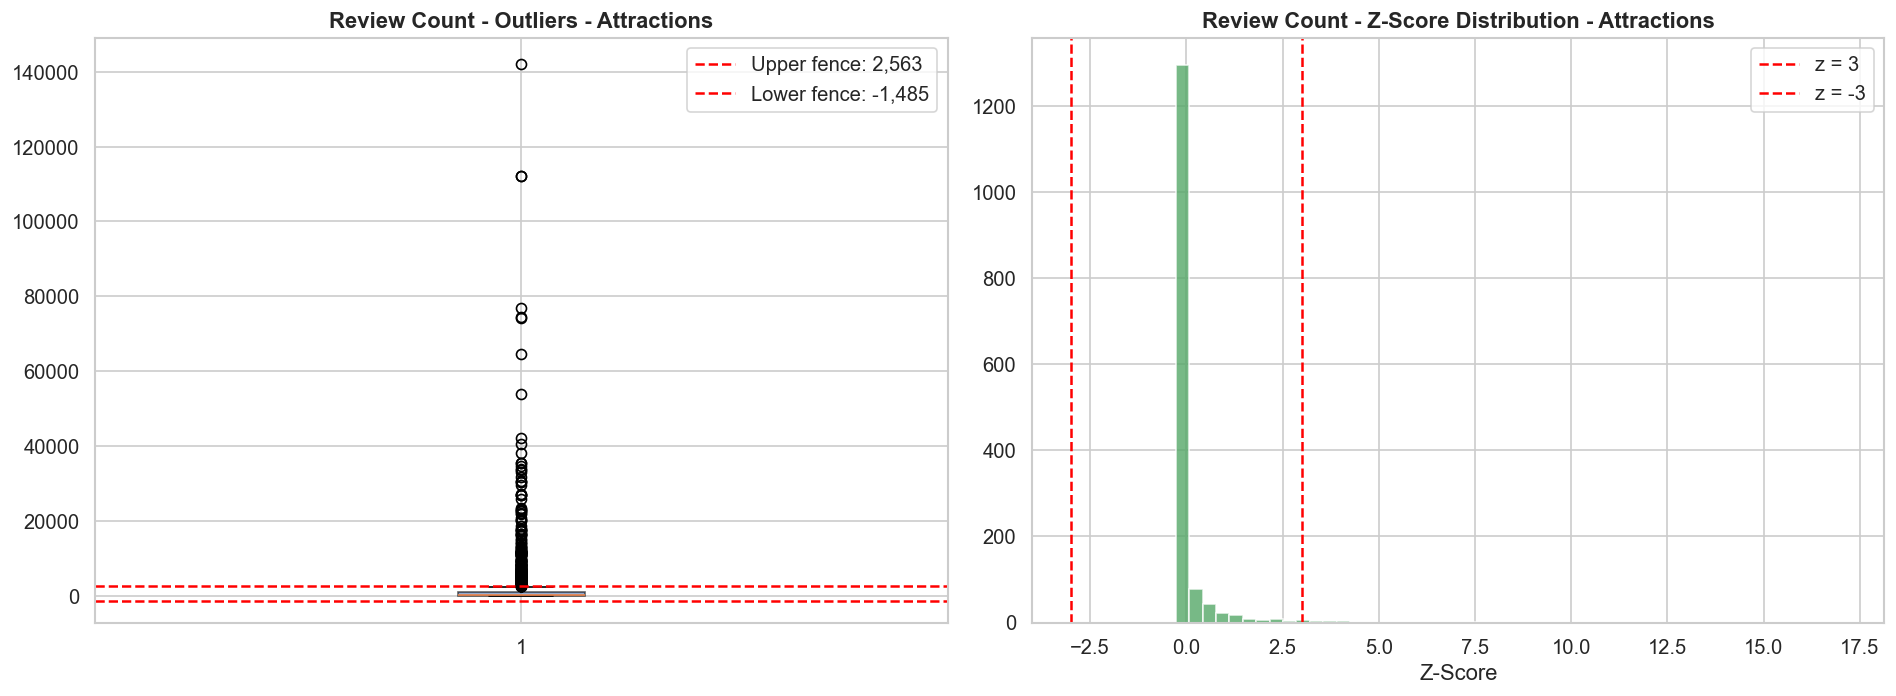

In [22]:
for cat_name, cat_df in categories.items():
    print(f'\n{"="*70}')
    print(f'  OUTLIER DETECTION: {cat_name.upper()} ({len(cat_df):,} places)')
    print(f'{"="*70}')

    def detect_outliers_iqr(series, name):
        Q1 = series.quantile(0.25)
        Q3 = series.quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers = series[(series < lower) | (series > upper)]
        print(f"  {name}: Q1={Q1:.1f}, Q3={Q3:.1f}, IQR={IQR:.1f}, "
              f"bounds=[{lower:.1f}, {upper:.1f}], outliers={len(outliers):,}")
        return outliers

    print(f'IQR Outlier Detection ({cat_name}):')
    detect_outliers_iqr(cat_df['review_count'], 'review_count')
    detect_outliers_iqr(cat_df['rating'], 'rating')

    # Z-score
    cat_df['review_zscore'] = zscore(cat_df['review_count'].fillna(0))
    z_outliers = cat_df[cat_df['review_zscore'].abs() > 3]
    print(f"Z-Score outliers (|z| > 3) in review_count: {len(z_outliers):,}")
    print(f"   Max z-score: {cat_df['review_zscore'].max():.2f}")
    print(f"   Min z-score: {cat_df['review_zscore'].min():.2f}")

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    Q1, Q3 = cat_df['review_count'].quantile(0.25), cat_df['review_count'].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

    axes[0].boxplot(cat_df['review_count'].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='#4C72B0', alpha=0.6))
    axes[0].axhline(upper, color='red', linestyle='--', label=f'Upper fence: {upper:,.0f}')
    axes[0].axhline(lower, color='red', linestyle='--', label=f'Lower fence: {lower:,.0f}')
    axes[0].set_title(f'Review Count - Outliers - {cat_name.title()}', fontweight='bold')
    axes[0].legend()

    axes[1].hist(cat_df['review_zscore'].dropna(), bins=50, color='#55A868', edgecolor='white', alpha=0.8)
    axes[1].axvline(3, color='red', linestyle='--', label='z = 3')
    axes[1].axvline(-3, color='red', linestyle='--', label='z = -3')
    axes[1].set_title(f'Review Count - Z-Score Distribution - {cat_name.title()}', fontweight='bold')
    axes[1].set_xlabel('Z-Score')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(f'../outputs/figures/{cat_name}_outlier_detection.png', bbox_inches='tight')
    plt.show()

    cat_df.drop(columns=['review_zscore'], inplace=True)

# ---
# ## 13. Tourism Insights (Per Category)

In [23]:
for cat_name, cat_df in categories.items():
    print(f'\n{"="*70}')
    print(f'  TOURISM INSIGHTS: {cat_name.upper()} ({len(cat_df):,} places)')
    print(f'{"="*70}')

    print(f'\nRating Distribution ({cat_name}):')
    for rating, count in cat_df['rating'].value_counts().head(5).items():
        print(f"  Rating {rating}: {count:,} places ({count/len(cat_df)*100:.1f}%)")

    print(f'\nHighest-Engagement Districts ({cat_name}):')
    top_areas = cat_df.groupby('district')['review_count'].sum().sort_values(ascending=False).head(5)
    for area, reviews in top_areas.items():
        print(f"  {area}: {reviews:,.0f} total reviews")

    hidden_gems = cat_df[(cat_df['rating'] >= 4.5) & (cat_df['review_count'] < cat_df['review_count'].quantile(0.25))]
    print(f"\nHidden Gems (rating >= 4.5, low reviews): {len(hidden_gems):,} {cat_name}s")
    if len(hidden_gems) > 0:
        print('Top hidden gems:')
        for _, row in hidden_gems.nlargest(5, 'rating').iterrows():
            print(f"  Rating: {row['rating']:.1f} - {row['name']} ({row['review_count']:,} reviews)")

    # Recommendation candidates
    print(f'\nTop Recommendation Candidates ({cat_name}):')
    top_recs = cat_df.nlargest(10, 'rating')[['name', 'rating', 'review_count', 'popularity_score']]
    print(top_recs.to_string(index=False))

# ---
# ## 14. Recommendation-Oriented Features (Per Category)


  TOURISM INSIGHTS: HOTEL (771 places)

Rating Distribution (hotel):
  Rating 4.4: 68 places (8.8%)
  Rating 4.6: 67 places (8.7%)
  Rating 4.3: 57 places (7.4%)
  Rating 4.7: 56 places (7.3%)
  Rating 4.5: 54 places (7.0%)

Highest-Engagement Districts (hotel):
  Nasr City: 123,719 total reviews
  Qasr El Nil: 121,574 total reviews
  El Nozha: 110,558 total reviews
  Bulaq: 67,740 total reviews
  Al Haram: 57,028 total reviews

Hidden Gems (rating >= 4.5, low reviews): 84 hotels
Top hidden gems:
  Rating: 5.0 - Welhome Stays Aparthotel (32 reviews)
  Rating: 5.0 - Alshemy serviced Apartments (26 reviews)
  Rating: 5.0 - Rafiki Hostels - Pyramids (24 reviews)
  Rating: 5.0 - Space Hostel (14 reviews)
  Rating: 5.0 - M Residence (14 reviews)

Top Recommendation Candidates (hotel):
                       name  rating  review_count  popularity_score
 ONE GATE Pyramids View INN   5.000           133             0.736
         Eyad Pyramids View   5.000            45             0.689
   W

In [24]:
for cat_name, cat_df in categories.items():
    print(f'\n{"="*70}')
    print(f'  RECOMMENDATION SCORES: {cat_name.upper()} ({len(cat_df):,} places)')
    print(f'{"="*70}')

    if 'rating_norm' not in cat_df.columns:
        scaler = MinMaxScaler()
        cat_df['rating_norm'] = scaler.fit_transform(cat_df[['rating']].fillna(cat_df['rating'].median()))
        cat_df['review_norm'] = scaler.fit_transform(
            cat_df[['review_count']].fillna(cat_df['review_count'].median()).apply(np.log1p)
        )

    # Family-friendly
    cat_df['family_friendly_score'] = (
        0.5 * cat_df['rating_norm'] + 0.5 * cat_df['review_norm']
    ).round(4)

    # Budget-friendly
    cat_df['budget_score'] = (1.0 - cat_df['rating_norm'] * 0.3 + cat_df['review_norm'] * 0.2).clip(0, 1).round(4)

    # Luxury
    cat_df['luxury_score'] = (
        0.7 * cat_df['rating_norm'] + 0.3 * (1 - cat_df['review_norm'])
    ).clip(0, 1).round(4)

    score_cols = ['family_friendly_score', 'budget_score', 'luxury_score']
    print(f'\nRecommendation Feature Scores ({cat_name}):')
    print(cat_df[score_cols].describe().round(3).to_string())

    # Top recommendations by profile
    print(f'\nTop 5 Recommendations by Profile ({cat_name}):')
    profiles = {
        'Family Trip': 'family_friendly_score',
        'Budget Traveler': 'budget_score',
        'Luxury Seeker': 'luxury_score',
    }
    for profile, score_col in profiles.items():
        top = cat_df.nlargest(5, score_col)[['name', 'rating', 'review_count', score_col]]
        print(f"\n  {profile}:")
        for _, row in top.iterrows():
            print(f"    Rating: {row['rating']:.1f} | {row['name'][:45]:45s} | score={row[score_col]:.3f}")

# ---
# ## 15. Interactive Dashboard Elements (Per Category)
#
# > **Note:** Interactive charts are saved as `.html` files in `outputs/figures/`. Open them in a browser for full interactivity.


  RECOMMENDATION SCORES: HOTEL (771 places)

Recommendation Feature Scores (hotel):
       family_friendly_score  budget_score  luxury_score
count                771.000       771.000       771.000
mean                   0.558         0.838         0.736
std                    0.125         0.062         0.125
min                    0.028         0.700         0.283
25%                    0.496         0.789         0.648
50%                    0.558         0.833         0.743
75%                    0.622         0.885         0.835
max                    0.971         1.000         1.000

Top 5 Recommendations by Profile (hotel):

  Family Trip:
    Rating: 4.8 | InterContinental Cairo Semiramis by IHG       | score=0.971
    Rating: 4.8 | Sofitel Cairo Nile El Gezirah                 | score=0.950
    Rating: 4.8 | Holiday Inn Cairo - Citystars by IHG          | score=0.932
    Rating: 4.7 | InterContinental Citystars Cairo by IHG       | score=0.932
    Rating: 4.8 | Steigenberger

In [25]:
for cat_name, cat_df in categories.items():
    print(f'\n{"="*70}')
    print(f'  INTERACTIVE DASHBOARD: {cat_name.upper()} ({len(cat_df):,} places)')
    print(f'{"="*70}')

    # Rating distribution box plot
    fig = px.box(
        cat_df, y='rating',
        title=f'{cat_name.title()} - Rating Distribution (Interactive)',
        hover_data=['name', 'review_count'], height=500
    )
    fig.write_html(f'../outputs/figures/{cat_name}_interactive_rating_boxplot.html')

    # Scatter by subtype
    if 'subtype' in cat_df.columns and cat_df['subtype'].notna().sum() > 0:
        fig = px.scatter(
            cat_df.sample(min(2000, len(cat_df)), random_state=42),
            x='subtype', y='rating', color='district',
            size='review_count', size_max=20, hover_name='name',
            hover_data={'subtype': True, 'rating': True, 'review_count': True, 'district': True},
            title=f'{cat_name.title()} - Subtype x Rating x District', height=600,
        )
        fig.update_layout(xaxis_tickangle=-45)
        fig.write_html(f'../outputs/figures/{cat_name}_interactive_subtype_rating.html')
        print(f'Subtype scatter saved: {cat_name}_interactive_subtype_rating.html')

    print(f'Dashboard saved for {cat_name}')

# ---
# ## 16. Cross-Category Comparison (Summary)


  INTERACTIVE DASHBOARD: HOTEL (771 places)
Subtype scatter saved: hotel_interactive_subtype_rating.html
Dashboard saved for hotel

  INTERACTIVE DASHBOARD: RESTAURANT (4,276 places)
Subtype scatter saved: restaurant_interactive_subtype_rating.html
Dashboard saved for restaurant

  INTERACTIVE DASHBOARD: ATTRACTIONS (1,509 places)
Subtype scatter saved: attractions_interactive_subtype_rating.html
Dashboard saved for attractions



  CROSS-CATEGORY COMPARISON

Category Comparison Summary:
   category  count  avg_rating  median_rating  std_rating  avg_reviews  total_reviews  unique_districts
      hotel    771       4.220          4.300       0.520     1262.920         973714               217
 restaurant   4276       4.210          4.200       0.430      834.100        3566630               754
attractions   1509       4.390          4.500       0.380     2220.690        3351027               325


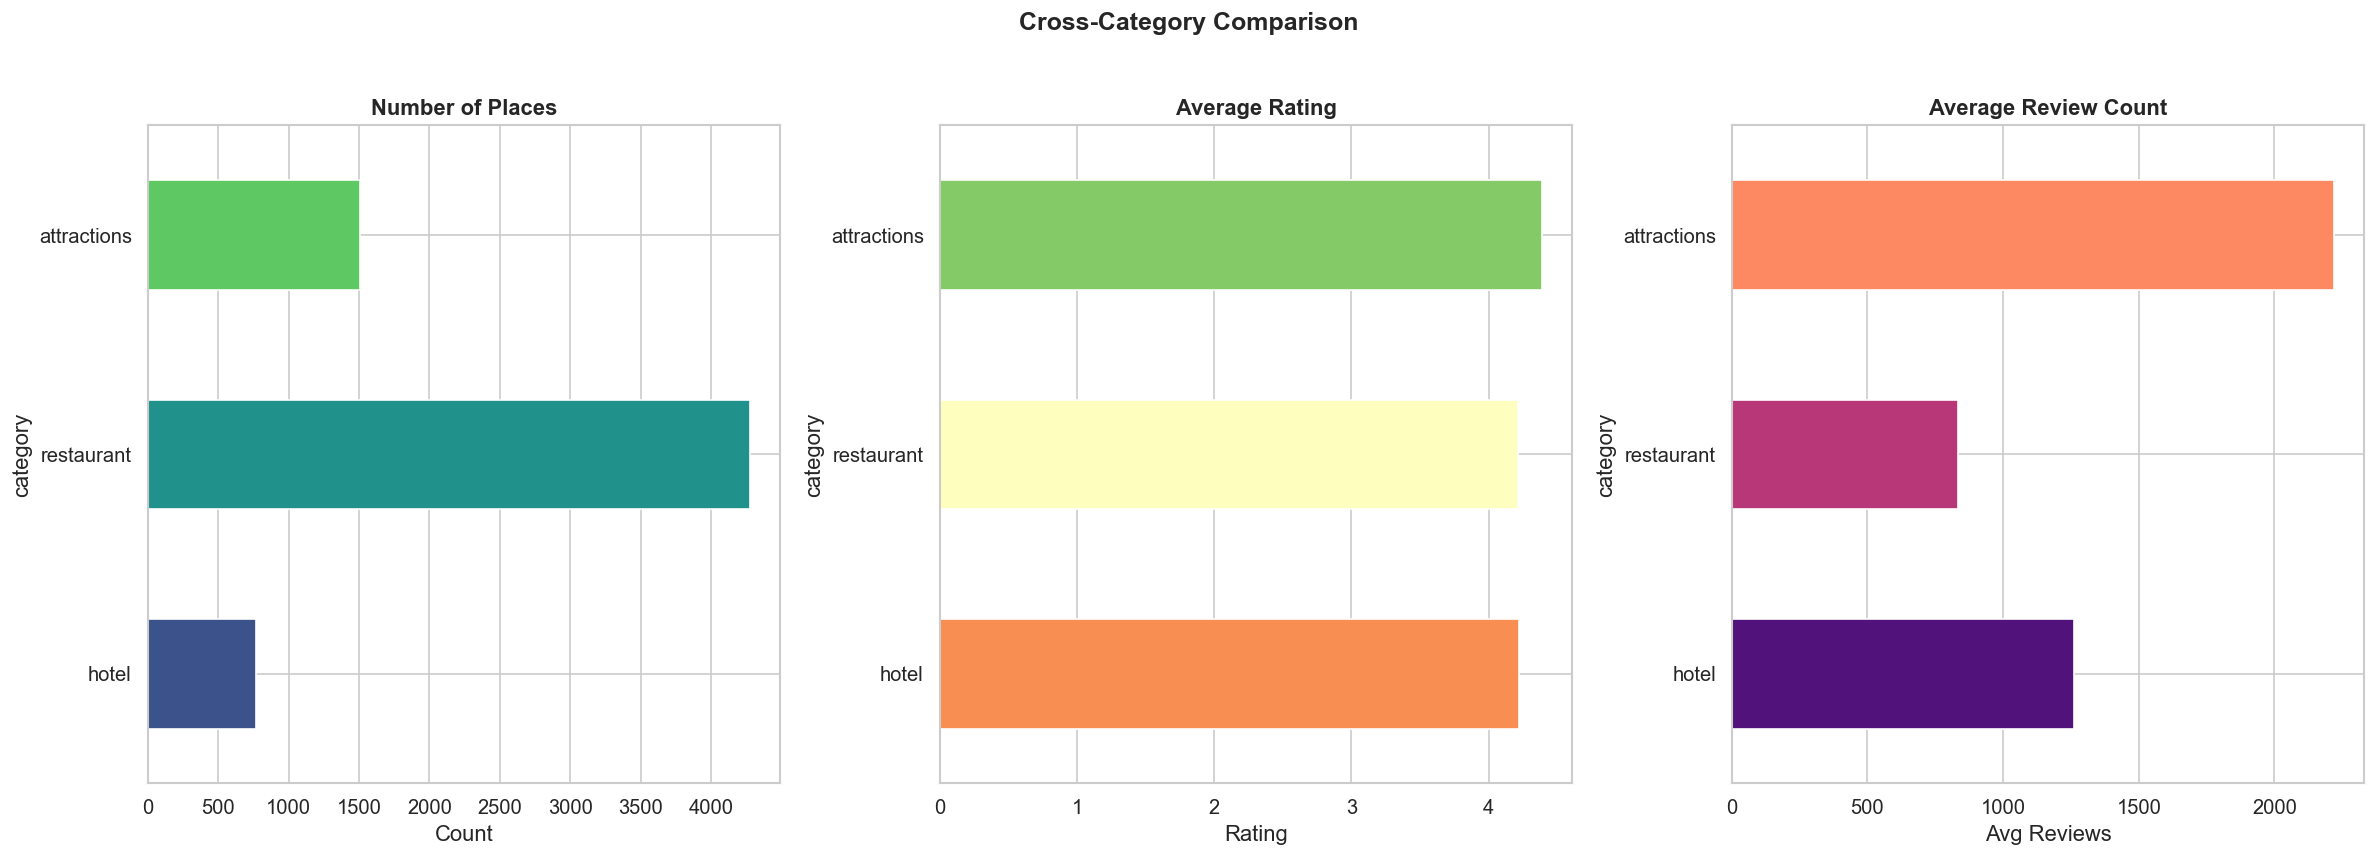

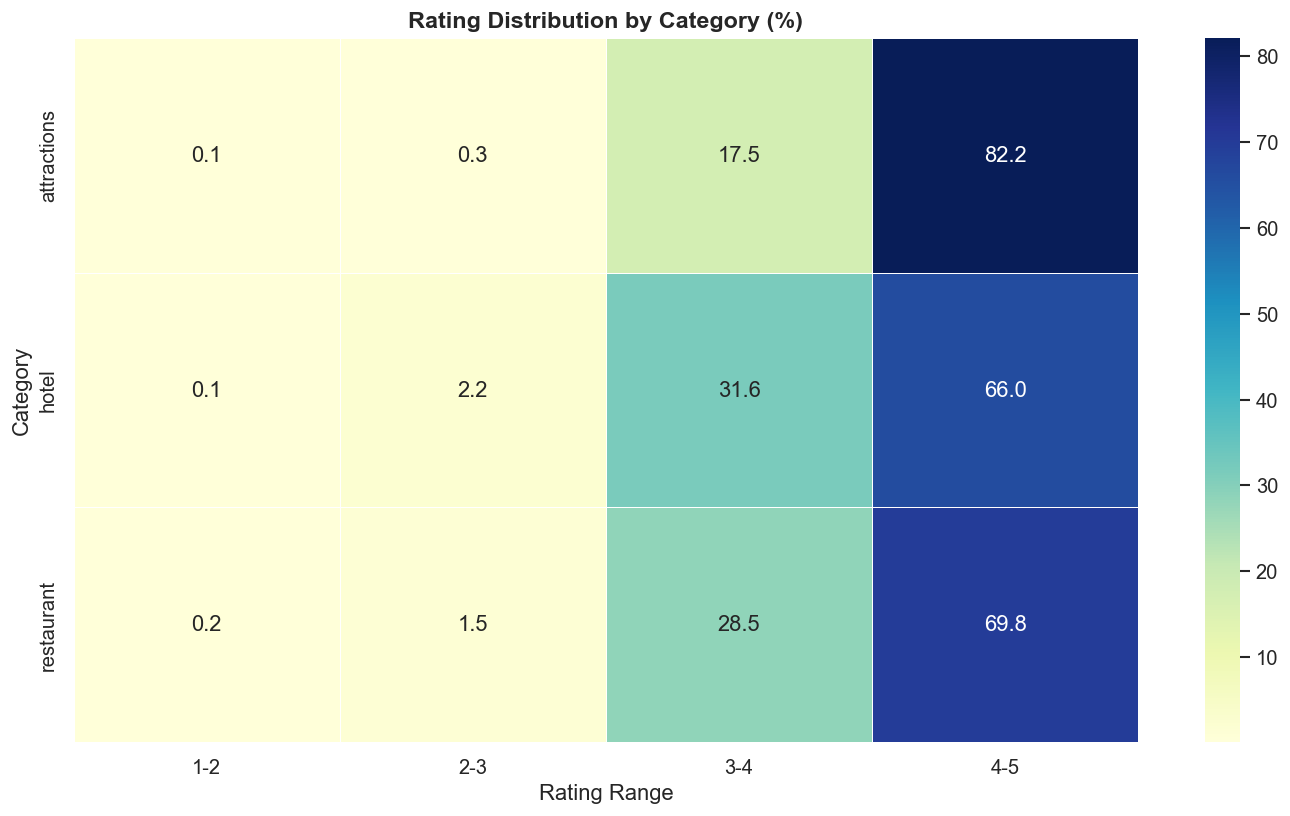

In [26]:
print('\n' + '=' * 70)
print('  CROSS-CATEGORY COMPARISON')
print('=' * 70)

cat_comparison = pd.DataFrame()
for cat_name, cat_df in categories.items():
    row = pd.DataFrame({
        'category': [cat_name],
        'count': [len(cat_df)],
        'avg_rating': [cat_df['rating'].mean()],
        'median_rating': [cat_df['rating'].median()],
        'std_rating': [cat_df['rating'].std()],
        'avg_reviews': [cat_df['review_count'].mean()],
        'total_reviews': [cat_df['review_count'].sum()],
        'unique_districts': [cat_df['district'].nunique()],
    })
    cat_comparison = pd.concat([cat_comparison, row], ignore_index=True)

cat_comparison = cat_comparison.round(2)
print('\nCategory Comparison Summary:')
print(cat_comparison.to_string(index=False))

# Comparison charts
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

cat_comparison.set_index('category')['count'].plot(kind='barh', ax=axes[0], color=sns.color_palette('viridis', len(cat_comparison)))
axes[0].set_title('Number of Places', fontweight='bold')
axes[0].set_xlabel('Count')

cat_comparison.set_index('category')['avg_rating'].plot(kind='barh', ax=axes[1], color=sns.color_palette('RdYlGn', len(cat_comparison)))
axes[1].set_title('Average Rating', fontweight='bold')
axes[1].set_xlabel('Rating')

cat_comparison.set_index('category')['avg_reviews'].plot(kind='barh', ax=axes[2], color=sns.color_palette('magma', len(cat_comparison)))
axes[2].set_title('Average Review Count', fontweight='bold')
axes[2].set_xlabel('Avg Reviews')

plt.suptitle('Cross-Category Comparison', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/cross_category_comparison.png', bbox_inches='tight')
plt.show()

# Category x Rating heatmap (cross-category)
cat_rating_ct = pd.crosstab(
    df['category'],
    pd.cut(df['rating'], bins=[0, 1, 2, 3, 4, 5], labels=['0-1', '1-2', '2-3', '3-4', '4-5'])
)
cat_rating_pct = cat_rating_ct.div(cat_rating_ct.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(cat_rating_pct, annot=True, fmt='.1f', cmap='YlGnBu', ax=ax, linewidths=0.5)
ax.set_title('Rating Distribution by Category (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Rating Range')
ax.set_ylabel('Category')
plt.tight_layout()
plt.savefig('../outputs/figures/category_rating_heatmap.png', bbox_inches='tight')
plt.show()

# ---
# ## 17. Automated Report Generation

In [27]:
report_data = {
    'Total Places': f"{len(df):,}",
    'Hotel Count': f"{len(df_hotel):,}",
    'Restaurant Count': f"{len(df_restaurant):,}",
    'Attractions Count': f"{len(df_attractions):,}",
    'Average Rating': f"{df['rating'].mean():.2f}",
    'Median Review Count': f"{df['review_count'].median():,.0f}",
    'Total Reviews': f"{df['review_count'].sum():,.0f}",
    'Hidden Gems': len(df[(df['rating'] >= 4.5) & (df['review_count'] < df['review_count'].quantile(0.25))]),
}

html_report = f"""
<!DOCTYPE html>
<html>
<head>
    <title>Cairo Places EDA Report - Per Category - TourMate AI</title>
    <style>
        body {{ font-family: 'Segoe UI', Arial, sans-serif; margin: 40px; background: #f8f9fa; color: #333; }}
        .header {{ background: linear-gradient(135deg, #1a237e, #0d47a1); color: white; padding: 40px; border-radius: 12px; margin-bottom: 30px; }}
        .header h1 {{ margin: 0; font-size: 2.2em; }}
        .header p {{ margin: 8px 0 0; opacity: 0.9; font-size: 1.1em; }}
        .section {{ background: white; border-radius: 10px; padding: 25px 30px; margin-bottom: 20px; box-shadow: 0 2px 8px rgba(0,0,0,0.08); }}
        .section h2 {{ color: #1a237e; border-bottom: 2px solid #e8eaf6; padding-bottom: 8px; }}
        .kpi-grid {{ display: grid; grid-template-columns: repeat(auto-fit, minmax(200px, 1fr)); gap: 15px; margin: 20px 0; }}
        .kpi {{ background: #e8eaf6; border-radius: 8px; padding: 20px; text-align: center; }}
        .kpi .value {{ font-size: 2em; font-weight: bold; color: #1a237e; }}
        .kpi .label {{ font-size: 0.9em; color: #555; margin-top: 5px; }}
        .insight {{ background: #e8f5e9; border-left: 4px solid #4caf50; padding: 12px 18px; margin: 10px 0; border-radius: 0 8px 8px 0; }}
        .warning {{ background: #fff3e0; border-left: 4px solid #ff9800; padding: 12px 18px; margin: 10px 0; border-radius: 0 8px 8px 0; }}
        .footer {{ text-align: center; color: #999; padding: 20px; font-size: 0.9em; }}
    </style>
</head>
<body>
    <div class="header">
        <h1>Cairo Places - EDA Report (Per Category)</h1>
        <p>TourMate AI - Data Intelligence - Generated June 2026</p>
    </div>
    <div class="section">
        <h2>Executive Summary</h2>
        <div class="kpi-grid">
            <div class="kpi"><div class="value">{report_data['Total Places']}</div><div class="label">Total Places</div></div>
            <div class="kpi"><div class="value">{report_data['Hotel Count']}</div><div class="label">Hotels</div></div>
            <div class="kpi"><div class="value">{report_data['Restaurant Count']}</div><div class="label">Restaurants</div></div>
            <div class="kpi"><div class="value">{report_data['Attractions Count']}</div><div class="label">Attractions</div></div>
            <div class="kpi"><div class="value">{report_data['Average Rating']}</div><div class="label">Avg Rating</div></div>
            <div class="kpi"><div class="value">{report_data['Total Reviews']}</div><div class="label">Total Reviews</div></div>
            <div class="kpi"><div class="value">{report_data['Hidden Gems']}</div><div class="label">Hidden Gems</div></div>
        </div>
    </div>
    <div class="section">
        <h2>Key Findings</h2>
        <div class="insight"><b>Hotels:</b> {report_data['Hotel Count']} hotel listings analyzed separately with category-specific insights.</div>
        <div class="insight"><b>Restaurants:</b> {report_data['Restaurant Count']} restaurant listings with food-specific analysis.</div>
        <div class="insight"><b>Attractions:</b> {report_data['Attractions Count']} attraction listings with tourism-focused insights.</div>
        <div class="warning"><b>Data Quality:</b> All analyses performed per-category for more accurate and relevant insights.</div>
    </div>
    <div class="section">
        <h2>Recommendations for TourMate AI</h2>
        <ul>
            <li>Use per-category popularity scores for more accurate recommendations.</li>
            <li>Build category-specific user profiles (foodie, hotel-seeker, explorer).</li>
            <li>Prioritize hidden gems within each category for personalized discovery.</li>
            <li>Leverage district-level insights for location-based recommendations.</li>
        </ul>
    </div>
    <div class="footer">
        <p>Generated by TourMate AI Data Science Team - June 2026</p>
    </div>
</body>
</html>
"""

with open('../outputs/reports/cairo_places_eda_report.html', 'w', encoding='utf-8') as f:
    f.write(html_report)

print('HTML report saved to outputs/reports/cairo_places_eda_report.html')

# ---
# ## 18. Notebook Summary

HTML report saved to outputs/reports/cairo_places_eda_report.html


In [28]:
print('=' * 70)
print('CAIRO PLACES EDA - PER CATEGORY - COMPLETED SUCCESSFULLY')
print('=' * 70)
print(f'\nTotal Dataset: {len(df):,} places across {df["category"].nunique()} categories')
print(f'\nPer-Category Breakdown:')
for cat_name, cat_df in categories.items():
    print(f'  {cat_name:15s}: {len(cat_df):>5,} places | avg rating: {cat_df["rating"].mean():.2f} | avg reviews: {cat_df["review_count"].mean():.0f}')
print(f'\nOutput Files:')
print(f'  outputs/figures/ - per-category visualizations saved')
print(f'  outputs/reports/ - HTML report')
print('\nAll analyses complete. Notebook ready for review.')

# ---
# *This notebook was generated by TourMate AI Data Science Team - June 2026*
# *Per-category EDA for Hotels, Restaurants, and Attractions*

CAIRO PLACES EDA - PER CATEGORY - COMPLETED SUCCESSFULLY

Total Dataset: 6,556 places across 3 categories

Per-Category Breakdown:
  hotel          :   771 places | avg rating: 4.22 | avg reviews: 1263
  restaurant     : 4,276 places | avg rating: 4.21 | avg reviews: 834
  attractions    : 1,509 places | avg rating: 4.39 | avg reviews: 2221

Output Files:
  outputs/figures/ - per-category visualizations saved
  outputs/reports/ - HTML report

All analyses complete. Notebook ready for review.
